In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')
import numpy as np

import math
import cmath
np.set_printoptions(precision = 5)

In [2]:
import matplotlib
import dizx
from dizx import Edge
from dizx import clifford_simplifier as simp
Phase = dizx.CliffordPhase
# d = 3
Z = dizx.VertexType.Z
X = dizx.VertexType.X

In [3]:
from sympy import symbols, Symbol, Add, Mul, sympify

def symbolic_inverse(x):
    x = sympify(x)

    # 0 has no inverse
    if x == 0:
        raise ValueError("0 has no multiplicative inverse.")

    # symbol → symbolinv
    if isinstance(x, Symbol):
        return symbols(f"{x.name}inv")

    # plain integer
    if x.is_Integer:
        if x == 1:
            return 1
        if x == -1:
            return -1
        return symbols(f"{x}inv")   # 3 → 3inv

    # product: coeff * symbol
    coeff, base = x.as_coeff_Mul()
    if isinstance(base, Symbol):
        inv_coeff = symbolic_inverse(coeff)
        inv_base  = symbols(f"{base.name}inv")
        return Mul(inv_coeff, inv_base, evaluate=True)  # <-- prevents concatenation

    # additive expression: invert whole block
    if isinstance(x, Add):
        return x**(-1)

    return x**(-1)


In [4]:
import sympy as sp

t, b = sp.symbols("t b")

expr = -t * (1/b - 1/t)
simplified = sp.simplify(expr)
print(simplified)

(b - t)/b


In [5]:
"""Modules with tools for representing qudit Clifford matrices as symplectic matrices.
We are ignoring phases everywhere, and so everything is 'up to Paulis'.
The symplectic matrices are constructed according to the order (x1,z1,x2,z2,...) and hence not in terms of Z and X blocks.
"""
import os.path
# from sympy import symbols
from sympy import symbols, groebner, Matrix, eye, Symbol, mod_inverse, simplify, expand
from sympy import Matrix, groebner, Symbol
from typing import List, Tuple, Iterable, Optional

Hmat = Matrix([[0,-1],[1,0]])
H2mat = Matrix([[-1,0],[0,-1]])
Hinvmat = Matrix([[0,1],[-1,0]])
idmat = Matrix([[1,0],[0,1]])
SWAPmat = Matrix([
                [0,0,1,0],
                [0,0,0,1],
                [1,0,0,0],
                [0,1,0,0]])

def Smat(rep):
    """Create a matrix representing `rep` repetitions of the S gate."""
    return Matrix([[1  ,0],
                   [rep,1]])

def MULmat(mul, dim):
    return Matrix([[mul,0],
                   [0,mod_inverse(mul,dim)]])

def CXmat(rep):
    return Matrix([
                [1  ,0,0,0],
                [0  ,1,0,-rep],
                [rep,0,1,0],
                [0  ,0,0,1]])

def CZmat(rep):
    return Matrix([
                [1  ,0,0  ,0],
                [0  ,1,rep,0],
                [0  ,0,1  ,0],
                [rep,0,0  ,1]])

def embed_block(block, n, mapping):
    """
    Embed a 2k x 2k symplectic 'block' into a 2n x 2n matrix.
    
    Parameters
    ----------
    block   : sympy.Matrix (2k x 2k)
              Symplectic block defined on local qudits [0..k-1],
              ordered [x0, z0, x1, z1, ...].
    n       : int
              Total number of qudits in the global system.
    mapping : list[int]
              Mapping of local qudits to global qudits.
              E.g. [2,4] means local 0 → global 2, local 1 → global 4.
    """
    k = len(mapping)
    assert block.shape == (2*k, 2*k)

    M = eye(2*n)

    # Local-to-global index map
    idx = []
    for q in mapping:
        idx.extend([2*q, 2*q+1])  # (x_q, z_q) in global basis order

    # Place the block into M
    for r in range(2*k):
        for c in range(2*k):
            M[idx[r], idx[c]] = block[r, c]

    return M

def ID(num_qudits):
    return eye(2*num_qudits)

def H(target, num_qudits, reps=1):
    if reps % 4 == 1: mat = Hmat
    elif reps % 4 == 2: mat = H2mat
    elif reps % 4 == 3: mat = Hinvmat
    else: mat = idmat
    return embed_block(mat, num_qudits, [target])

def MUL(target, num_qudits, mul, dim):
    mat = MULmat(mul, dim)
    return embed_block(mat, num_qudits, [target])

def S(target, num_qudits, reps=1):
    mat = Smat(reps)
    return embed_block(mat, num_qudits, [target])


def CX(control, target, num_qudits, reps=1):
    mat = CXmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def CZ(control, target, num_qudits, reps=1):
    mat = CZmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def SWAP(control, target, num_qudits):
    return embed_block(SWAPmat, num_qudits, [control,target])

def modulo_matrix(M, p):
    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = entry % p 
            newrow.append(entry)
        reduced_entries.append(newrow)
    # Test
    # print(p)
    return Matrix(reduced_entries)

# Attempt 1
# def reduce_matrix(M, params: list[tuple[Symbol,Symbol]]):
#     """Given a matrix containing parameters, reduces it by applying simple identities.
#     params should be a list of tuples (param, invparam) where we interpret invparam = param^{-1}"""
    
#     flattened = [a for (a,ainv) in params] + [ainv for (a,ainv) in params]
#     G = groebner([a*ainv - 1 for (a,ainv) in params], *flattened)

#     reduced_entries = []
#     for i in range(M.rows):
#         row = M.row(i)
#         newrow = []
#         for entry in row:
#             entry = G.reduce(entry)[1]
#             # simplified = simplify(entry)  
#             # Make algebraic simplifications (optional but essential)
#             # Prevents expressions like  -t*(binv - tinv) from staying unevaluated
#             # reduced = expand(reduced)
#             # reduced = simplify(reduced)
#             newrow.append(entry)
#         reduced_entries.append(newrow)
#     return Matrix(reduced_entries)

# Attempt 2

def reduce_matrix(
    M: Matrix,
    params: List[Tuple[Symbol, Symbol]],
    extra_relations: Optional[Iterable] = None,
    extra_gens: Optional[Iterable[Symbol]] = None,
):
    """
    Given a matrix containing parameters, reduces it by applying simple identities.
    `params` should be a list of tuples (param, invparam) where we interpret invparam = param^{-1}.
    
    extra_relations: additional polynomial equations (each == 0), e.g. [dminusa - (d - a)]
    extra_gens: extra generators to include in the Groebner basis, e.g. [dminusa]
    """

    # Base generators: parameters and their inverses
    flattened = [a for (a, ainv) in params] + [ainv for (a, ainv) in params]

    # Add any extra generators (like dminusa)

    if extra_gens is not None:
        flattened += list(extra_gens)

    # --- Remove duplicate generators ---
    seen = set()
    flattened = [g for g in flattened if not (g in seen or seen.add(g))]


    # Base relations: a*ainv - 1 = 0
    relations = [a*ainv - 1 for (a, ainv) in params]

    # Add extra relations (like dminusa - (d - a) = 0)
    if extra_relations is not None:
        relations = relations + list(extra_relations)

    # Build Groebner basis
    G = groebner(relations, *flattened)

    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry_red = G.reduce(entry)[1]
            newrow.append(entry_red)
        reduced_entries.append(newrow)

    return Matrix(reduced_entries)


def compare_matrices(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        m1 = modulo_matrix(m1,modulus)
        m2 = modulo_matrix(m2,modulus)
    return m1 == m2

def compare_matrices2(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        a = symbols("a")
        ainv = symbols("ainv")
        b = symbols("b")
        binv = symbols("binv")
        m1_reduce = dizx.symplectic.reduce_matrix(m1,[(a,ainv),(b,binv)])
        m2_reduce = dizx.symplectic.reduce_matrix(m2,[(a,ainv),(b,binv)])
        m1_reduce = modulo_matrix(m1_reduce,modulus)
        m2_reduce = modulo_matrix(m2_reduce,modulus)
    return m1_reduce == m2_reduce

# Attempt 1
# def compare_matrices3(m1: Matrix, m2: Matrix, params=None, modulus: int = 0):
#     """
#     Compare two symplectic matrices after symbolic reductions and optional
#     modulo arithmetic.

#     Parameters
#     ----------
#     m1, m2 : sympy.Matrix
#         Symplectic matrices to compare.

#     params : list of (Symbol or Expr, Symbol or Expr)
#         A list of substitution relations of the form (x, xinv),
#         where xinv represents the multiplicative inverse of x.
#         If None, no symbolic reduction is applied.

#     modulus : int
#         If nonzero, reduce all matrix entries modulo this integer.

#     Returns
#     -------
#     bool
#         True if the reduced matrices are equal, else False.
#     """

#     # --- Apply symbolic reduction (Groebner-based) ---
#     if params is not None:
#         m1 = dizx.symplectic.reduce_matrix(m1, params)
#         m2 = dizx.symplectic.reduce_matrix(m2, params)

#     # --- Optional: reduce entries modulo p ---
#     if modulus != 0:
#         m1 = modulo_matrix(m1, modulus)
#         m2 = modulo_matrix(m2, modulus)

#     # --- Compare structurally ---
#     return m1.equals(m2)

# Attempt 2
def compare_matrices3(
    m1: Matrix,
    m2: Matrix,
    params=None,
    modulus: int = 0,
    extra_relations=None,
    extra_gens=None
):
    """
    Compare two symplectic matrices after symbolic reductions and optional
    modulo arithmetic.

    Parameters
    ----------
    m1, m2 : sympy.Matrix
        Symplectic matrices to compare.

    params : list of (Symbol, Symbol)
        A list of parameter-inverse pairs (x, xinv), where xinv is interpreted
        as the formal multiplicative inverse of x.
        If None, no inverse reductions are applied.

    extra_relations : list of sympy expressions
        Additional algebraic constraints of the form expr == 0,
        e.g. [dminusa - (d - a), cminusb - (c - b)].
        These are added to the Groebner system.

    extra_gens : list of Symbols
        Additional generators to include in the Groebner basis.
        Required for composite parameters such as dminusa, cminusb.

    modulus : int
        If nonzero, reduce matrix entries modulo this integer.

    Returns
    -------
    bool
        True if the reduced matrices are equal, else False.
    """

    # --- Apply symbolic reduction (Groebner-based) ---
    if params is not None:
        m1 = reduce_matrix(
            m1,
            params=params,
            extra_relations=extra_relations,
            extra_gens=extra_gens,
        )
        m2 = reduce_matrix(
            m2,
            params=params,
            extra_relations=extra_relations,
            extra_gens=extra_gens,
        )

    # --- Optional modulus reduction ---
    if modulus != 0:
        m1 = modulo_matrix(m1, modulus)
        m2 = modulo_matrix(m2, modulus)

    # --- Compare matrices structurally ---
    return m1.equals(m2)


## Check the symplectic soundness of box relations
Print LHS and RHS to respective QASM files.

In [6]:
import os

def run_all_BR_relations(
    primes,
    save_to_path,
    params,
    relation_generator,
    extra_relations=None,
    extra_gens=None,
):
    """
    For each prime p:
        1. Generate BR relations via relation_generator(p)
        2. Compare LHS/RHS using compare_matrices3
        3. Save QASM outputs once after processing all primes

    Parameters
    ----------
    primes : iterable of ints
        Dimensions p of qudit Clifford theory to test.

    save_to_path : str
        Directory where QASM files will be written.

    params : list of (Symbol, Symbol)
        Formal inverse pairs, e.g. [(a, ainv), (b, binv), ...].

    relation_generator : callable
        Function taking p and returning (lhs_list, rhs_list, relation_names).

    extra_relations : list of SymPy expressions
        Additional symbolic constraints, e.g. [dminusa - (d - a)].

    extra_gens : list of Symbols
        Composite symbols appearing in extra_relations, e.g. [dminusa, cminusb].
    """

    # Ensure directory exists
    if not os.path.isdir(save_to_path):
        os.makedirs(save_to_path)

    # Will hold the final circuits for QASM output
    final_lhs_list = None
    final_rhs_list = None
    final_relation_names = None

    for p in primes:
        print(f"\n=== Checking BR relations for p = {p} ===")

        lhs_list, rhs_list, relation_names = relation_generator(p)

        # Store these so QASM export happens only once
        final_lhs_list = lhs_list
        final_rhs_list = rhs_list
        final_relation_names = relation_names

        for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

            lhs_mat = lhs.to_symplectic_matrix()
            rhs_mat = rhs.to_symplectic_matrix()

            ok = compare_matrices3(
                lhs_mat,
                rhs_mat,
                params=params,
                modulus=p,
                extra_relations=extra_relations,
                extra_gens=extra_gens,
            )

            if ok:
                print(f"✔ {name} holds for p = {p}")
            else:
                print(f"❌ {name} fails for p = {p}")

    print("\n=== All primes processed ===")

    # Save QASM files ONCE (for the final prime)
    print(f"\nSaving QASM files to: {save_to_path}")

    for name, lhs, rhs in zip(final_relation_names, final_lhs_list, final_rhs_list):

        lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
        rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

        with open(lhs_filename, "w+") as f:
            f.write(lhs.to_qasm())

        with open(rhs_filename, "w+") as f:
            f.write(rhs.to_qasm())

    print("QASM files generated.")


In [ ]:
# import os

# def run_all_BR_relations(primes, save_to_path, params, relation_generator):
#     """
#     For each prime p:
#         1. Generate BR63–BR66 relations
#         2. Compare LHS/RHS using compare_matrices3
#         3. Save QASM outputs for each relation

#     Requirements:
#         - generate_D_box_relations(p)
#         - compare_matrices3(lhs_mat, rhs_mat, modulus=p)
#         - directory save_to_path must exist
#     """

#     # Ensure output directory exists
#     if not os.path.isdir(save_to_path):
#         os.makedirs(save_to_path)

#     for p in primes:
#         print(f"\n=== Checking BR relations for p = {p} ===")

#         # Generate the relations for this p
#         lhs_list, rhs_list, relation_names = relation_generator(p)

#         for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

#             # Compute symplectic matrices
#             lhs_mat = lhs.to_symplectic_matrix()
#             rhs_mat = rhs.to_symplectic_matrix()
            
#             # Compare using your function
#             ok = compare_matrices3(lhs_mat, rhs_mat, params, modulus=p)

#             # Print failures
#             if not ok:
#                 print(f"❌ {name} fails for p = {p}")
#             else:
#                 print(f"✔ {name} holds for p = {p}")
#     print("\n=== All primes processed ===")

#      # --- Save QASM files ONCE (from final p) ---
#     print(f"\nSaving QASM files to: {save_to_path}")

#     for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

#         lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
#         rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

#         with open(lhs_filename, "w+") as f:
#             f.write(lhs.to_qasm())

#         with open(rhs_filename, "w+") as f:
#             f.write(rhs.to_qasm())

#     print("QASM files generated.")

## Generate all A boxes
- $A_{0b}$, $b \in \mathbb{Z}_p^*$
- $A_{ab}$, $a \in \mathbb{Z}_p^*$, $b \in \mathbb{Z}_p$

In [7]:
from dizx.circuit.gates import SWAP, CZ, CX, HAD, S

def instantiate_A_box(a, b, j, n, p):
    """
    Returns the A(a,b) box acting on qudit j inside an n-qudit circuit. Indexing starts from 0.
    """

    # ---- Index validation ----
    if not isinstance(j, int):
        raise TypeError(f"Target index j must be an integer, not {type(j)}.")

    if j < 0 or j >= n:
        raise ValueError(
            f"Target qudit index j={j} is out of range for n={n}. "
            f"Valid indices are 0 to {n-1}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ---- Case A(0,b) ----
    if a == 0:
        circ += (
            HAD(j)**-1 +
            S(j)**symbolic_inverse(b) +
            HAD(j)**-1 +
            S(j)**b +
            HAD(j)
        )
        return circ

    # ---- Case A(a,b), a != 0 ----
    circ += (
        HAD(j)**-1 +
        S(j)**(-a) +
        HAD(j)**-1 +
        S(j)**(-symbolic_inverse(a)) +
        HAD(j)**-1 +
        S(j)**(-a * (b + 1)) +
        HAD(j)
    )
    return circ


# Generate all E boxes
- $E_{b}$, $b \in \mathbb{Z}_p$

In [8]:
def instantiate_E_box(b, j, n, p):
    """
    Returns the E(b) box acting on qudit j inside an n-qudit circuit. Indexing starts from 0.
    """

    # ---- Index validation ----
    if not isinstance(j, int):
        raise TypeError(f"Target index j must be an integer, not {type(j)}.")

    if j < 0 or j >= n:
        raise ValueError(
            f"Target qudit index j={j} is out of range for n={n}. "
            f"Valid indices are 0 to {n-1}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)
    circ += S(j)**(-b)
    return circ


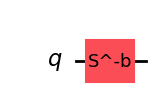

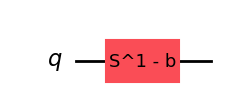

In [9]:
a, b = symbols("a b")

Eb = instantiate_E_box(b, 0, 1, 23)
display(Eb.draw())

Ebminusone = instantiate_E_box(b-1, 0, 1, 23)
display(Ebminusone.draw())

## Verify: Single-qupit box relations
Pushing H/S through an A box
- $BR1 \sim BR3$: $H. A_{ab}$, $a,b\in \mathbb{Z}_p \times \mathbb{Z}_p \setminus \{(0,0)\}$
- $BR4 \sim BR5$: $S. A_{ab}$, $a,b\in \mathbb{Z}_p \times \mathbb{Z}_p \setminus \{(0,0)\}$


Pushing S through an E box
- $BR6$: $S. E_{b}$, $b\in \mathbb{Z}_p$.

In [10]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

# --- Define symbolic parameters ---
a, b = symbols("a b")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b))
]

def generate_1q_HS_AE_box_relations(p):
    """
    Generate all A- and E-boxes, as well as BR1–BR6 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR1", "BR2", ...]
    """

    # --- Precompute A- and E-boxes used in the BR relations ---
    A0b = instantiate_A_box(0, b, 0, 1, p)
    Ab0 = instantiate_A_box(b, 0, 0, 1, p)
    Aa0 = instantiate_A_box(a, 0, 0, 1, p)
    A0_neg_a = instantiate_A_box(0, -a, 0, 1, p)
    Aab = instantiate_A_box(a, b, 0, 1, p)
    Ab_neg_a = instantiate_A_box(b, -a, 0, 1, p)
    Aa_bminusa = instantiate_A_box(a, b-a, 0, 1, p)

    Eb = instantiate_E_box(b, 0, 1, p)
    Ebminusone = instantiate_E_box(b-1, 0, 1, p)

    # --- Build BR relations ---

    # BR1
    BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR1lhs += HAD(0) + A0b
    BR1rhs += Ab0 + S(0) ** (symbolic_inverse(-b))

    # BR2
    BR2lhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR2rhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR2lhs += HAD(0) + Aa0
    BR2rhs += A0_neg_a + S(0) ** (symbolic_inverse(-a))
    # display(BR1lhs.draw())
    # display(BR1rhs.draw())

    # BR3
    BR3lhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR3rhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR3lhs += HAD(0) + Aab
    BR3rhs += Ab_neg_a + S(0) ** ((symbolic_inverse(a) * symbolic_inverse(b)))

    # BR4
    BR4lhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR4rhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR4lhs += S(0) + A0b
    BR4rhs += A0b + S(0) ** ((symbolic_inverse(b) * symbolic_inverse(b)))

    # BR5
    BR5lhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR5rhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR5lhs += S(0) + Aab
    BR5rhs += Aa_bminusa
    
    # BR6
    BR6lhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR6rhs = dizx.Circuit(qudit_amount=1, dim=p)
    BR6lhs += S(0) + Eb
    BR6rhs += Ebminusone

    # Put all circuits in order
    lhs_list = [BR1lhs, BR2lhs, BR3lhs, BR4lhs, BR5lhs, BR6lhs]
    rhs_list = [BR1rhs, BR2rhs, BR3rhs, BR4rhs, BR5rhs, BR6rhs]

    relation_names = ["BR1", "BR2", "BR3", "BR4", "BR5", "BR6"]

    return lhs_list, rhs_list, relation_names


In [11]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)


=== Checking BR relations for p = 3 ===
✔ BR1 holds for p = 3
✔ BR2 holds for p = 3
✔ BR3 holds for p = 3
✔ BR4 holds for p = 3
✔ BR5 holds for p = 3
✔ BR6 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR1 holds for p = 5
✔ BR2 holds for p = 5
✔ BR3 holds for p = 5
✔ BR4 holds for p = 5
✔ BR5 holds for p = 5
✔ BR6 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR1 holds for p = 7
✔ BR2 holds for p = 7
✔ BR3 holds for p = 7
✔ BR4 holds for p = 7
✔ BR5 holds for p = 7
✔ BR6 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR1 holds for p = 11
✔ BR2 holds for p = 11
✔ BR3 holds for p = 11
✔ BR4 holds for p = 11
✔ BR5 holds for p = 11
✔ BR6 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR1 holds for p = 13
✔ BR2 holds for p = 13
✔ BR3 holds for p = 13
✔ BR4 holds for p = 13
✔ BR5 holds for p = 13
✔ BR6 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR1 holds for p = 19
✔ BR2 holds for p = 19
✔ BR3 holds for p = 19
✔ BR4 hold

## Generate all B boxes
- $B_{00}$,
- $B_{01}$,
- $B_{ab}$, $(a,b) \in \mathbb{Z}_p \times \mathbb{Z}_p \setminus\{(0,0),(0,1)\}$

In [12]:
from dizx.circuit.gates import SWAP, CZ, HAD, S, CX
import dizx

def instantiate_B_box(a, b, j, k, n, p):
    """
    Instantiate a B(a,b) box acting on qudits j and k inside an n-qudit circuit.

    Updated specification:
        B00 = SWAP(j,k)
        B01 = SWAP(j,k) + CZ(k,j)
        Bab = Aab(on qudit j) + B01(j,k), valid only for (a,b) != (0,0) and (a,b) != (0,1)
    """

    # ---- Index validation ----
    for idx, name in [(j, "j"), (k, "k")]:
        if not isinstance(idx, int):
            raise TypeError(f"Target index {name} must be an integer, not {type(idx)}.")

        if idx < 0 or idx >= n:
            raise ValueError(
                f"Target qudit index {name}={idx} is out of range for n={n}. "
                f"Valid indices are 0 to {n-1}."
            )

    # ---- Create empty circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)
    
    # ----------------------------------------------------------------------
    # Case 1: B00 = SWAP
    # ----------------------------------------------------------------------
    if a == 0 and b == 0:
        circ += SWAP(j, k)
        return circ

    # ----------------------------------------------------------------------
    # Case 2: B01 = SWAP + XC
    # ----------------------------------------------------------------------
    if a == 0 and b == 1:
        circ += SWAP(j, k)
        circ += CX(k,j)
        return circ

    # ----------------------------------------------------------------------
    # Case 3: General Bab = Aab(on first qudit) + B01
    # Allowed *only when (a,b) != (0,0) and (a,b) != (0,1)
    # ----------------------------------------------------------------------

    # Instantiate Aab on the FIRST qudit j
    Aab_j = instantiate_A_box(a, b, j, n, p)
    circ += Aab_j

    # Add B01
    circ += SWAP(j, k)
    circ += CX(k,j)

    return circ


# Generate all D boxes
- $D_{00}$,
- $D_{0b}$,
- $D_{ab}$.

In [13]:
from dizx.circuit.gates import SWAP, CZ, HAD, S
import dizx

def instantiate_D_box(a, b, j, k, n, p):
    """
    Instantiate a D(a,b) box acting on qudits j and k inside an n-qudit circuit.

    Updated specification:
        D0b = SWAP(j,k) + CZ(j,k)**(-b)
        Dab = Aab(on qudit k) + D01(j,k), valid only for a != 0
    """

    # ---- Index validation ----
    for idx, name in [(j, "j"), (k, "k")]:
        if not isinstance(idx, int):
            raise TypeError(f"Target index {name} must be an integer, not {type(idx)}.")

        if idx < 0 or idx >= n:
            raise ValueError(
                f"Target qudit index {name}={idx} is out of range for n={n}. "
                f"Valid indices are 0 to {n-1}."
            )

    # ---- Create empty circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ----------------------------------------------------------------------
    # Case 1: D0b = SWAP + CZ**(-b)  (for ANY b)
    # ----------------------------------------------------------------------
    if a == 0:
        circ += SWAP(j, k)
        circ += CZ(j, k)**(-b)
        return circ

    # ----------------------------------------------------------------------
    # Case 2: General Dab = Aab(on second qudit) + D01
    # Allowed *only when a != 0*
    # ----------------------------------------------------------------------

    # Instantiate Aab on the SECOND qudit k
    Aab_k = instantiate_A_box(a, b, k, n, p)
    circ += Aab_k

    # Add D01
    circ += SWAP(j, k)
    circ += CZ(j, k)**(-1)   # this is b = 1 in D01

    return circ


D00


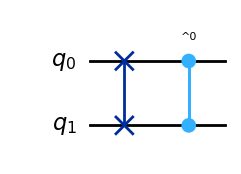

D01


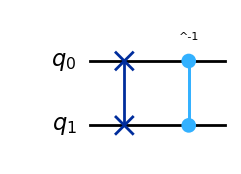

D0b


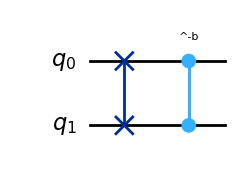

Dab


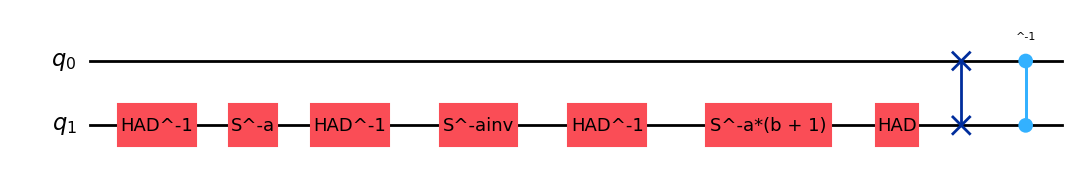

D0bminusc_01


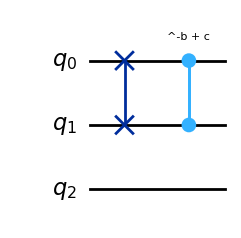

Matrix([
[     0, 0,      1, 0, 0, 0],
[-b + c, 0,      0, 1, 0, 0],
[     1, 0,      0, 0, 0, 0],
[     0, 1, -b + c, 0, 0, 0],
[     0, 0,      0, 0, 1, 0],
[     0, 0,      0, 0, 0, 1]])

In [14]:
# --- Define symbolic parameters ---
a, b, c, d= symbols("a b c d")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d))
]

D00 = instantiate_D_box(0, 0, 0, 1, 2, 23)
print("D00")
display(D00.draw())
D00_m = D00.to_symplectic_matrix()
D00_m


D01 = instantiate_D_box(0, 1, 0, 1, 2, 23)
print("D01")
display(D01.draw())
D01_m = D01.to_symplectic_matrix()
D01_m


D0b = instantiate_D_box(0, b, 0, 1, 2, 23)
print("D0b")
display(D0b.draw())
D0b_m = D0b.to_symplectic_matrix()
D0b_m

Dab = instantiate_D_box(a, b, 0, 1, 2, 23)
print("Dab")
display(Dab.draw())
Dab_m = Dab.to_symplectic_matrix()
Dab_m_reduce = reduce_matrix(Dab_m,[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Dab_m_reduce

D0bminusc_01 = instantiate_D_box(0, b-c, j=0, k=1, n=3, p=23)
print("D0bminusc_01")
display(D0bminusc_01.draw())
D0bminusc_01_m = D0bminusc_01.to_symplectic_matrix()
D0bminusc_01_m


## Verify: Pushing CZ through an A box
$BR7 \sim BR8: CZ. A_{ab}$, $a,b\in \mathbb{Z}_p \times \mathbb{Z}_p \setminus \{(0,0)\}$

In [50]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b = symbols("a b")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b))
]

def generate_2q_CZ_A_box_relations(p):
    """
    Generate all A-boxes, as well as BR7–BR8 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR7", "BR8"]
    """

    # --- Precompute A- and B-boxes used in the BR relations ---
    A0b_0 = instantiate_A_box(0, b, 0, 2, p)
    Aab_0 = instantiate_A_box(a, b, 0, 2, p)
    A0_neg_a_1 = instantiate_A_box(0, -a, 1, 2, p)
    Bab_01 = instantiate_B_box(a, b, 0, 1, 2, p)

   
    # --- Build BR relations ---

    # BR7
    BR7lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR7rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR7lhs += CZ(0,1) + A0b_0
    BR7rhs += A0b_0 + CZ(0,1) ** (symbolic_inverse(b))

    # BR8
    BR8lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR8rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR8lhs += CZ(0,1) + Aab_0
    BR8rhs += A0_neg_a_1 + Bab_01 + (
        HAD(1) + S(1) ** a + HAD(1) ** 2 + CZ(0,1)
        + HAD(1) + S(1) ** (symbolic_inverse(a)) + HAD(1) ** 3
    )

   
    # Put all circuits in order
    lhs_list = [BR7lhs, BR8lhs]
    rhs_list = [BR7rhs, BR8rhs]

    relation_names = ["BR7", "BR8"]

    return lhs_list, rhs_list, relation_names


In [51]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)



=== Checking BR relations for p = 3 ===
✔ BR7 holds for p = 3
✔ BR8 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR7 holds for p = 5
✔ BR8 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR7 holds for p = 7
✔ BR8 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR7 holds for p = 11
✔ BR8 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR7 holds for p = 13
✔ BR8 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR7 holds for p = 19
✔ BR8 holds for p = 19

=== Checking BR relations for p = 23 ===
✔ BR7 holds for p = 23
✔ BR8 holds for p = 23

=== All primes processed ===

Saving QASM files to: ./circuits
QASM files generated.


## Verify: Pushing CZ through A.B boxes
$BR9 \sim BR12: CZ.A_{0b}.B_{cd}$, $b\in \mathbb{Z}_p^*$, $c, d\in \mathbb{Z}_p$.

In [21]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b, c, d, bminusc = symbols("a b c d bminusc")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (bminusc, symbolic_inverse(bminusc))
]

extra_relations = [bminusc - (b - c)]
extra_gens = [bminusc]

def generate_2q_CZ_A0b_B_box_relations(p):
    """
    Generate all B-boxes, as well as BR9–BR12 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR9", "BR10", ...]
    """

    # --- Precompute A- and B-boxes used in the BR relations ---
    A0b = instantiate_A_box(0, b, 1, 2, p)
    A0_bminusc = instantiate_A_box(0, bminusc, 1, 2, p)
    Abd = instantiate_A_box(b, d, 0, 2, p)
    B00 = instantiate_B_box(0, 0, 0, 1, 2, p)
    B01 = instantiate_B_box(0, 1, 0, 1, 2, p)
    B0d = instantiate_B_box(0, d, 0, 1, 2, p)
    Bbd = instantiate_B_box(b, d, 0, 1, 2, p)
    Bcd = instantiate_B_box(c, d, 0, 1, 2, p)


    # --- Build BR relations ---

    # BR9
    BR9lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR9rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR9lhs += CZ(0,1) + A0b + B00
    BR9rhs += A0b + B00 + CZ(0,1) ** symbolic_inverse(b)

    # BR10
    BR10lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR10rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR10lhs += CZ(0,1) + A0b + B0d
    BR10rhs += A0b + B0d + (
        CZ(0,1) ** (symbolic_inverse(b) * symbolic_inverse(d)) 
        + S(1) ** (symbolic_inverse(b) * symbolic_inverse(d) * (-2)))
    
    # BR10-2
    BR10_2lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR10_2rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR10_2lhs += CZ(0,1) + A0b + B01
    BR10_2rhs += A0b + B01 + (
        CZ(0,1) ** symbolic_inverse(b) 
        + S(1) ** (symbolic_inverse(b) * (-2)))

   
   # BR11
    BR11lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR11rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR11lhs += CZ(0,1) + A0b + Bbd
    BR11rhs += Abd + (HAD(1) + S(1) ** symbolic_inverse(b) + HAD(1)
        + CZ(0,1) + HAD(1) ** 2 + S(1) ** b + HAD(1))
    
    # BR12
    BR12lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR12rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR12lhs += CZ(0,1) + A0b + Bcd
    BR12rhs += A0_bminusc + Bcd + (S(0) ** (symbolic_inverse(b) - symbolic_inverse(bminusc))
        + HAD(1) + S(1) ** (-bminusc) + HAD(1)
        + CZ(0,1) ** (symbolic_inverse(b) - symbolic_inverse(bminusc))
        + S(1) ** (symbolic_inverse(b) - symbolic_inverse(bminusc)) 
        + HAD(1) + S(1) ** b + HAD(1))
   
    
    # Put all circuits in order
    # lhs_list = []
    # rhs_list = []
    # relation_names = []
    lhs_list = [BR9lhs,BR10lhs,BR10_2lhs,BR11lhs,BR12lhs]
    rhs_list = [BR9rhs,BR10rhs,BR10_2rhs,BR11rhs,BR12rhs]

    relation_names = ["BR9","BR10","BR10-2","BR11","BR12"]

    return lhs_list, rhs_list, relation_names


In [20]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b, c, d, bminusc = symbols("a b c d bminusc")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (bminusc, symbolic_inverse(bminusc))
]

extra_relations = [bminusc - (b - c)]
extra_gens = [bminusc]

p = 23
# --- Precompute A- and B-boxes used in the BR relations ---
A0b = instantiate_A_box(0, b, 1, 2, p)
A0_bminusc = instantiate_A_box(0, bminusc, 1, 2, p)
Abd = instantiate_A_box(b, d, 0, 2, p)
B00 = instantiate_B_box(0, 0, 0, 1, 2, p)
B01 = instantiate_B_box(0, 1, 0, 1, 2, p)
B0d = instantiate_B_box(0, d, 0, 1, 2, p)
Bbd = instantiate_B_box(b, d, 0, 1, 2, p)
Bcd = instantiate_B_box(c, d, 0, 1, 2, p)

 # BR12
BR12lhs = dizx.Circuit(qudit_amount=2, dim=p)
BR12rhs = dizx.Circuit(qudit_amount=2, dim=p)
BR12lhs += CZ(0,1) + A0b + Bcd
BR12rhs += A0_bminusc + Bcd + (S(0) ** (symbolic_inverse(b) - symbolic_inverse(bminusc))
    + HAD(1) + S(1) ** (-bminusc) + HAD(1)
    + CZ(0,1) ** (symbolic_inverse(b) - symbolic_inverse(bminusc))
    + S(1) ** (symbolic_inverse(b) - symbolic_inverse(bminusc)) 
    + HAD(1) + S(1) ** b + HAD(1))
   
BR12lhs_m = BR12lhs.to_symplectic_matrix()
BR12lhs_reduce = reduce_matrix(BR12lhs_m, params, extra_relations=extra_relations, extra_gens=extra_gens)

display(BR12lhs_reduce)

BR12rhs_m = BR12rhs.to_symplectic_matrix()
BR12rhs_reduce = reduce_matrix(BR12rhs_m, params, extra_relations=extra_relations, extra_gens=extra_gens)
display(BR12rhs_reduce)   

Matrix([
[           d, -c, bminusc,     0],
[        binv,  0,      -1,  binv],
[           d, -c,      -c,     0],
[-binv + cinv,  0,       1, -binv]])

Matrix([
[           d, -c, bminusc,     0],
[        binv,  0,      -1,  binv],
[           d, -c,      -c,     0],
[-binv + cinv,  0,       1, -binv]])

In [22]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations, extra_relations, extra_gens=extra_gens)



=== Checking BR relations for p = 3 ===
✔ BR9 holds for p = 3
✔ BR10 holds for p = 3
✔ BR10-2 holds for p = 3
✔ BR11 holds for p = 3
✔ BR12 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR9 holds for p = 5
✔ BR10 holds for p = 5
✔ BR10-2 holds for p = 5
✔ BR11 holds for p = 5
✔ BR12 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR9 holds for p = 7
✔ BR10 holds for p = 7
✔ BR10-2 holds for p = 7
✔ BR11 holds for p = 7
✔ BR12 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR9 holds for p = 11
✔ BR10 holds for p = 11
✔ BR10-2 holds for p = 11
✔ BR11 holds for p = 11
✔ BR12 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR9 holds for p = 13
✔ BR10 holds for p = 13
✔ BR10-2 holds for p = 13
✔ BR11 holds for p = 13
✔ BR12 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR9 holds for p = 19
✔ BR10 holds for p = 19
✔ BR10-2 holds for p = 19
✔ BR11 holds for p = 19
✔ BR12 holds for p = 19

=== Checking BR relations for p = 23 ==

## Verify: Pushing CZ through A.B boxes
$BR13 \sim BR16: CZ.A_{ab}.B_{00}$ and $CZ.A_{ab}.B_{01}$, $a\in \mathbb{Z}_p^*$.

In [ ]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b, c, d, t = symbols("a b c d t")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (t, symbolic_inverse(t))
]

def generate_2q_CZ_Aab_B00_B01_box_relations(p):
    """
    Generate all B-boxes, as well as BR13–BR16 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR13", "BR14", ...]
    """

    # --- Precompute A- and B-boxes used in the BR relations ---
    Aminusone_b = instantiate_A_box(-1, b, 1, 2, p)
    Aab = instantiate_A_box(a, b, 1, 2, p)
    A1b = instantiate_A_box(1, b, 1, 2, p)

    B00 = instantiate_B_box(0, 0, 0, 1, 2, p)
    B01 = instantiate_B_box(0, 1, 0, 1, 2, p)
    B0_minusa = instantiate_B_box(0, -a, 0, 1, 2, p)
    B0_oneminusa = instantiate_B_box(0, 1-a, 0, 1, 2, p)


    # --- Build BR relations ---

    # BR13
    BR13lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR13rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR13lhs += CZ(0,1) + Aminusone_b + B00
    BR13rhs += Aminusone_b + B01

    # BR14
    BR14lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR14rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR14lhs += CZ(0,1) + Aab + B00
    BR14rhs += Aab + B0_minusa + (
        HAD(1) + S(1) ** a + HAD(1)
        + S(1) ** symbolic_inverse(a) + HAD(1) ** 3)
    
    # BR15
    BR15lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR15rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR15lhs += CZ(0,1) + A1b + B01
    BR15rhs += A1b + B00

    # BR16
    BR16lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR16rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR16lhs += CZ(0,1) + Aab + B01
    BR16rhs += Aab + B0_oneminusa + (
        HAD(1) + S(1) ** (a-1) + HAD(1)
        + S(1) ** symbolic_inverse(a-1) + HAD(1) ** 3)

    
    # Put all circuits in order
    lhs_list = [BR13lhs, BR14lhs, BR15lhs, BR16lhs]
    rhs_list = [BR13rhs, BR14rhs, BR15rhs, BR16rhs]

    relation_names = ["BR13", "BR14", "BR15", "BR16"]

    return lhs_list, rhs_list, relation_names


In [30]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B00_B01_box_relations)


=== Checking BR relations for p = 3 ===
✔ BR13 holds for p = 3
✔ BR14 holds for p = 3
✔ BR15 holds for p = 3
✔ BR16 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR13 holds for p = 5
✔ BR14 holds for p = 5
✔ BR15 holds for p = 5
✔ BR16 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR13 holds for p = 7
✔ BR14 holds for p = 7
✔ BR15 holds for p = 7
✔ BR16 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR13 holds for p = 11
✔ BR14 holds for p = 11
✔ BR15 holds for p = 11
✔ BR16 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR13 holds for p = 13
✔ BR14 holds for p = 13
✔ BR15 holds for p = 13
✔ BR16 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR13 holds for p = 19
✔ BR14 holds for p = 19
✔ BR15 holds for p = 19
✔ BR16 holds for p = 19

=== Checking BR relations for p = 23 ===
✔ BR13 holds for p = 23
✔ BR14 holds for p = 23
✔ BR15 holds for p = 23
✔ BR16 holds for p = 23

=== All primes processed ===

Saving QASM files 

## Verify: Pushing CZ through A.B boxes
$BR17 \sim BR20: CZ.A_{ab}.B_{0d}$ and $CZ.A_{ab}.B_{cd}$, $a,c\in \mathbb{Z}_p^*$, $d \in \mathbb{Z}_p\setminus\{0,1\}$.

In [25]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b, c, d, oneminusa, aplus1, dminusa, bminusc = symbols("a b c d oneminusa aplus1 dminusa bminusc")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (oneminusa, symbolic_inverse(oneminusa)),
    (aplus1, symbolic_inverse(aplus1)),
    (dminusa, symbolic_inverse(dminusa))
]

extra_relations = [dminusa - (d - a), bminusc - (b - c), oneminusa - (1 - a), aplus1 - (a + 1)]
extra_gens = [dminusa, bminusc, oneminusa, aplus1]

def generate_2q_CZ_Aab_B0d_Bcd_box_relations(p):
    """
    Generate all B-boxes, as well as BR17 – BR20 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR17", "BR18", ...]
    """

    # --- Precompute A- and B-boxes used in the BR relations ---
    
    Aab = instantiate_A_box(a, b, 1, 2, p)
    Aa_bminusc = instantiate_A_box(a, bminusc, 1, 2, p)

    B00 = instantiate_B_box(0, 0, 0, 1, 2, p)
    B01 = instantiate_B_box(0, 1, 0, 1, 2, p)
    B0a = instantiate_B_box(0, a, 0, 1, 2, p)
    B0d = instantiate_B_box(0, d, 0, 1, 2, p)
    Bab = instantiate_B_box(a, b, 0, 1, 2, p)
    Bcd = instantiate_B_box(c, d, 0, 1, 2, p)
    
    B0_aplus1 = instantiate_B_box(0, aplus1, 0, 1, 2, p)
    B0_dminusa = instantiate_B_box(0, dminusa, 0, 1, 2, p)
    Bc_dminusa = instantiate_B_box(c, dminusa, 0, 1, 2, p)


    # --- Build BR relations ---

    # BR17
    BR17lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR17rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR17lhs += CZ(0,1) + Aab + B0a
    BR17rhs += Aab + B00 + (
        HAD(1) ** 3 + S(1) ** symbolic_inverse(a) + HAD(1)
        + S(1) ** a + HAD(1) ** 3)
    
    # BR18
    BR18lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR18rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR18lhs += CZ(0,1) + Aab + B0_aplus1
    BR18rhs += Aab + B01 + (
        HAD(1) ** 3 + S(1) ** symbolic_inverse(aplus1) + HAD(1)
        + S(1) ** aplus1 + HAD(1) ** 3)
    
    # BR19
    BR19lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR19rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR19lhs += CZ(0,1) + Aab + B0d
    BR19rhs += Aab + B0_dminusa + (
        S(1) ** (symbolic_inverse(dminusa) * d)
        + S(1) ** (-a * symbolic_inverse(dminusa) * symbolic_inverse(dminusa))
        + HAD(1) + S(1) ** (symbolic_inverse(d) * dminusa)
        + HAD(1) + S(1) ** (symbolic_inverse(dminusa) * d) + HAD(1))
    
    # BR20
    BR20lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR20rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR20lhs += CZ(0,1) + Aab + Bcd
    BR20rhs += Aa_bminusc + Bc_dminusa + (
        HAD(1) + S(1) ** (-a * c) + HAD(1) ** 3)
    
    # Put all circuits in order
    lhs_list = [BR17lhs, BR18lhs, BR19lhs, BR20lhs]
    rhs_list = [BR17rhs, BR18rhs, BR19rhs, BR20rhs]

    relation_names = ["BR17", "BR18", "BR19", "BR20"]

    return lhs_list, rhs_list, relation_names


In [26]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B00_B01_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B0d_Bcd_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B0d_Bcd_box_relations, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ BR17 holds for p = 3
✔ BR18 holds for p = 3
✔ BR19 holds for p = 3
✔ BR20 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR17 holds for p = 5
✔ BR18 holds for p = 5
✔ BR19 holds for p = 5
✔ BR20 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR17 holds for p = 7
✔ BR18 holds for p = 7
✔ BR19 holds for p = 7
✔ BR20 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR17 holds for p = 11
✔ BR18 holds for p = 11
✔ BR19 holds for p = 11
✔ BR20 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR17 holds for p = 13
✔ BR18 holds for p = 13
✔ BR19 holds for p = 13
✔ BR20 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR17 holds for p = 19
✔ BR18 holds for p = 19
✔ BR19 holds for p = 19
✔ BR20 holds for p = 19

=== Checking BR relations for p = 23 ===
✔ BR17 holds for p = 23
✔ BR18 holds for p = 23
✔ BR19 holds for p = 23
✔ BR20 holds for p = 23

=== All primes processed ===

Saving QASM files 

In [84]:
from sympy import Matrix, groebner, expand

def reduce_matrix_with_t_equation(M, params, t_relation):
    """
    Reduce matrix entries using:
      - formal inverse relations a*ainv = 1
      - an affine relation t = expression (e.g., b - c)

    Parameters
    ----------
    M : sympy.Matrix
        The matrix to reduce.

    params : list of (a, ainv)
        Pairs of parameter and its formal inverse, e.g.
        [(b, binv), (c, cinv), (t, tinv)]

    t_relation : tuple (t, expr)
        Symbol t and an expression expr such that t == expr,
        e.g. (t, b - c)

    Returns
    -------
    sympy.Matrix
        The reduced matrix.
    """

    # Unpack t relation
    t_sym, t_expr = t_relation

    # Flatten generators in Groebner order (b, c, t, binv, cinv, tinv, ...)
    flattened = [a for (a, ainv) in params] + [ainv for (a, ainv) in params]

    # Relations: a*ainv = 1, plus t - (b - c) = 0
    relations = [a*ainv - 1 for (a, ainv) in params]
    relations.append(t_sym - t_expr)

    # Build Groebner basis
    G = groebner(relations, *flattened)

    reduced_rows = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            e = expand(entry)          # expose a*ainv terms, t*(...)
            e = G.reduce(e)[1]         # enforce inverses & t = b-c
            newrow.append(e)
        reduced_rows.append(newrow)

    return Matrix(reduced_rows)


In [85]:
from sympy import symbols

b, c, t = symbols("b c t")
binv, cinv, tinv = symbols("binv cinv tinv")  # formal inverses


In [94]:
# --- Define symbolic parameters ---
a, b, c, d, bminusc = symbols("a b c d bminusc")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (bminusc, symbolic_inverse(bminusc))
]
# --- Precompute A- and B-boxes used in the BR relations ---
p = 23
A0b = instantiate_A_box(0, b, 1, 2, p)
A0_bminusc = instantiate_A_box(0, bminusc, 1, 2, p)
Abd = instantiate_A_box(b, d, 0, 2, p)
B00 = instantiate_B_box(0, 0, 0, 1, 2, p)
B01 = instantiate_B_box(0, 1, 0, 1, 2, p)
B0d = instantiate_B_box(0, d, 0, 1, 2, p)
Bbd = instantiate_B_box(b, d, 0, 1, 2, p)
Bcd = instantiate_B_box(c, d, 0, 1, 2, p)

BR12lhs = dizx.Circuit(qudit_amount=2, dim=p)
BR12rhs = dizx.Circuit(qudit_amount=2, dim=p)
BR12lhs += CZ(0,1) + A0b + Bcd
# BR12rhs += A0_bminusc + Bcd + (S(0) ** (symbolic_inverse(b) - symbolic_inverse(bminusc))
#     + HAD(1) + S(1) ** (symbolic_inverse(-bminusc)) + HAD(1)
#     + CZ(0,1) ** (symbolic_inverse(b) - symbolic_inverse(bminusc))
#     + S(1) ** (symbolic_inverse(b) - symbolic_inverse(bminusc)) 
#     + HAD(1) + S(1) ** b + HAD(1))
lhs = BR12lhs.to_symplectic_matrix()
# display(BR12lhs.draw())
# display(BR12rhs.draw())
reduce_matrix(lhs, params)


Matrix([
[           d, -c, b - c,     0],
[        binv,  0,    -1,  binv],
[           d, -c,    -c,     0],
[-binv + cinv,  0,     1, -binv]])

In [89]:

test = dizx.Circuit(qudit_amount=2, dim=p)
test += S(0) ** symbolic_inverse(b) + S(0) ** (symbolic_inverse(-t)) + (
    HAD(1) + S(1) ** (symbolic_inverse(t)*(-1)) + HAD(1)
    + CZ(0,1) ** (symbolic_inverse(b) - symbolic_inverse(t))
    + S(1) ** (symbolic_inverse(b) - symbolic_inverse(t)) 
    + HAD(1) + S(1) ** b + HAD(1))
test_m = test.to_symplectic_matrix()
test_m
reduce_matrix(test_m, params)

Matrix([
[           1, 0,            0,                       0],
[ binv - tinv, 1, -binv + tinv,    -binv*tinv + tinv**2],
[ -b*tinv + 1, 0,       b*tinv,           b*tinv**2 - b],
[-binv + tinv, 0,  binv - tinv, binv*tinv - tinv**2 + 1]])

In [90]:
t_relation = (t, b - c)
test_m = test.to_symplectic_matrix()
Mred = reduce_matrix_with_t_equation(test_m, params, t_relation)
Mred

Matrix([
[           1, 0,            0,                        0],
[ binv - tinv, 1, -binv + tinv,     -binv*tinv + tinv**2],
[     -c*tinv, 0,   c*tinv + 1, c*tinv**2 - c - t + tinv],
[-binv + tinv, 0,  binv - tinv,  binv*tinv - tinv**2 + 1]])

In [68]:
test = dizx.Circuit(qudit_amount=2, dim=p)
test += CZ(0,1) ** (symbolic_inverse(b) - symbolic_inverse(t))
test_m = test.to_symplectic_matrix()

# reduce_matrix(test_m, params)
M = Matrix([[0],[0],[-t],[-1]])
reduce_matrix(test_m * M, params)


Matrix([
[          0],
[-binv*t + 1],
[         -t],
[         -1]])

In [29]:
expr_want = -t*symbolic_inverse(b) + 1
expr_have = symbolic_inverse(t)*(-symbolic_inverse(b) + symbolic_inverse(t))

In [30]:
import sympy as sp
b, t, binv, tinv = sp.symbols('b t binv tinv')
G = sp.groebner([b*binv-1, t*tinv-1], b, t, binv, tinv)

expr_want = -t*binv + 1
expr_have = tinv*(-binv + tinv)

# Reduce both modulo the same relations
print("want ->", G.reduce(sp.expand(expr_want))[1])
print("have ->", G.reduce(sp.expand(expr_have))[1])

want -> -binv*t + 1
have -> -binv*tinv + tinv**2


## Verify: Pushing H through a B box
$BR21 \sim BR26: H. B_{ab}$, $a,b\in \mathbb{Z}_p$

In [127]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b = symbols("a b")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b))
]

def generate_2q_H_B_box_relations(p):
    """
    Generate all B-boxes, as well as BR21–BR26 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR21", "BR22", ...]
    """

    # --- Precompute B-boxes used in the BR relations ---
    B00 = instantiate_B_box(0, 0, 0, 1, 2, p)
    B01 = instantiate_B_box(0, 1, 0, 1, 2, p)
    B10 = instantiate_B_box(1, 0, 0, 1, 2, p)
    B0b = instantiate_B_box(0, b, 0, 1, 2, p)
    Bb0 = instantiate_B_box(b, 0, 0, 1, 2, p)
    Bnegone_0 = instantiate_B_box(-1, 0, 0, 1, 2, p)
    Ba0 = instantiate_B_box(a, 0, 0, 1, 2, p)
    B0_minusa = instantiate_B_box(0, -a, 0, 1, 2, p)
    Bab = instantiate_B_box(a, b, 0, 1, 2, p)
    Bb_minusa = instantiate_B_box(b, -a, 0, 1, 2, p)

    # --- Build BR relations ---

    # BR21
    BR21lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR21rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR21lhs += HAD(0) + B00
    BR21rhs += B00 + HAD(1)

    # BR22
    BR22lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR22rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR22lhs += HAD(0) + B01
    BR22rhs += B10

    # BR23
    BR23lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR23rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR23lhs += HAD(0) + B0b
    BR23rhs += Bb0 + S(1) ** (symbolic_inverse(-b))

    # BR24
    BR24lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR24rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR24lhs += HAD(0) + Bnegone_0
    BR24rhs += B01

    # BR25
    BR25lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR25rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR25lhs += HAD(0) + Ba0
    BR25rhs += B0_minusa + S(1) ** (symbolic_inverse(-a))

    # BR26
    BR26lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR26rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR26lhs += HAD(0) + Bab
    BR26rhs += Bb_minusa + S(1) ** (symbolic_inverse(a) * symbolic_inverse(b))
   
    # Put all circuits in order
    lhs_list = [BR21lhs, BR22lhs, BR23lhs, BR24lhs, BR25lhs, BR26lhs]
    rhs_list = [BR21rhs, BR22rhs, BR23rhs, BR24rhs, BR25rhs, BR26rhs]

    relation_names = ["BR21", "BR22", "BR23", "BR24", "BR25", "BR26"]

    return lhs_list, rhs_list, relation_names


## Verify: Pushing S through a B box
$BR27 \sim BR31: S. B_{ab}$, $a,b\in \mathbb{Z}_p$

In [133]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b = symbols("a b")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b))
]

def generate_2q_S_B_box_relations(p):
    """
    Generate all B-boxes, as well as BR27–BR31 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR21", "BR22", ...]
    """

    # --- Precompute B-boxes used in the BR relations ---
    B00 = instantiate_B_box(0, 0, 0, 1, 2, p)
    B01 = instantiate_B_box(0, 1, 0, 1, 2, p)
    B10 = instantiate_B_box(1, 0, 0, 1, 2, p)
    B0b = instantiate_B_box(0, b, 0, 1, 2, p)
    Bb0 = instantiate_B_box(b, 0, 0, 1, 2, p)
    Bnegone_0 = instantiate_B_box(-1, 0, 0, 1, 2, p)
    Ba0 = instantiate_B_box(a, 0, 0, 1, 2, p)
    B0_minusa = instantiate_B_box(0, -a, 0, 1, 2, p)
    Bab = instantiate_B_box(a, b, 0, 1, 2, p)
    Bb_minusa = instantiate_B_box(b, -a, 0, 1, 2, p)
    Ba_bminusa = instantiate_B_box(a, b-a, 0, 1, 2, p)

    

    # --- Build BR relations ---

    # BR27
    BR27lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR27rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR27lhs += S(0) + B00
    BR27rhs += B00 + S(1)

    # BR28
    BR28lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR28rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR28lhs += S(0) + B0b
    BR28rhs += B0b + S(1) ** (symbolic_inverse(b) * symbolic_inverse(b))

    # BR29
    BR29lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR29rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR29lhs += S(0) + Bab
    BR29rhs += Ba_bminusa

    # BR30
    BR30lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR30rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR30lhs += S(1) + B00
    BR30rhs += B00 + S(0)

    # BR31
    BR31lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR31rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR31lhs += S(1) + Bab
    BR31rhs += Bab + CZ(0,1) ** (-1) + S(0) + S(1)


    # Put all circuits in order
    lhs_list = [BR27lhs, BR28lhs, BR29lhs, BR30lhs, BR31lhs]
    rhs_list = [BR27rhs, BR28rhs, BR29rhs, BR30rhs, BR31rhs]

    relation_names = ["BR27", "BR28", "BR29", "BR30", "BR31"]

    return lhs_list, rhs_list, relation_names


## Verify: Pushing H through a D box
$BR32 \sim BR35: H. D_{ab}$, $a,b\in \mathbb{Z}_p$

In [153]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b = symbols("a b")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b))
]

def generate_2q_H_D_box_relations(p):
    """
    Generate all D-boxes, as well as BR32–BR35 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR32", "BR33", ...]
    """

    # --- Precompute D-boxes used in the BR relations ---
    D00 = instantiate_D_box(0, 0, 0, 1, 2, p)
    D0b = instantiate_D_box(0, b, 0, 1, 2, p)
    Db0 = instantiate_D_box(b, 0, 0, 1, 2, p)
    Da0 = instantiate_D_box(a, 0, 0, 1, 2, p)
    Dzero_minusa = instantiate_D_box(0, -a, 0, 1, 2, p)
    Dab = instantiate_D_box(a, b, 0, 1, 2, p)
    Db_minusa = instantiate_D_box(b, -a, 0, 1, 2, p)
    

    # --- Build BR relations ---

    #BR32
    BR32lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR32rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR32lhs += HAD(1) + D00
    BR32rhs += D00 + HAD(0)

    #BR33
    BR33lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR33rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR33lhs += HAD(1) + D0b
    BR33rhs += Db0 + (HAD(0) ** (-1) + S(0) ** b
                + HAD(0) + S(0) ** symbolic_inverse(b)
                + HAD(0) + S(0) ** b + HAD(0) ** 2)
    
    #BR34
    BR34lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR34rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR34lhs += HAD(1) + Da0
    BR34rhs += Dzero_minusa + (HAD(0)** (-1) + S(0) ** symbolic_inverse(-a)
                + HAD(0) + S(0) ** (-a)
                + HAD(0) + S(0) ** symbolic_inverse(-a) + HAD(0) ** 2)
    
    #BR35
    BR35lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR35rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR35lhs += HAD(1) + Dab
    BR35rhs += Db_minusa + S(0) ** (symbolic_inverse(a) * symbolic_inverse(b))

    # Put all circuits in order
    lhs_list = [BR32lhs, BR33lhs, BR34lhs, BR35lhs]
    rhs_list = [BR32rhs, BR33rhs, BR34rhs, BR35rhs]

    relation_names = ["BR32", "BR33", "BR34", "BR35"]

    return lhs_list, rhs_list, relation_names


## Verify: Pushing S or CZ through a D box
- $BR36 \sim BR38$: $S. D_{ab}$, $a,b\in \mathbb{Z}_p$
- $BR39$: $CZ. D_{ab}$, $a,b\in \mathbb{Z}_p$

In [ ]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX

# --- Define symbolic parameters ---
a, b = symbols("a b")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b))
]

def generate_2q_SCZ_D_box_relations(p):
    """
    Generate all D-boxes, as well as BR32–BR35 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR32", "BR33", ...]
    """

    # --- Precompute D-boxes used in the BR relations ---
    D00 = instantiate_D_box(0, 0, 0, 1, 2, p)
    D0b = instantiate_D_box(0, b, 0, 1, 2, p)
    Db0 = instantiate_D_box(b, 0, 0, 1, 2, p)
    Da0 = instantiate_D_box(a, 0, 0, 1, 2, p)
    Dzero_minusa = instantiate_D_box(0, -a, 0, 1, 2, p)
    Dab = instantiate_D_box(a, b, 0, 1, 2, p)
    Db_minusa = instantiate_D_box(b, -a, 0, 1, 2, p)
    Da_bminusa = instantiate_D_box(a, b-a, 0, 1, 2, p)
    Da_bminusone = instantiate_D_box(a, b-1, 0, 1, 2, p)
    
    

    # --- Build BR relations ---

    #BR36
    BR36lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR36rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR36lhs += S(1) + D0b
    BR36rhs += D0b + S(0)

    #BR37
    BR37lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR37rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR37lhs += S(1) + Dab
    BR37rhs += Da_bminusa

    #BR38
    BR38lhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR38rhs = dizx.Circuit(qudit_amount=2, dim=p)
    BR38lhs += S(0) + Dab
    BR38rhs += Dab + S(1)

    # Put all circuits in order
    lhs_list = [BR36lhs, BR37lhs]
    rhs_list = [BR36rhs, BR37rhs]

    relation_names = ["BR36", "BR37"]#

    return lhs_list, rhs_list, relation_names


In [165]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)



=== Checking BR relations for p = 3 ===
✔ BR36 holds for p = 3
✔ BR37 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR36 holds for p = 5
✔ BR37 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR36 holds for p = 7
✔ BR37 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR36 holds for p = 11
✔ BR37 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR36 holds for p = 13
✔ BR37 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR36 holds for p = 19
✔ BR37 holds for p = 19

=== Checking BR relations for p = 23 ===
✔ BR36 holds for p = 23
✔ BR37 holds for p = 23

=== All primes processed ===

Saving QASM files to: ./circuits
QASM files generated.


## Verify: Pushing CZ through two B boxes
$BR40 \sim BR47: CZ. B_{ab}.B_{cd}$, $a,b,c,d\in \mathbb{Z}_p$

In [42]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

# --- Define symbolic parameters ---
a, b, c, d= symbols("a b c d")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d))
]


def generate_3q_CZ_B00orB01_B_box_relations(p):
    """
    Generate all B-boxes and BR40–BR47 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR40", "BR41", ...]
    """

    # --- Define symbolic parameters ---
    a, b, c, d = symbols("a b c d")

    # --- Precompute B-boxes used in the BR relations ---
    B00_01 = instantiate_B_box(0, 0, j=0, k=1, n=3, p=p)
    B00_12 = instantiate_B_box(0, 0, j=1, k=2, n=3, p=p)
    B01_01 = instantiate_B_box(0, 1, j=0, k=1, n=3, p=p)
    B01_12 = instantiate_B_box(0, 1, j=1, k=2, n=3, p=p)
    B0d_01 = instantiate_B_box(0, d, j=0, k=1, n=3, p=p)
    Bminusone_d_01 = instantiate_B_box(-1, d, j=0, k=1, n=3, p=p)
    Bcd_12 = instantiate_B_box(c, d, j=1, k=2, n=3, p=p)
    Bzero_minusc_12 = instantiate_B_box(0, -c, j=1, k=2, n=3, p=p)
    Bab_01 = instantiate_B_box(a, b, j=0, k=1, n=3, p=p)
    Bcd_01 = instantiate_B_box(c, d, j=0, k=1, n=3, p=p)
    B1d_01 = instantiate_B_box(1, d, j=0, k=1, n=3, p=p)
    Bzero_oneminusc_12 = instantiate_B_box(0, 1-c, j=1, k=2, n=3, p=p)

    # --- Build BR relations ---

    # BR40
    BR40lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR40rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR40lhs += CZ(0,1) + B00_12 + B00_01
    BR40rhs += B00_12 + B00_01 + CZ(1,2)
    # display(BR40lhs.draw())
    # display(BR40rhs.draw())

    # BR41
    BR41lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR41rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR41lhs += CZ(0,1) + B00_12 + B0d_01
    BR41rhs += B00_12 + B0d_01 + CZ(1,2) ** (symbolic_inverse(d))
    # display(BR41lhs.draw())
    # display(BR41rhs.draw())

    # BR41-2
    BR41_2lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR41_2rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR41_2lhs += CZ(0,1) + B00_12 + B01_01
    BR41_2rhs += B00_12 + B01_01 + CZ(1,2)
    # display(BR41_2lhs.draw())
    # display(BR41_2rhs.draw())

    # BR42
    BR42lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR42rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR42lhs += CZ(0,1) + B00_12 + Bminusone_d_01
    BR42rhs += B01_12 + Bminusone_d_01 + (
        HAD(1) + CZ(1,2) + HAD(1) ** 3
    )
    # display(BR42lhs.draw())
    # display(BR42rhs.draw())

    # BR43
    BR43lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR43rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR43lhs += CZ(0,1) + B00_12 + Bcd_01
    BR43rhs += Bzero_minusc_12 + Bcd_01 + (
        HAD(2) + S(2) ** c + HAD(2) ** 3 + S(2) ** symbolic_inverse(c)
        + HAD(1) ** 3 + HAD(2)
        + CZ(1,2) ** c + HAD(1)
    )
    # display(BR43lhs.draw())
    # display(BR43rhs.draw())

    # BR44
    BR44lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR44rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR44lhs += CZ(0,1) + B01_12 + B00_01
    BR44rhs += B01_12 + B00_01 + CZ(1,2)
    # display(BR44lhs.draw())
    # display(BR44rhs.draw())

    # BR45
    BR45lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR45rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR45lhs += CZ(0,1) + B01_12 + B0d_01
    BR45rhs += B01_12 + B0d_01 + CZ(1,2) ** (symbolic_inverse(d))
    # display(BR45lhs.draw())
    # display(BR45rhs.draw())

    # BR45-2
    BR45_2lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR45_2rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR45_2lhs += CZ(0,1) + B01_12 + B01_01
    BR45_2rhs += B01_12 + B01_01 + CZ(1,2)
    # display(BR45_2lhs.draw())
    # display(BR45_2rhs.draw())

    # BR46
    BR46lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR46rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR46lhs += CZ(0,1) + B01_12 + B1d_01
    BR46rhs += B00_12 + B1d_01 + (
        HAD(1) ** 3 + CZ(1,2) + HAD(1)
    )
    # display(BR46lhs.draw())
    # display(BR46rhs.draw())

    # BR47
    BR47lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR47rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR47lhs += CZ(0,1) + B01_12 + Bcd_01
    BR47rhs += Bzero_oneminusc_12 + Bcd_01 + (
        HAD(2) + S(2) ** (c - 1) + HAD(2) ** 3 + S(2) ** symbolic_inverse(c-1)
        + HAD(1) ** 3 + HAD(2)
        + CZ(1,2) ** c + HAD(1)
    )
    # display(BR47lhs.draw())
    # display(BR47rhs.draw())
  

    # Put all circuits in order
    lhs_list = [BR40lhs, BR41lhs, BR41_2lhs, BR42lhs, BR43lhs, BR44lhs, BR45lhs, BR45_2lhs, BR46lhs, BR47lhs]
    rhs_list = [BR40rhs, BR41rhs, BR41_2rhs, BR42lhs, BR43lhs, BR44lhs, BR45rhs, BR45_2rhs, BR46rhs, BR47lhs]

    relation_names = ["BR40", "BR41", "BR41-2", "BR42", "BR43", "BR44", "BR45", "BR45-2", "BR46", "BR47"]

    return lhs_list, rhs_list, relation_names


In [43]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B00_B01_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B0d_Bcd_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_DD_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_B00orB01_B_box_relations)


=== Checking BR relations for p = 3 ===
✔ BR40 holds for p = 3
✔ BR41 holds for p = 3
✔ BR41-2 holds for p = 3
✔ BR42 holds for p = 3
✔ BR43 holds for p = 3
✔ BR44 holds for p = 3
✔ BR45 holds for p = 3
✔ BR45-2 holds for p = 3
✔ BR46 holds for p = 3
✔ BR47 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR40 holds for p = 5
✔ BR41 holds for p = 5
✔ BR41-2 holds for p = 5
✔ BR42 holds for p = 5
✔ BR43 holds for p = 5
✔ BR44 holds for p = 5
✔ BR45 holds for p = 5
✔ BR45-2 holds for p = 5
✔ BR46 holds for p = 5
✔ BR47 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR40 holds for p = 7
✔ BR41 holds for p = 7
✔ BR41-2 holds for p = 7
✔ BR42 holds for p = 7
✔ BR43 holds for p = 7
✔ BR44 holds for p = 7
✔ BR45 holds for p = 7
✔ BR45-2 holds for p = 7
✔ BR46 holds for p = 7
✔ BR47 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR40 holds for p = 11
✔ BR41 holds for p = 11
✔ BR41-2 holds for p = 11
✔ BR42 holds for p = 11
✔ BR43 holds for p = 11
✔ BR44 hold

In [37]:
generate_3q_CZ_B00orB01_B_box_relations(23)

([Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), SWAP(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), HAD^-1(0), S^dinv(0), HAD^-1(0), S^d(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), HAD^-1(0), S(0), HAD^-1(0), S(0), HAD^-1(0), S^d + 1(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), HAD^-1(0), S^-c(0), HAD^-1(0), S^-cinv(0), HAD^-1(0), S^-c*(d + 1)(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), CX(2,1), SWAP(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), CX(2,1), HAD^-1(0), S^dinv(0), HAD^-1(0), S^d(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), CX(2,1), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), SWAP(1,2), CX(2,1), HAD^-1(0), S^-1(0), HAD^-1(0), S^-1(0),

## Verify: Pushing CZ through two B boxes
$BR48 \sim BR52: CZ. B_{ab}.B_{cd}$, $a,b,c,d\in \mathbb{Z}_p$

In [99]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

# # --- Define symbolic parameters ---
a, b, c, d, bminus1, bminusc, cminus1 = symbols("a b c d bminus1 bminusc cminus1")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (bminus1, symbolic_inverse(bminus1)),
    (bminusc, symbolic_inverse(bminusc)),
    (cminus1, symbolic_inverse(cminus1))
]


def generate_3q_CZ_B0bB_box_relations(p):
    """
    Generate all B-boxes and BR48–BR52 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR48", "BR52", ...]
    """

    # --- Define symbolic parameters ---
    # a, b, c, d, bminus1 = symbols("a b c d bminus1")

    # --- Precompute B-boxes used in the BR relations ---
    B0b_12 = instantiate_B_box(0, b, j=1, k=2, n=3, p=p)
    B00_01 = instantiate_B_box(0, 0, j=0, k=1, n=3, p=p)
    B00_12 = instantiate_B_box(0, 0, j=1, k=2, n=3, p=p)
    B01_01 = instantiate_B_box(0, 1, j=0, k=1, n=3, p=p)
    B01_12 = instantiate_B_box(0, 1, j=1, k=2, n=3, p=p)
    B0d_01 = instantiate_B_box(0, d, j=0, k=1, n=3, p=p)
    B0b_12 = instantiate_B_box(0, b, j=1, k=2, n=3, p=p)
    Bbd_01 = instantiate_B_box(b, d, j=0, k=1, n=3, p=p)
    Bbminusone_d_01 = instantiate_B_box(bminus1, d, j=0, k=1, n=3, p=p)
    Bminusone_d_01 = instantiate_B_box(-1, d, j=0, k=1, n=3, p=p)
    Bcd_01 = instantiate_B_box(c, d, j=0, k=1, n=3, p=p)
    Bcd_12 = instantiate_B_box(c, d, j=1, k=2, n=3, p=p)
    Bzero_minusc_12 = instantiate_B_box(0, -c, j=1, k=2, n=3, p=p)
    Bab_01 = instantiate_B_box(a, b, j=0, k=1, n=3, p=p)
    Bcd_01 = instantiate_B_box(c, d, j=0, k=1, n=3, p=p)
    B1d_01 = instantiate_B_box(1, d, j=0, k=1, n=3, p=p)
    Bzero_oneminusc_12 = instantiate_B_box(0, 1-c, j=1, k=2, n=3, p=p)
    Bzero_bminusc_12 = instantiate_B_box(0, bminusc, j=1, k=2, n=3, p=p)

    # --- Build BR relations ---

    # BR48
    BR48lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR48rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR48lhs += CZ(0,1) + B0b_12 + B00_01
    BR48rhs += B0b_12 + B00_01 + CZ(1,2) ** symbolic_inverse(b)
    # display(BR48lhs.draw())
    # display(BR48rhs.draw())

    # BR49
    BR49lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR49rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR49lhs += CZ(0,1) + B0b_12 + B0d_01
    BR49rhs += B0b_12 + B0d_01 + CZ(1,2) ** (symbolic_inverse(b) * symbolic_inverse(d))
    # display(BR49lhs.draw())
    # display(BR49rhs.draw())

    # BR49-2
    BR49_2lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR49_2rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR49_2lhs += CZ(0,1) + B0b_12 + B01_01
    BR49_2rhs += B0b_12 + B01_01 + CZ(1,2) ** (symbolic_inverse(b))
    # display(BR49_2lhs.draw())
    # display(BR49_2rhs.draw())

    # BR50
    BR50lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR50rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR50lhs += CZ(0,1) + B0b_12 + Bbd_01
    BR50rhs += B00_12 + Bbd_01 + (
        HAD(2) + S(2) ** symbolic_inverse(b) + HAD(2) ** 3 + S(2) ** b
        + HAD(1) ** 3 + HAD(2) ** 3
        + CZ(1,2) + HAD(1)
    )
    # display(BR50lhs.draw())
    # display(BR50rhs.draw())

    # BR51
    BR51lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR51rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR51lhs += CZ(0,1) + B0b_12 + Bbminusone_d_01
    BR51rhs += B01_12 + Bbminusone_d_01 + (
        HAD(2) + S(2) ** symbolic_inverse(b) + HAD(2) + S(2) ** b
        + HAD(1) ** 3 + HAD(2)
        + CZ(1,2) ** (bminus1 * symbolic_inverse(b)) + HAD(1)
    )
    # display(BR51lhs.draw())
    # display(BR51rhs.draw())

    # BR52
    BR52lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR52rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR52lhs += CZ(0,1) + B0b_12 + Bcd_01
    BR52rhs += Bzero_bminusc_12 + Bcd_01 + (
        HAD(2) + S(2) ** (symbolic_inverse(-c) * bminusc) + HAD(2) + S(2) ** (symbolic_inverse(-bminusc) * c)
        + HAD(1) ** 3 + HAD(2) ** 3 + CZ(1,2)
        + S(2) ** (symbolic_inverse(c) * cminus1) + HAD(2) + S(2) ** (symbolic_inverse(b) * c) + HAD(2) 
        + S(2) ** (symbolic_inverse(c) * b)
        + HAD(1) + HAD(2)
    )
    # display(BR52lhs.draw())
    # display(BR52rhs.draw())

    # Put all circuits in order
    lhs_list = [BR48lhs, BR49lhs, BR49_2lhs, BR50lhs, BR51lhs, BR52lhs]
    rhs_list = [BR48rhs, BR49rhs, BR49_2rhs, BR50lhs, BR51lhs, BR52lhs]

    relation_names = ["BR48", "BR49", "BR49-2", "BR50", "BR51", "BR52"]

    return lhs_list, rhs_list, relation_names


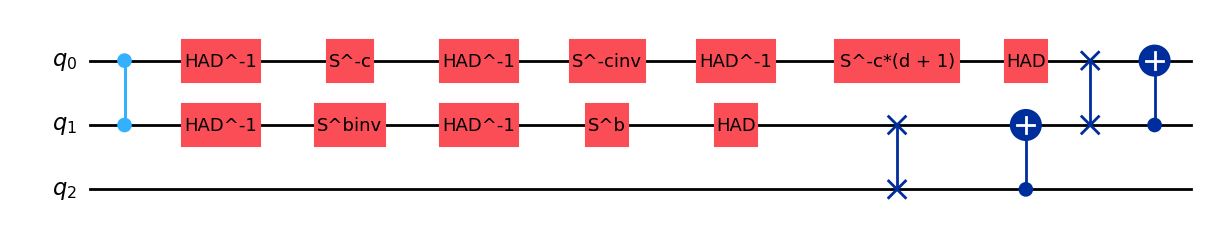

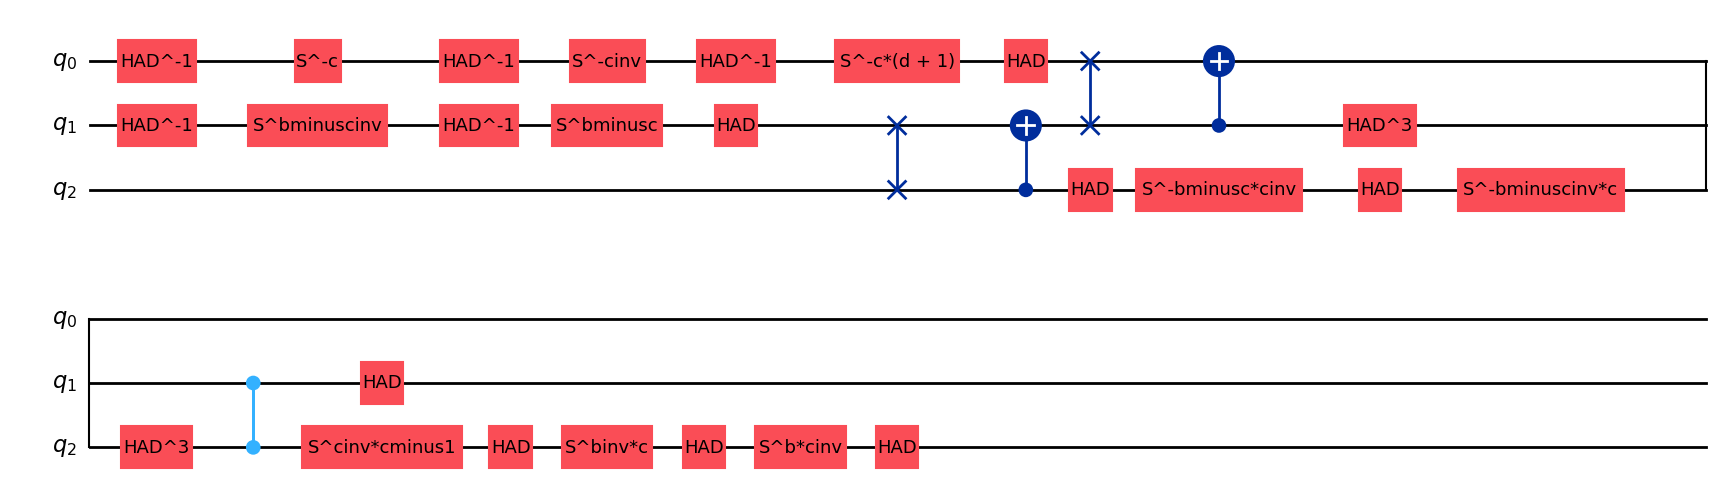

([Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), SWAP(1,2), CX(2,1), SWAP(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), SWAP(1,2), CX(2,1), HAD^-1(0), S^dinv(0), HAD^-1(0), S^d(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), SWAP(1,2), CX(2,1), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), SWAP(1,2), CX(2,1), HAD^-1(0), S^-b(0), HAD^-1(0), S^-binv(0), HAD^-1(0), S^-b*(d + 1)(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), SWAP(1,2), CX(2,1), HAD^-1(0), S^-bminus1(0), HAD^-1(0), S^-bminus1inv(0), HAD^-1(0), S^-bminus1*(d + 1)(0), HAD(0), SWAP(0,1), CX(1,0)] gates)],
 [Circuit[23](3 qudits, 0 dits, [HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), SWAP(1

In [98]:
generate_3q_CZ_B0bB_box_relations(23)

In [100]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B00_B01_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B0d_Bcd_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_DD_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_B00orB01_B_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_B0bB_box_relations)


=== Checking BR relations for p = 3 ===
✔ BR48 holds for p = 3
✔ BR49 holds for p = 3
✔ BR49-2 holds for p = 3
✔ BR50 holds for p = 3
✔ BR51 holds for p = 3
✔ BR52 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR48 holds for p = 5
✔ BR49 holds for p = 5
✔ BR49-2 holds for p = 5
✔ BR50 holds for p = 5
✔ BR51 holds for p = 5
✔ BR52 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR48 holds for p = 7
✔ BR49 holds for p = 7
✔ BR49-2 holds for p = 7
✔ BR50 holds for p = 7
✔ BR51 holds for p = 7
✔ BR52 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR48 holds for p = 11
✔ BR49 holds for p = 11
✔ BR49-2 holds for p = 11
✔ BR50 holds for p = 11
✔ BR51 holds for p = 11
✔ BR52 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR48 holds for p = 13
✔ BR49 holds for p = 13
✔ BR49-2 holds for p = 13
✔ BR50 holds for p = 13
✔ BR51 holds for p = 13
✔ BR52 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR48 holds for p = 19
✔ BR49 holds fo

## Verify: Pushing CZ through two B boxes
$BR53 \sim BR60: CZ. B_{ab}.B_{cd}$, $a,b,c,d\in \mathbb{Z}_p$

In [18]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

# # --- Define symbolic parameters ---
a, b, c, d, oneminusa, aplus1, dminusa, bminusc = symbols("a b c d oneminusa aplus1 dminusa bminusc")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (oneminusa, symbolic_inverse(oneminusa)),
    (aplus1, symbolic_inverse(aplus1)),
    (dminusa, symbolic_inverse(dminusa))
]

extra_relations = [dminusa - (d - a), bminusc - (b - c), oneminusa - (1 - a), aplus1 - (a + 1)]
extra_gens = [dminusa, bminusc, oneminusa, aplus1]

def generate_3q_CZ_BabB_box_relations(p):
    """
    Generate all B-boxes and BR53–BR60 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR53", "BR54", ...]
    """

    # --- Precompute B-boxes used in the BR relations ---
    B00_01 = instantiate_B_box(0, 0, j=0, k=1, n=3, p=p)
    B01_01 = instantiate_B_box(0, 1, j=0, k=1, n=3, p=p)
    Bminusone_b_12 = instantiate_B_box(-1, b, j=1, k=2, n=3, p=p)
    Bab_12 = instantiate_B_box(a, b, j=1, k=2, n=3, p=p)
    Bzero_minusa_01 = instantiate_B_box(0, -a, j=0, k=1, n=3, p=p)
    B1b_12 = instantiate_B_box(1, b, j=1, k=2, n=3, p=p)
    Bzero_oneminusa_01 = instantiate_B_box(0, oneminusa, j=0, k=1, n=3, p=p)
    B0a_01 = instantiate_B_box(0, a, j=0, k=1, n=3, p=p)
    Bzero_aplus1_01 = instantiate_B_box(0, aplus1, j=0, k=1, n=3, p=p)
    B0d_01 = instantiate_B_box(0, d, j=0, k=1, n=3, p=p)
    B0_dminusa_01 = instantiate_B_box(0, dminusa, j=0, k=1, n=3, p=p)
    Bcd_01 = instantiate_B_box(c, d, j=0, k=1, n=3, p=p)
    Ba_bminusc_12 = instantiate_B_box(a, bminusc, j=1, k=2, n=3, p=p)
    Bc_dminusa_01 = instantiate_B_box(c, dminusa, j=0, k=1, n=3, p=p)

    # --- Build BR relations ---

    # BR53
    BR53lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR53rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR53lhs += CZ(0,1) + Bminusone_b_12 + B00_01
    BR53rhs += Bminusone_b_12 + B01_01 + HAD(2) + CZ(1,2) + HAD(2) ** 3
    # display(BR53lhs.draw())
    # display(BR53rhs.draw())

    # BR54
    BR54lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR54rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR54lhs += CZ(0,1) + Bab_12 + B00_01
    BR54rhs += Bab_12 + Bzero_minusa_01 + (
                HAD(1) + S(1) ** a + HAD(1) + S(1) ** symbolic_inverse(a)
                + HAD(1) ** 3 + HAD(2) ** 3 + CZ(1,2) ** a + HAD(2))
    # display(BR54lhs.draw())
    # display(BR54rhs.draw())

    # BR55
    BR55lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR55rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR55lhs += CZ(0,1) + B1b_12 + B01_01
    BR55rhs += B1b_12 + B00_01 + (HAD(2) ** 3 + CZ(1, 2) + HAD(2))
    # display(BR55lhs.draw())
    # display(BR55rhs.draw())

    # BR56
    BR56lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR56rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR56lhs += CZ(0,1) + Bab_12 + B01_01
    BR56rhs += Bab_12 + Bzero_oneminusa_01 + (
                HAD(1) + S(1) ** (-oneminusa) + HAD(1) + S(1) ** symbolic_inverse(-oneminusa)
                + HAD(1) ** 3 + HAD(2) ** 3 + CZ(1,2) ** a + HAD(2))
    # display(BR56lhs.draw())
    # display(BR56rhs.draw())

    # BR57
    BR57lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR57rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR57lhs += CZ(0,1) + Bab_12 + B0a_01
    BR57rhs += Bab_12 + B00_01 + (
                HAD(1) + S(1) ** symbolic_inverse(a) + HAD(1) + S(1) ** a
                + HAD(1) + HAD(2) ** 3 + CZ(1,2) + HAD(2))
    # display(BR57lhs.draw())
    # display(BR57rhs.draw())

    # BR58
    BR58lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR58rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR58lhs += CZ(0,1) + Bab_12 + Bzero_aplus1_01
    BR58rhs += Bab_12 + B01_01 + (
                HAD(1) + S(1) ** symbolic_inverse(aplus1) + HAD(1) + S(1) ** aplus1
                + HAD(1) + HAD(2) ** 3 + CZ(1,2) ** (a * symbolic_inverse(aplus1)) + HAD(2))
    # display(BR58lhs.draw())
    # display(BR58rhs.draw())

    # BR59
    BR59lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR59rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR59lhs += CZ(0,1) + Bab_12 + B0d_01
    BR59rhs += Bab_12 + B0_dminusa_01 + (
                HAD(1) + S(1) ** (dminusa * symbolic_inverse(a)) + HAD(1) 
                + S(1) ** (a * symbolic_inverse(dminusa)) + HAD(1) + HAD(2) ** 3
                + CZ(1,2) + S(1) ** (- aplus1 * symbolic_inverse(a)) 
                + HAD(1) + S(1) ** (- a * symbolic_inverse(d)) + HAD(1) + S(1) ** (- d * symbolic_inverse(a))
                + HAD(1) ** 3 + HAD(2))
    # display(BR59lhs.draw())
    # display(BR59rhs.draw())

    # BR60
    BR60lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR60rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR60lhs += CZ(0,1) + Bab_12 + Bcd_01
    BR60rhs += Ba_bminusc_12 + Bc_dminusa_01 + (
                HAD(1) + HAD(2) 
                + S(1) ** (-a * c) + S(2) ** (-a * c)
                + CZ(1,2) ** (a * c) + HAD(1) ** 3 + HAD(2) ** 3)


    # Put all circuits in order
    lhs_list = [BR53lhs, BR54lhs, BR55lhs, BR56lhs, BR57lhs, BR58lhs, BR59lhs, BR60lhs]
    rhs_list = [BR53rhs, BR54rhs, BR55rhs, BR56rhs, BR57rhs, BR58rhs, BR59rhs, BR60rhs]

    relation_names = ["BR53", "BR54", "BR55", "BR56", "BR57", "BR58", "BR59", "BR60"]

    return lhs_list, rhs_list, relation_names


In [180]:
from sympy import symbols

a, d, dminusa, cminusb = symbols("a d dminusa cminusb")
b, binv = symbols("b binv")   # example
params = [(a, symbols("ainv")), (b, binv), (d, symbols("dinv"))]

extra_relations = [dminusa - (d - a), cminusb - (c - b)]
extra_gens = [dminusa, cminusb]

M = Matrix([[dminusa + a,cminusb + b],[dminusa + a,cminusb + b]])

M_red = reduce_matrix(M, params, extra_relations=extra_relations, extra_gens=extra_gens)
display(M_red)

Matrix([
[d, c],
[d, c]])

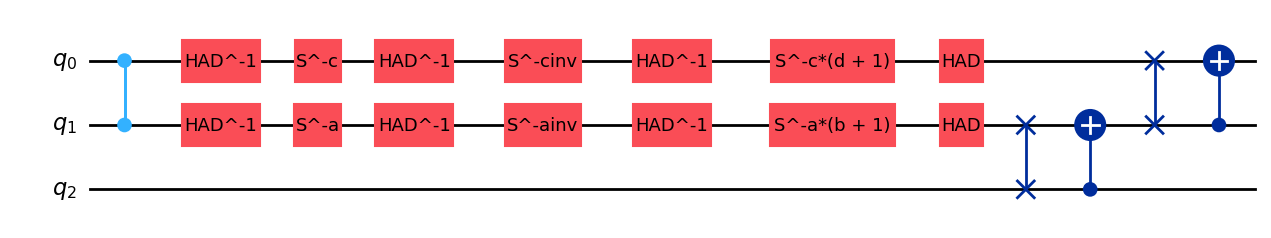

Matrix([
[     dminusa, -c,     bminusc, -d + dminusa, 1,  0],
[           0,  0,           0,            0, 0,  1],
[           d, -c,          -c,            0, 0,  0],
[        cinv,  0,           0,            0, 0, -1],
[-d + dminusa,  0, bminusc + c, -d + dminusa, 0,  0],
[           0,  0,        ainv,            0, 0, -1]])

Matrix([
[     dminusa, -c,     bminusc, -d + dminusa, 1,  0],
[           0,  0,           0,            0, 0,  1],
[           d, -c,          -c,            0, 0,  0],
[        cinv,  0,           0,            0, 0, -1],
[-d + dminusa,  0, bminusc + c, -d + dminusa, 0,  0],
[           0,  0,        ainv,            0, 0, -1]])

In [ ]:
from sympy import symbols

a, b, c, d, oneminusa, aplus1, dminusa, bminusc = symbols("a b c d oneminusa aplus1 dminusa bminusc")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
]

# --- Precompute B-boxes used in the BR relations ---
p = 23
Bab_12 = instantiate_B_box(a, b, j=1, k=2, n=3, p=p)
Bcd_01 = instantiate_B_box(c, d, j=0, k=1, n=3, p=p)
Ba_bminusc_12 = instantiate_B_box(a, bminusc, j=1, k=2, n=3, p=p)
Bc_dminusa_01 = instantiate_B_box(c, dminusa, j=0, k=1, n=3, p=p)

# a, d, dminusa = symbols("a d dminusa")
# b, binv = symbols("b binv")   # example
# params = [(a, symbols("ainv")), (b, binv), (d, symbols("dinv"))]

extra_relations = [dminusa - (d - a), bminusc - (b - c)]
extra_gens = [dminusa, bminusc]

BR60lhs = dizx.Circuit(qudit_amount=3, dim=p)
BR60rhs = dizx.Circuit(qudit_amount=3, dim=p)
BR60lhs += CZ(0,1) + Bab_12 + Bcd_01
BR60rhs += Ba_bminusc_12 + Bc_dminusa_01 + (
            HAD(1) + HAD(2) 
            + S(1) ** (-a * c) + S(2) ** (-a * c)
            + CZ(1,2) ** (a * c) + HAD(1) ** 3 + HAD(2) ** 3)
display(BR60lhs.draw())
BR60lhs_m = BR60lhs.to_symplectic_matrix()
BR60lhs_reduce = reduce_matrix(BR60lhs_m, params, extra_relations=extra_relations, extra_gens=extra_gens)

display(BR60lhs_reduce)

BR60rhs_m = BR60rhs.to_symplectic_matrix()
BR60rhs_reduce = reduce_matrix(BR60rhs_m, params, extra_relations=extra_relations, extra_gens=extra_gens)
display(BR60rhs_reduce)



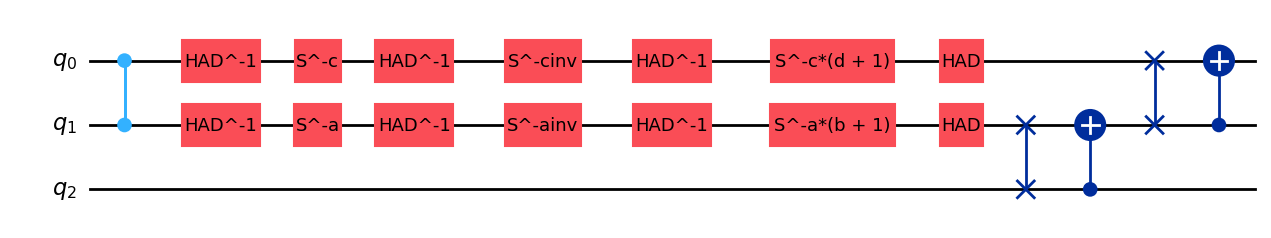

Matrix([
[-a + d, -c, b - c, -a, 1,  0],
[     0,  0,     0,  0, 0,  1],
[     d, -c,    -c,  0, 0,  0],
[  cinv,  0,     0,  0, 0, -1],
[    -a,  0,     b, -a, 0,  0],
[     0,  0,  ainv,  0, 0, -1]])

Matrix([
[    dminusa, -c,     bminusc, -a, 1,  0],
[          0,  0,           0,  0, 0,  1],
[a + dminusa, -c,          -c,  0, 0,  0],
[       cinv,  0,           0,  0, 0, -1],
[         -a,  0, bminusc + c, -a, 0,  0],
[          0,  0,        ainv,  0, 0, -1]])

([Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S(1), HAD^-1(1), S(1), HAD^-1(1), S^b + 1(1), HAD(1), SWAP(1,2), CX(2,1), SWAP(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(1,2), CX(2,1), SWAP(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^-1(1), HAD^-1(1), S^-1(1), HAD^-1(1), S^-b - 1(1), HAD(1), SWAP(1,2), CX(2,1), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(1,2), CX(2,1), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(1,2), CX(2,1), HAD^-1(0), S^ainv(0), HAD^-1(0), S^a(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(1,2), CX(2,1), HAD^

In [ ]:
generate_3q_CZ_BabB_box_relations(23)

In [19]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B00_B01_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B0d_Bcd_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_DD_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_B00orB01_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_B0bB_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_BabB_box_relations, extra_relations, extra_gens=extra_gens)


=== Checking BR relations for p = 3 ===
✔ BR53 holds for p = 3
✔ BR54 holds for p = 3
✔ BR55 holds for p = 3
✔ BR56 holds for p = 3
✔ BR57 holds for p = 3
✔ BR58 holds for p = 3
✔ BR59 holds for p = 3
✔ BR60 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR53 holds for p = 5
✔ BR54 holds for p = 5
✔ BR55 holds for p = 5
✔ BR56 holds for p = 5
✔ BR57 holds for p = 5
✔ BR58 holds for p = 5
✔ BR59 holds for p = 5
✔ BR60 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR53 holds for p = 7
✔ BR54 holds for p = 7
✔ BR55 holds for p = 7
✔ BR56 holds for p = 7
✔ BR57 holds for p = 7
✔ BR58 holds for p = 7
✔ BR59 holds for p = 7
✔ BR60 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR53 holds for p = 11
✔ BR54 holds for p = 11
✔ BR55 holds for p = 11
✔ BR56 holds for p = 11
✔ BR57 holds for p = 11
✔ BR58 holds for p = 11
✔ BR59 holds for p = 11
✔ BR60 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR53 holds for p = 13
✔ BR54 holds for p = 13
✔

## Verify: Pushing CZ through a B box
$BR61 \& BR62: CZ. B_{ab}$, $a,b\in \mathbb{Z}_p$

In [70]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

def generate_3q_CZ_B_box_relations(p):
    """
    Generate all B-boxes and BR61–BR62 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR61", "BR62", "BR62-2"]
    """

    # --- Define symbolic parameters ---
    a, b = symbols("a b")

    # --- Precompute B-boxes used in the BR relations ---
    B00_01 = instantiate_B_box(0, 0, j=0, k=1, n=3, p=p)
    B01_01 = instantiate_B_box(0, 1, j=0, k=1, n=3, p=p)
    B0b_01 = instantiate_B_box(0, b, j=0, k=1, n=3, p=p)
    Bab_01 = instantiate_B_box(a, b, j=0, k=1, n=3, p=p)

    # --- Build BR relations ---

    # BR61
    BR61lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR61rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR61lhs += CZ(1,2) + B00_01
    BR61rhs += B00_01 + (
        HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + CZ(0,1)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
    )
    # print("BR61lhs")
    # display(BR61lhs.draw())
    # print("BR61rhs")
    # display(BR61rhs.draw())

     # BR62
    BR62lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62lhs += CZ(1,2) + Bab_01
    BR62rhs += Bab_01 + (
        HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + CZ(0,1)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2)
    )
    # print("BR62lhs")
    # display(BR62lhs.draw())
    # print("BR62rhs")
    # display(BR62rhs.draw())

    # BR62-2
    BR62_2lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62_2rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62_2lhs += CZ(1,2) + B01_01
    BR62_2rhs += B01_01 + (
        HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + CZ(0,1)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2)
    )
    # print("BR62-2lhs")
    # display(BR62_2lhs.draw())
    # print("BR62-2rhs")
    # display(BR62_2rhs.draw())

    # BR62-3
    BR62_3lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62_3rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62_3lhs += CZ(1,2) + B0b_01
    BR62_3rhs += B0b_01 + (
        HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + CZ(0,1)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2)
    )
    # print("BR62-3lhs")
    # display(BR62_3lhs.draw())
    # print("BR62-3rhs")
    # display(BR62_3rhs.draw())


    # Put all circuits in order
    lhs_list = [BR61lhs, BR62lhs, BR62_2lhs, BR62_3lhs]
    rhs_list = [BR61rhs, BR62rhs, BR62_2rhs, BR62_3rhs]

    relation_names = ["BR61", "BR62", "BR62-2", "BR62-3"]

    return lhs_list, rhs_list, relation_names


In [72]:
# generate_3q_CZ_B_box_relations(23)

In [73]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B00_B01_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B0d_Bcd_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_B_box_relations)



=== Checking BR relations for p = 3 ===
✔ BR61 holds for p = 3
✔ BR62 holds for p = 3
✔ BR62-2 holds for p = 3
✔ BR62-3 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR61 holds for p = 5
✔ BR62 holds for p = 5
✔ BR62-2 holds for p = 5
✔ BR62-3 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR61 holds for p = 7
✔ BR62 holds for p = 7
✔ BR62-2 holds for p = 7
✔ BR62-3 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR61 holds for p = 11
✔ BR62 holds for p = 11
✔ BR62-2 holds for p = 11
✔ BR62-3 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR61 holds for p = 13
✔ BR62 holds for p = 13
✔ BR62-2 holds for p = 13
✔ BR62-3 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR61 holds for p = 19
✔ BR62 holds for p = 19
✔ BR62-2 holds for p = 19
✔ BR62-3 holds for p = 19

=== Checking BR relations for p = 23 ===
✔ BR61 holds for p = 23
✔ BR62 holds for p = 23
✔ BR62-2 holds for p = 23
✔ BR62-3 holds for p = 23

=== All primes proce

## Verify: Pushing CZ through two D boxes
$BR63 \sim BR66: CZ. B_{ab}. B_{cd}$, $a,b,c,d\in \mathbb{Z}_p$

In [14]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

# --- Define symbolic parameters ---
a, b, c, d= symbols("a b c d")

params = [
    (a, symbolic_inverse(a)),
    (b, symbolic_inverse(b)),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d))
]

def generate_3q_CZ_DD_box_relations(p):
    """
    Generate all D-boxes and BR63–BR66 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR63", "BR64", "BR65", "BR66"]
    """

    # --- Define symbolic parameters ---
    a, b, c, d = symbols("a b c d")

    # --- Precompute D-boxes used in the BR relations ---
    D0b_01 = instantiate_D_box(0, b, 0, 1, 3, p)
    D0d_12 = instantiate_D_box(0, d, 1, 2, 3, p)

    Dcd_12 = instantiate_D_box(c, d, j=1, k=2, n=3, p=p)
    D0bminusc_01 = instantiate_D_box(0, b-c, j=0, k=1, n=3, p=p)

    Dab_01 = instantiate_D_box(a, b, j=0, k=1, n=3, p=p)
    D0dminusa_12 = instantiate_D_box(0, d-a, j=1, k=2, n=3, p=p)

    Dcd_12 = instantiate_D_box(c, d, j=1, k=2, n=3, p=p)
    Dabminusc_01 = instantiate_D_box(a, b-c, j=0, k=1, n=3, p=p)
    Dcdminusa_12 = instantiate_D_box(c, d-a, j=1, k=2, n=3, p=p)   

    # --- Build BR relations ---

    # BR63
    BR63lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR63rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR63lhs += CZ(1,2) + D0b_01 + D0d_12
    BR63rhs += D0b_01 + D0d_12 + CZ(0,1)
    print("BR63")
    display(BR63lhs.draw())
    display(BR63rhs.draw())

    # BR64
    BR64lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR64rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR64lhs += CZ(1,2) + D0b_01 + Dcd_12
    BR64rhs += D0bminusc_01 + Dcd_12 + HAD(1)**3 + CZ(0,1) ** c + HAD(1)
    print("BR64")
    display(BR64lhs.draw())
    display(BR64rhs.draw())

    # BR65
    BR65lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR65rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR65lhs += CZ(1,2) + Dab_01 + D0d_12
    BR65rhs += Dab_01 + D0dminusa_12 + HAD(0)**3 + CZ(0,1) ** a + HAD(0)
    print("BR65")
    display(BR65lhs.draw())
    display(BR65rhs.draw())

    # BR66
    BR66lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR66rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR66lhs += CZ(1,2) + Dab_01 + Dcd_12
    BR66rhs += (Dabminusc_01 + Dcdminusa_12 
            + HAD(0)**3 
            + HAD(1)**3 
            + S(0)**(-a * c) 
            + S(1)**(-a * c) 
            + CZ(0,1) ** (a*c) 
            + HAD(0) 
            + HAD(1))
    print("BR66")
    display(BR66lhs.draw())
    display(BR66rhs.draw())


    # Put all circuits in order
    lhs_list = [BR63lhs,BR64lhs,BR65lhs,BR66lhs]
    rhs_list = [BR63rhs,BR64rhs,BR65rhs,BR66rhs]

    relation_names = ["BR63","BR64","BR65","BR66"]

    return lhs_list, rhs_list, relation_names


BR63


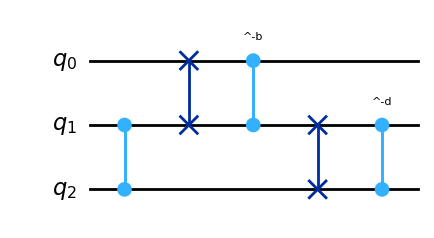

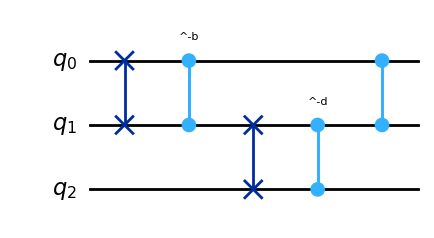

BR64


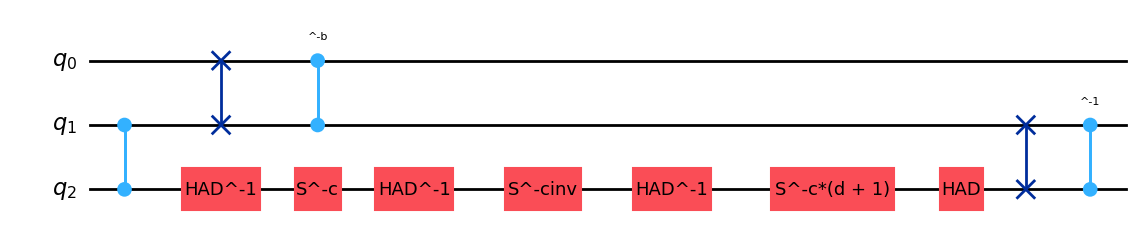

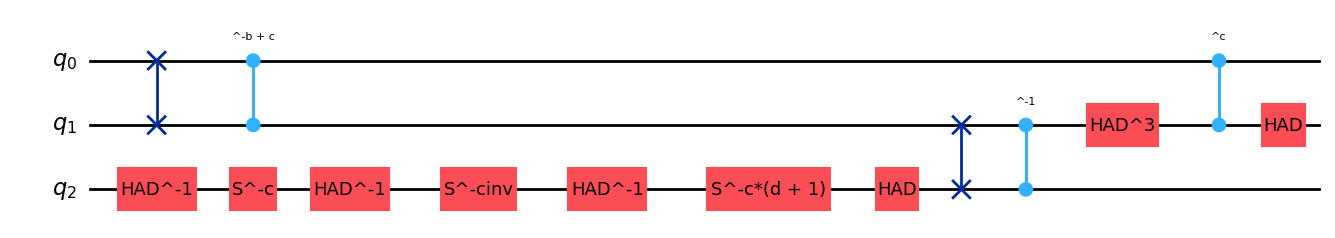

BR65


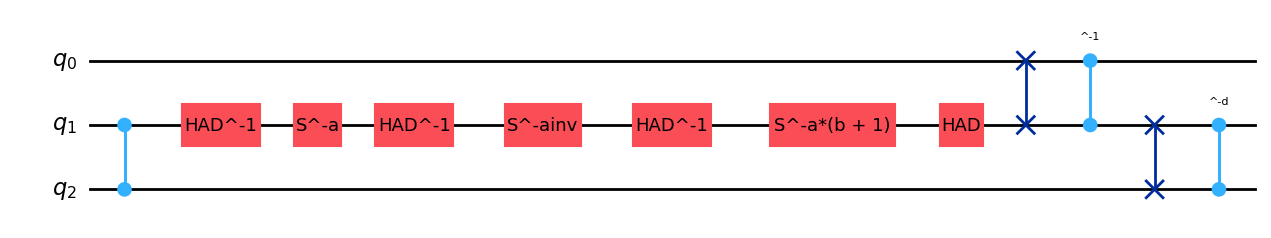

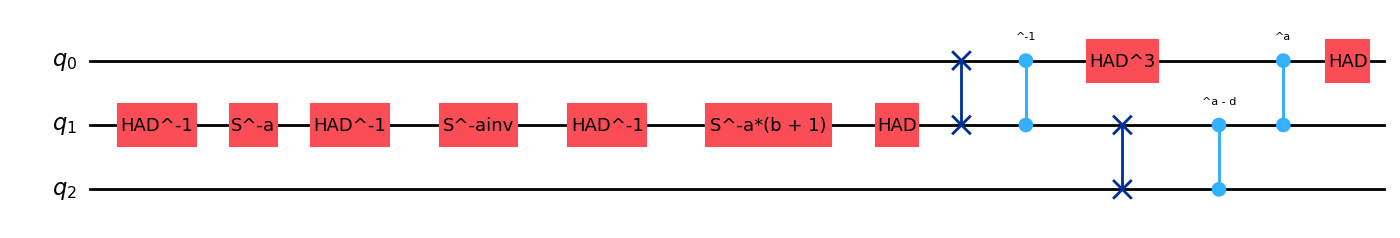

BR66


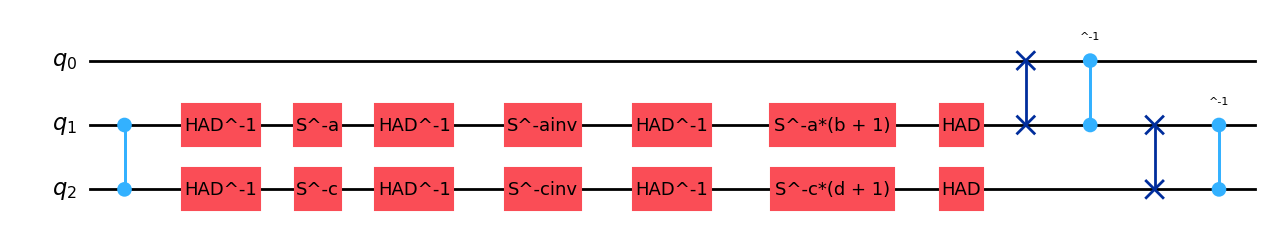

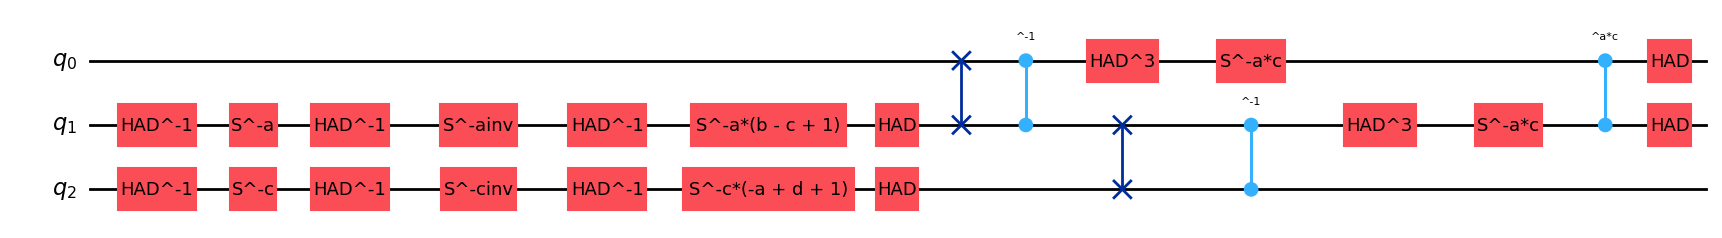

([Circuit[23](3 qudits, 0 dits, [CZ(1,2), SWAP(0,1), CZ^-b(0,1), SWAP(1,2), CZ^-d(1,2)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), SWAP(0,1), CZ^-b(0,1), HAD^-1(2), S^-c(2), HAD^-1(2), S^-cinv(2), HAD^-1(2), S^-c*(d + 1)(2), HAD(2), SWAP(1,2), CZ^-1(1,2)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(0,1), CZ^-1(0,1), SWAP(1,2), CZ^-d(1,2)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(0,1), CZ^-1(0,1), HAD^-1(2), S^-c(2), HAD^-1(2), S^-cinv(2), HAD^-1(2), S^-c*(d + 1)(2), HAD(2), SWAP(1,2), CZ^-1(1,2)] gates)],
 [Circuit[23](3 qudits, 0 dits, [SWAP(0,1), CZ^-b(0,1), SWAP(1,2), CZ^-d(1,2), CZ(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [SWAP(0,1), CZ^-b + c(0,1), HAD^-1(2), S^-c(2), HAD^-1(2), S^-cinv(2), HAD^-1(2), S^-c*(d + 1)(2), HAD(2), SWAP(1,2), CZ^-1(1,2), HAD^3(1), CZ^c(0,1), HAD(1)] gates),
  Ci

In [15]:
generate_3q_CZ_DD_box_relations(23)


=== Checking BR relations for p = 3 ===
BR63


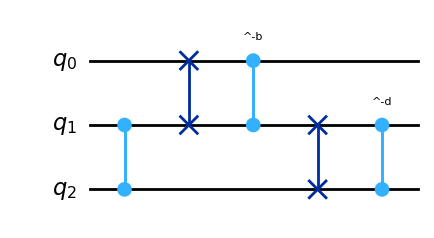

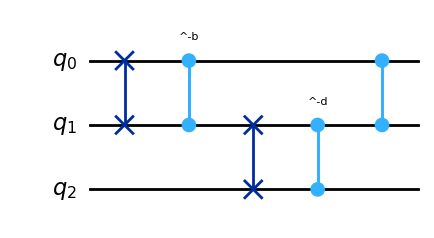

BR64


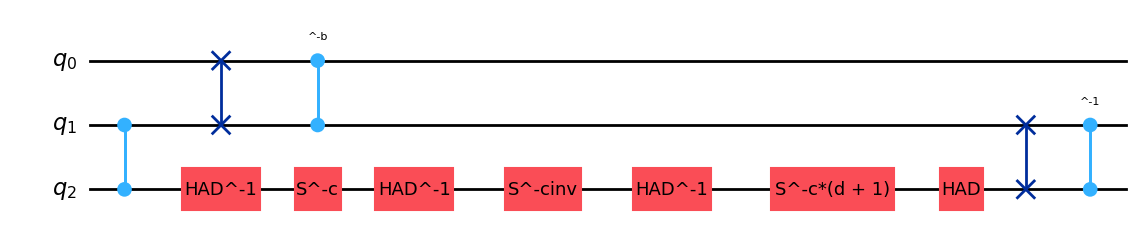

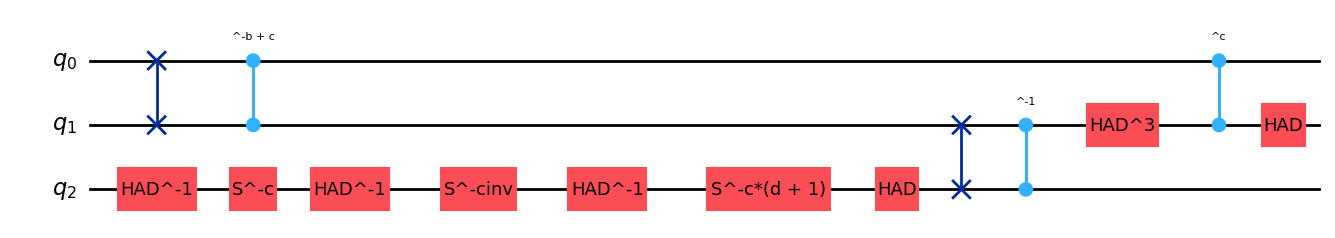

BR65


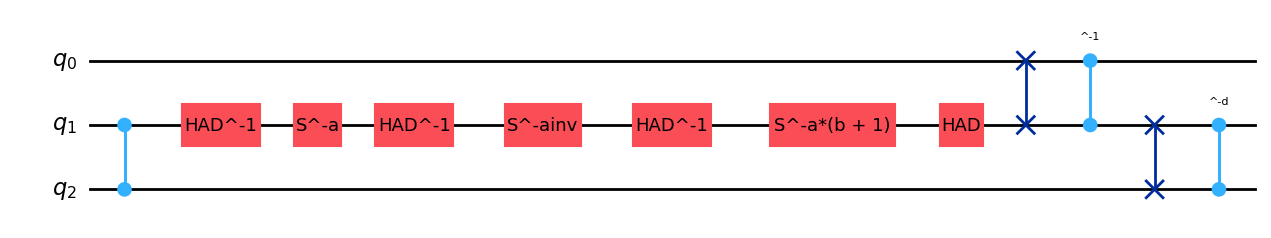

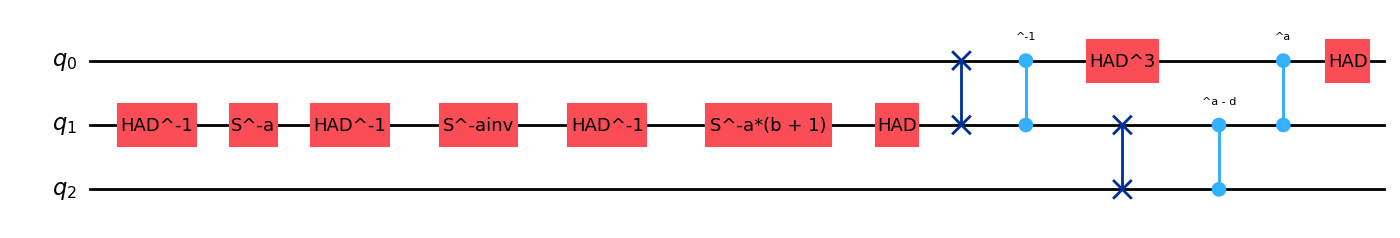

BR66


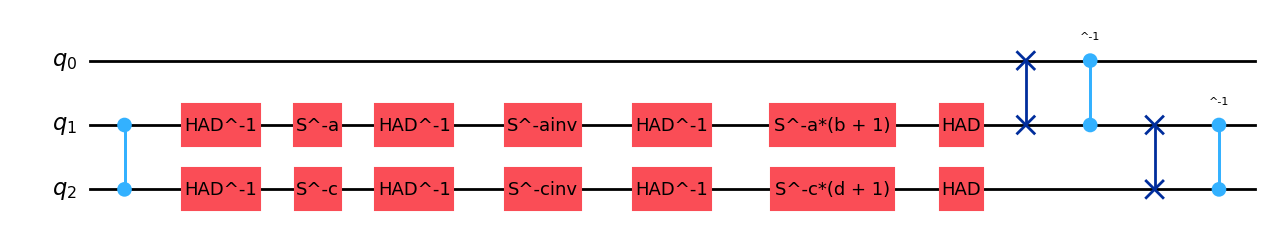

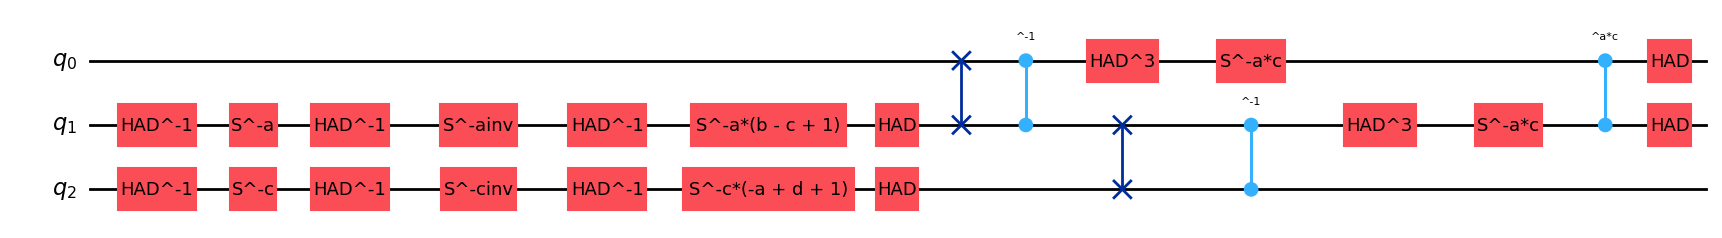

✔ BR63 holds for p = 3
✔ BR64 holds for p = 3
✔ BR65 holds for p = 3
✔ BR66 holds for p = 3

=== Checking BR relations for p = 5 ===
BR63


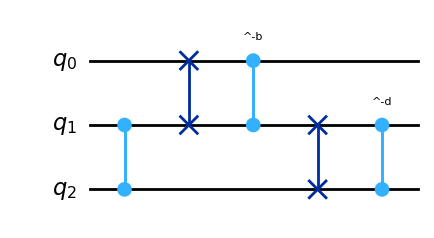

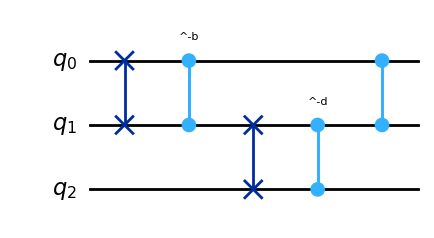

BR64


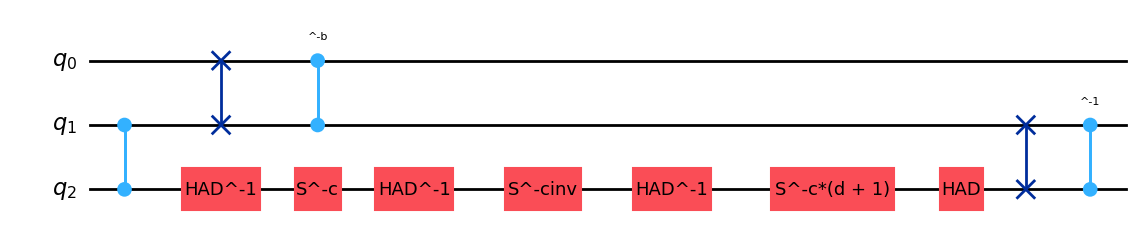

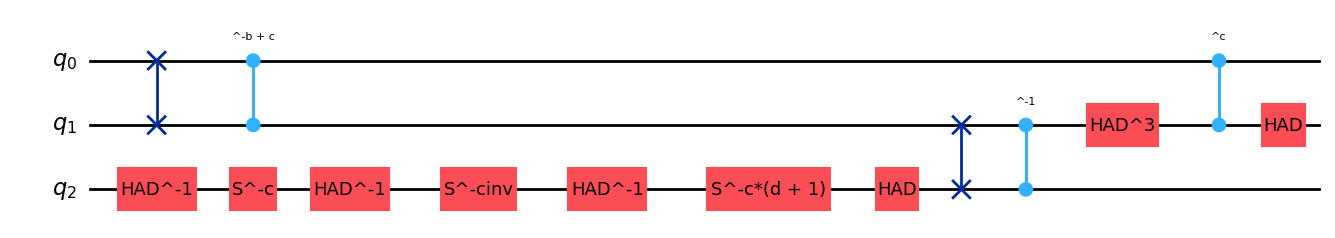

BR65


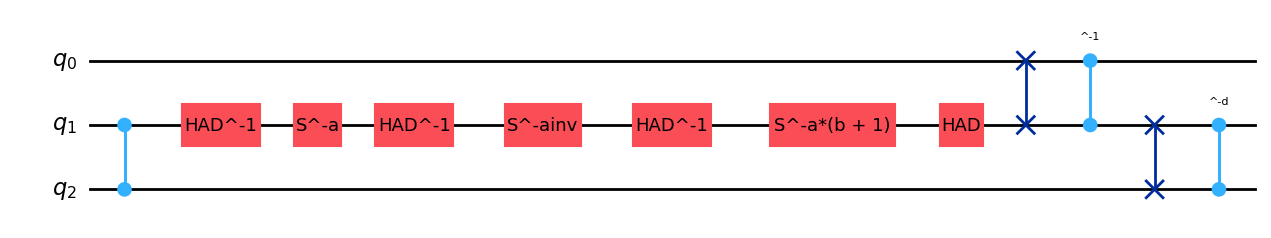

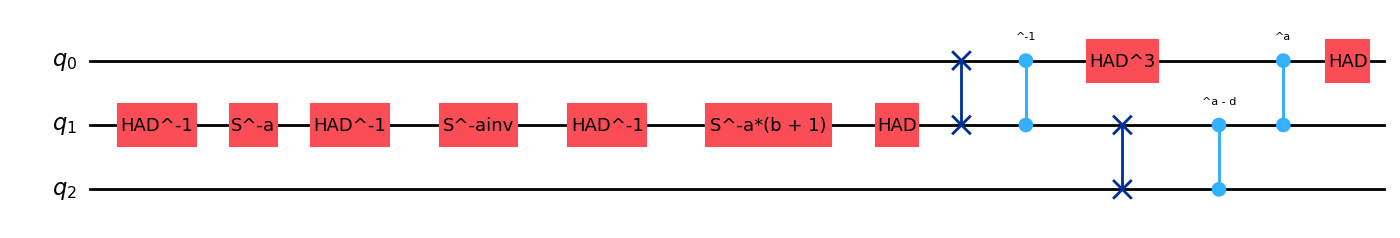

BR66


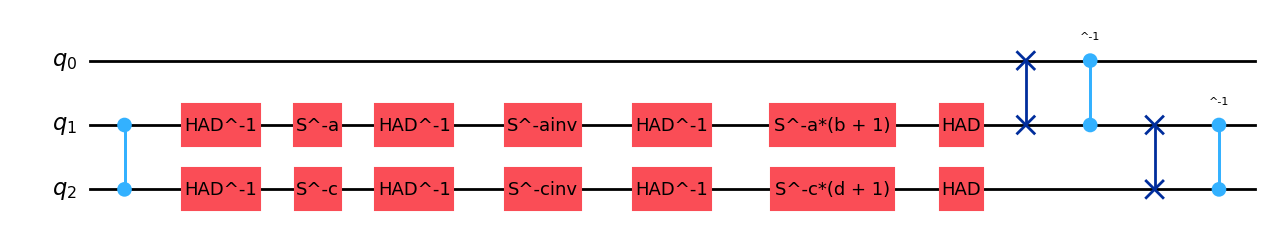

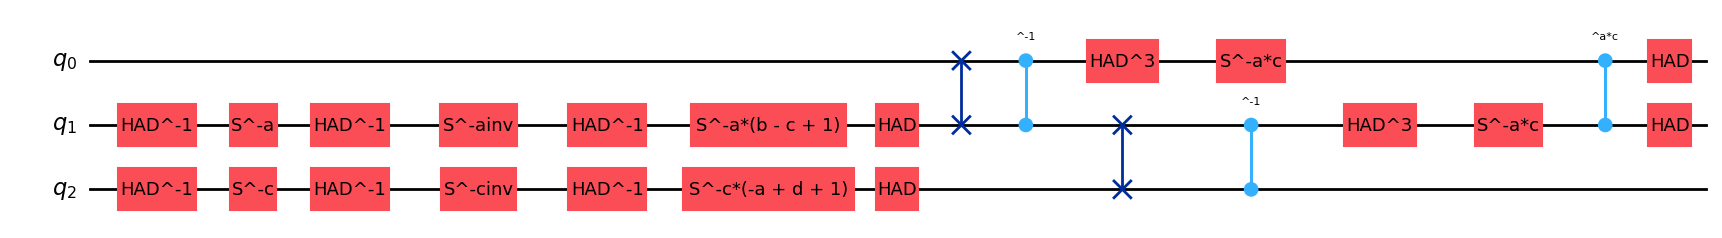

✔ BR63 holds for p = 5
✔ BR64 holds for p = 5
✔ BR65 holds for p = 5
✔ BR66 holds for p = 5

=== Checking BR relations for p = 7 ===
BR63


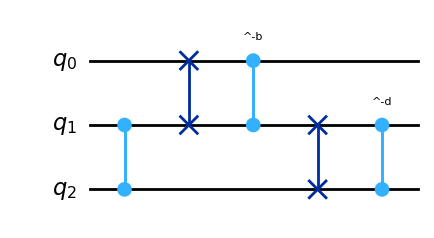

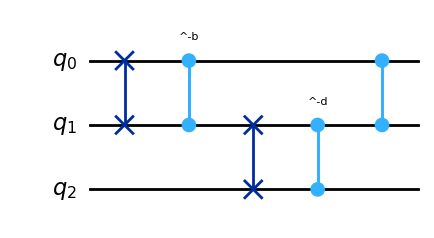

BR64


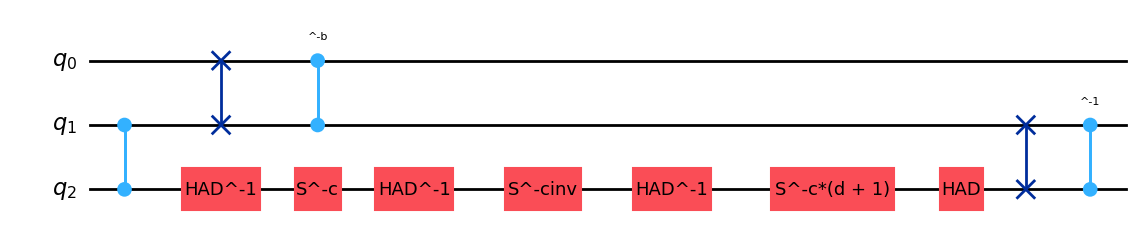

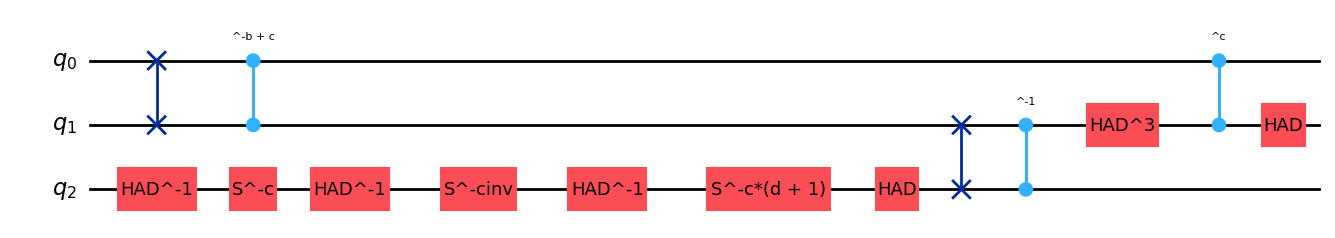

BR65


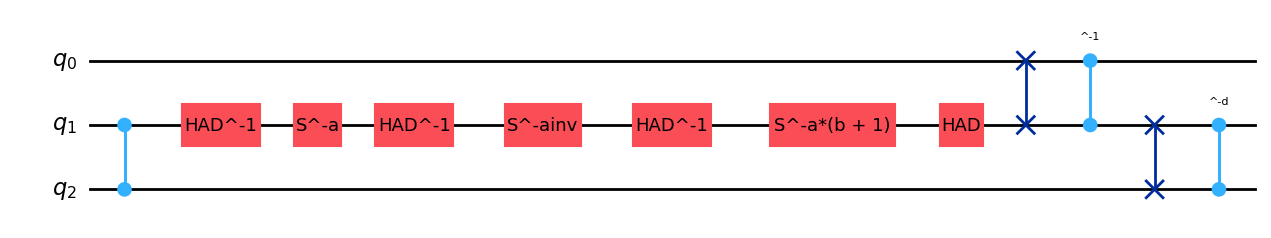

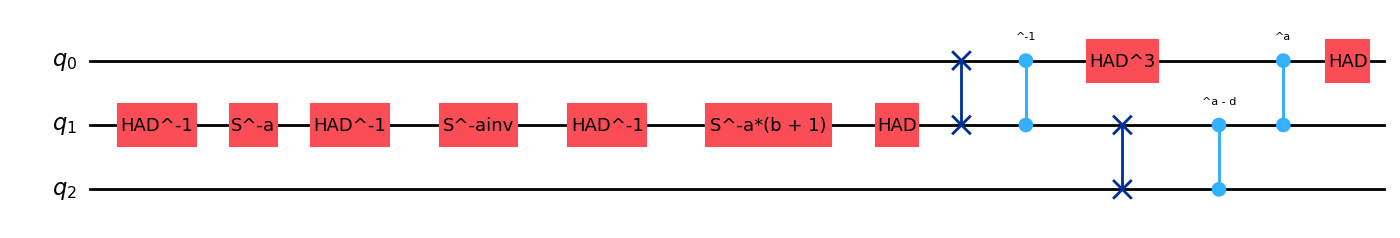

BR66


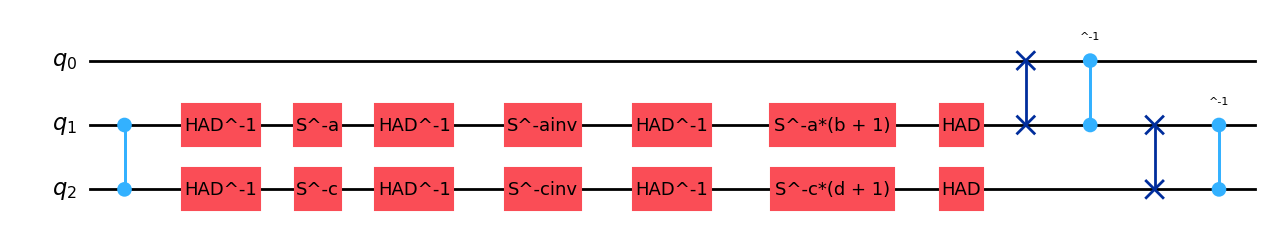

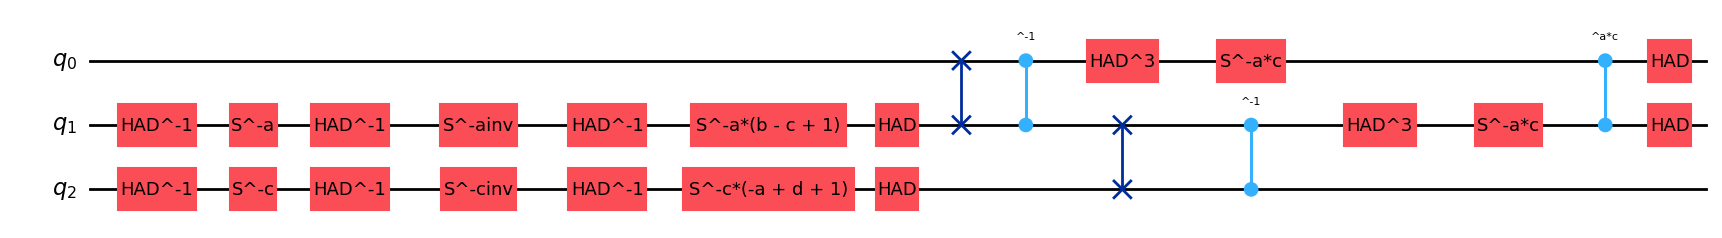

✔ BR63 holds for p = 7
✔ BR64 holds for p = 7
✔ BR65 holds for p = 7
✔ BR66 holds for p = 7

=== Checking BR relations for p = 11 ===
BR63


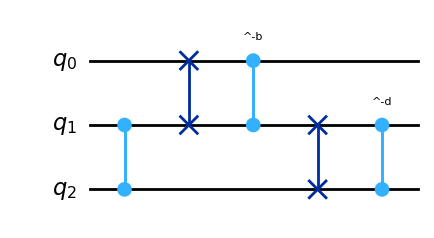

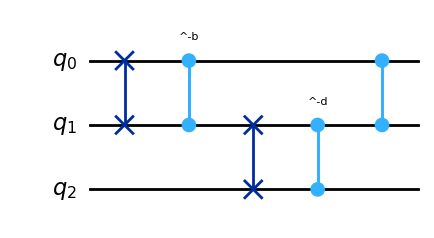

BR64


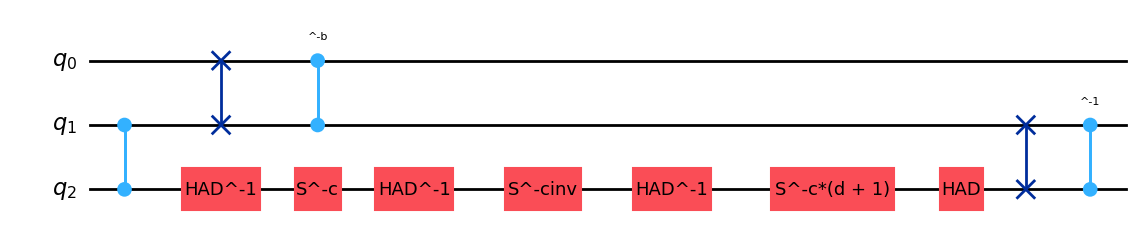

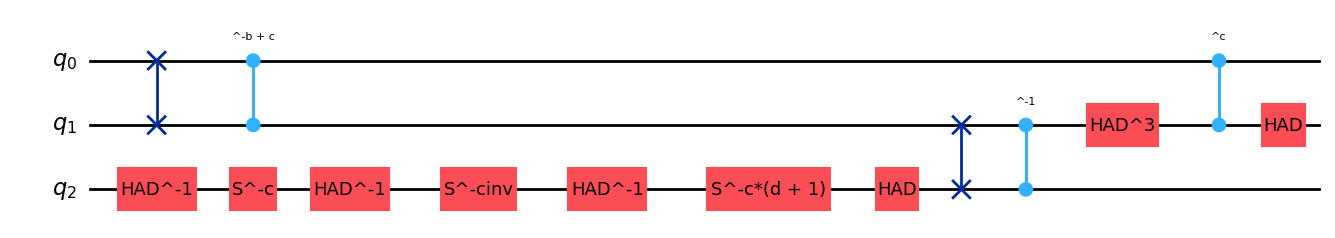

BR65


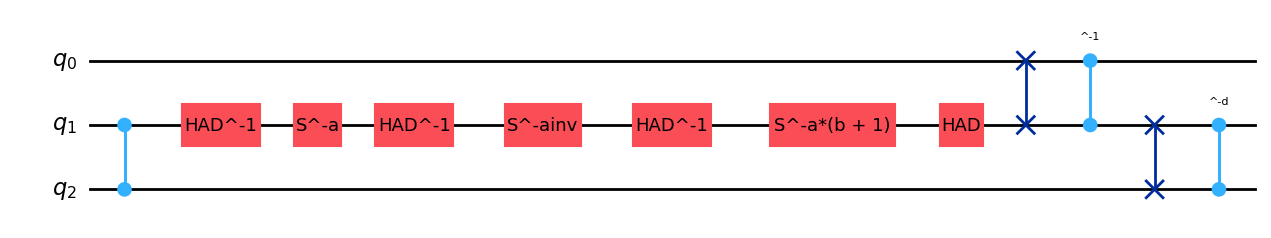

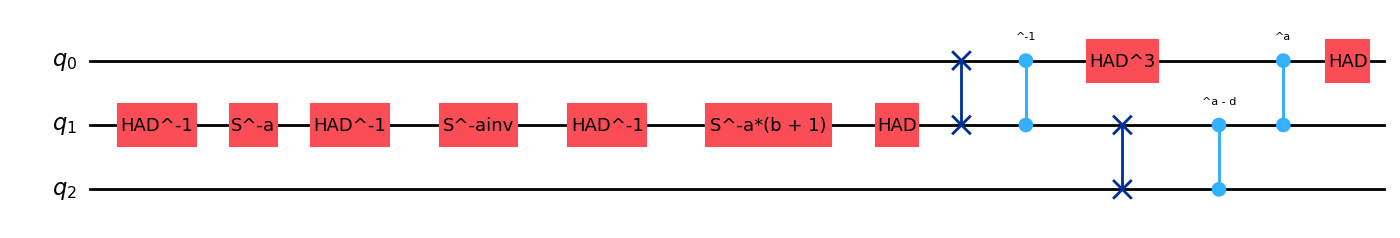

BR66


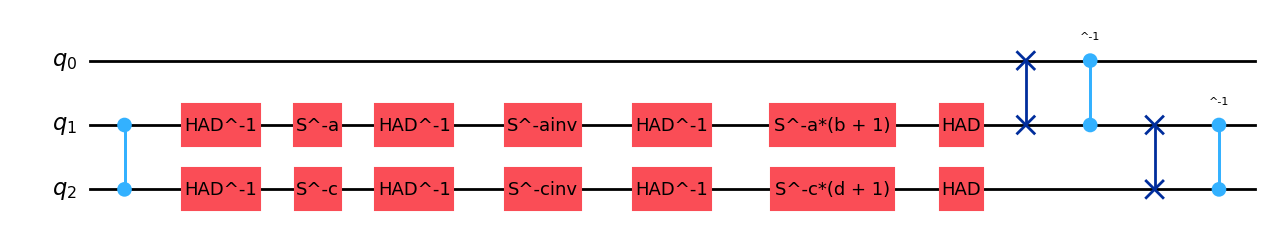

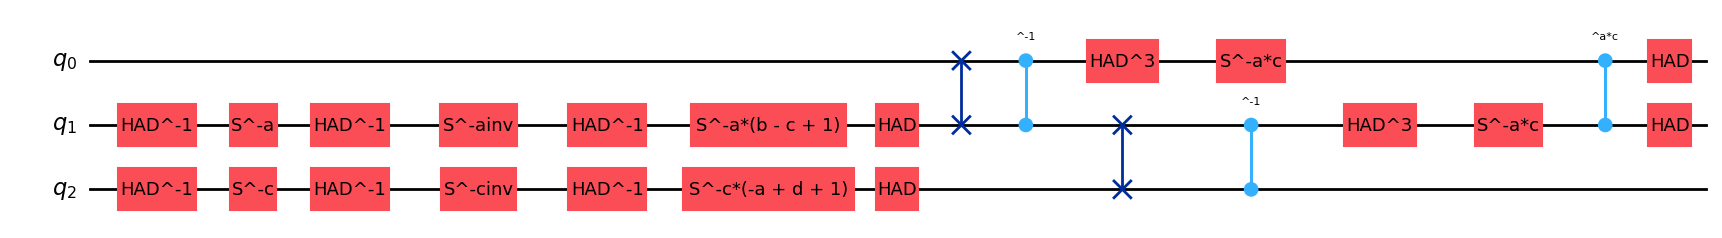

✔ BR63 holds for p = 11
✔ BR64 holds for p = 11
✔ BR65 holds for p = 11
✔ BR66 holds for p = 11

=== Checking BR relations for p = 13 ===
BR63


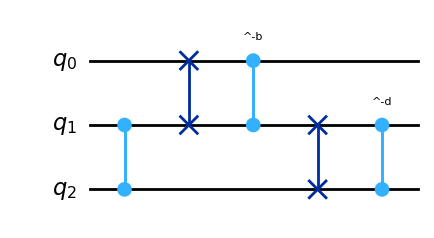

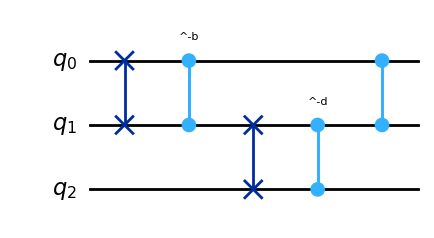

BR64


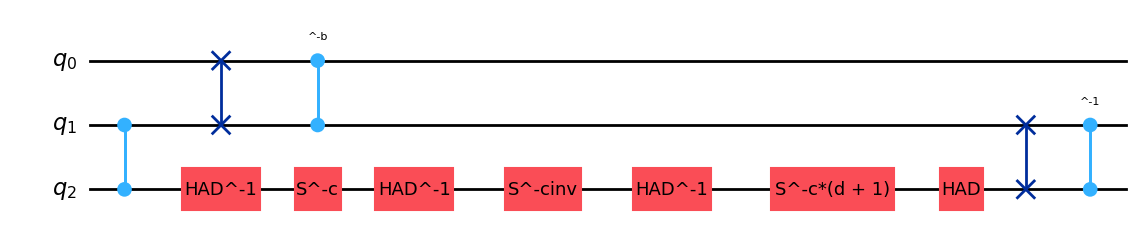

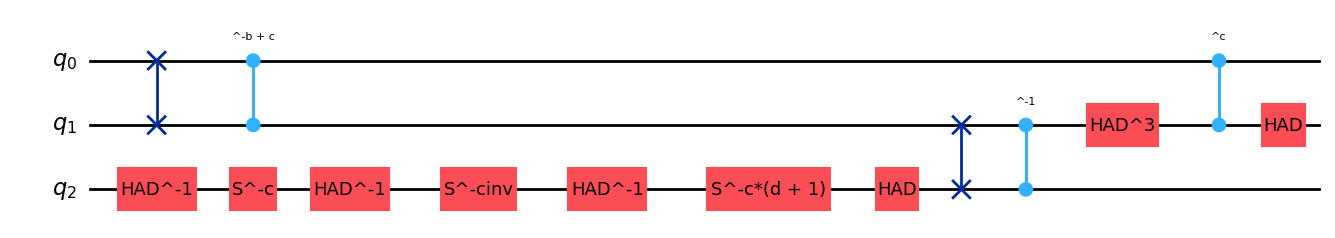

BR65


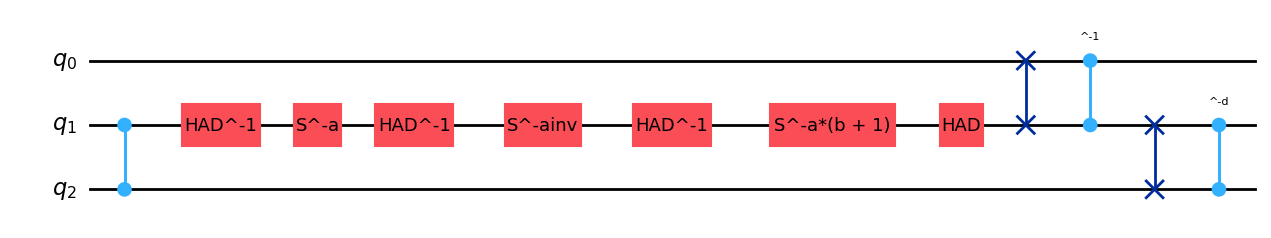

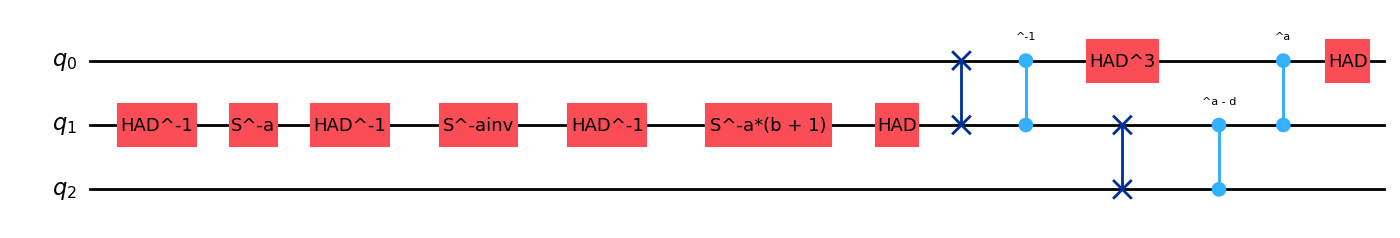

BR66


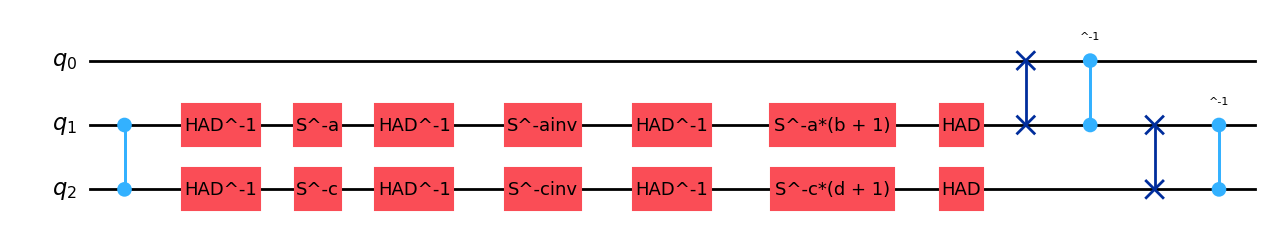

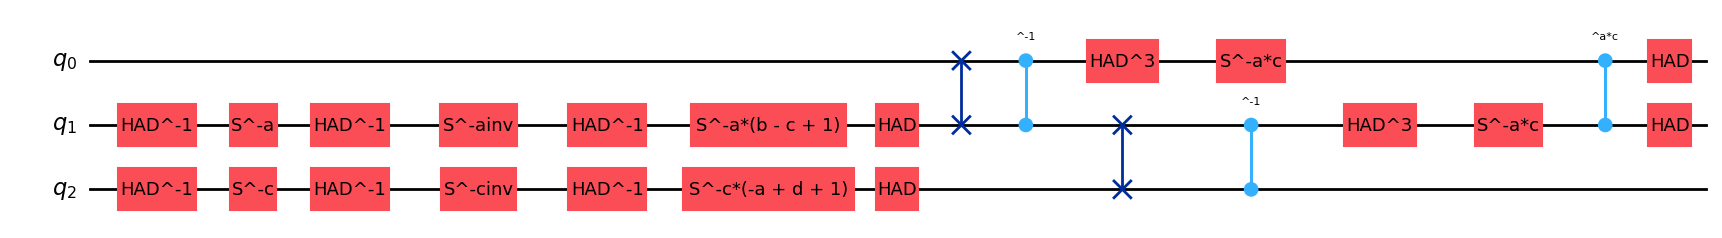

✔ BR63 holds for p = 13
✔ BR64 holds for p = 13
✔ BR65 holds for p = 13
✔ BR66 holds for p = 13

=== Checking BR relations for p = 19 ===
BR63


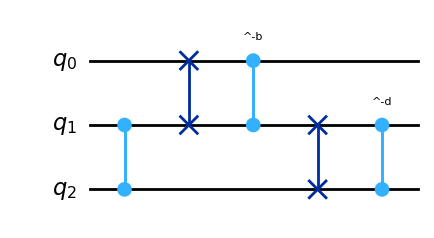

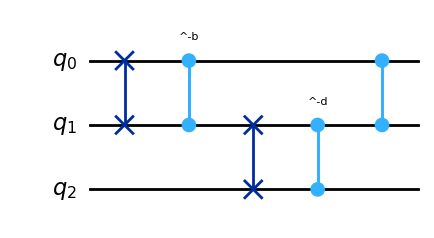

BR64


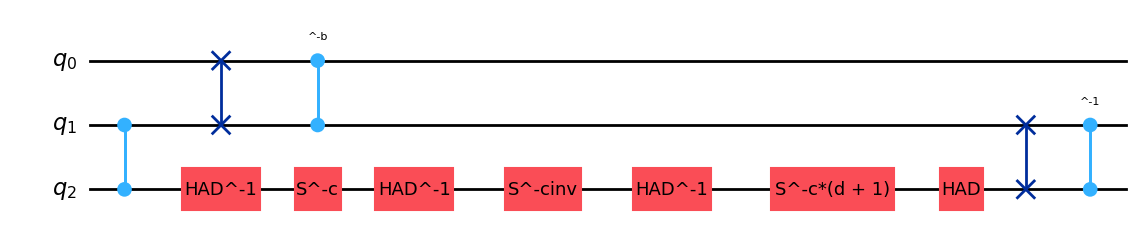

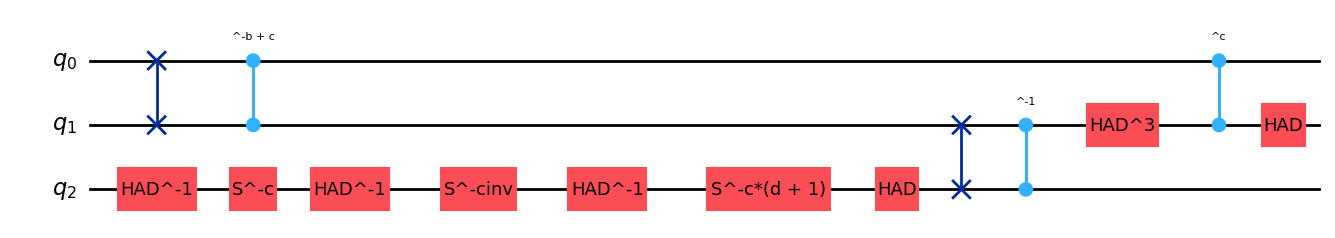

BR65


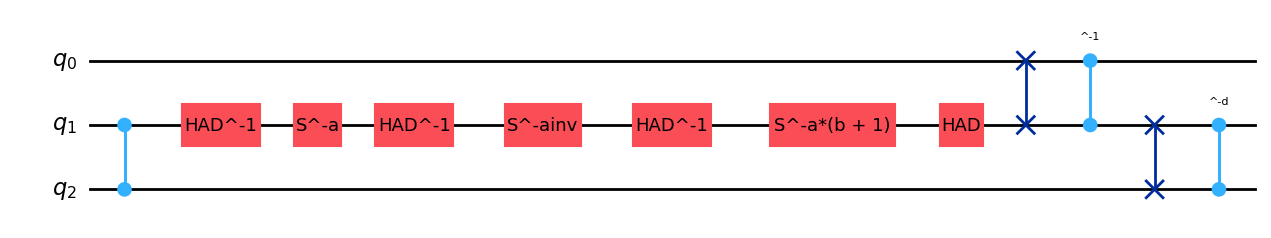

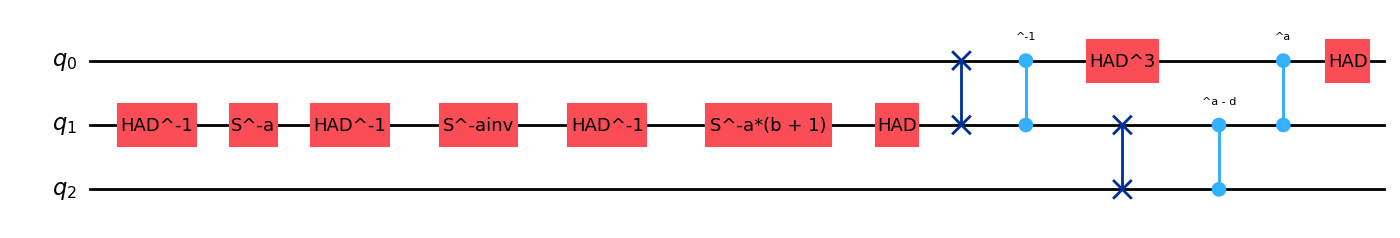

BR66


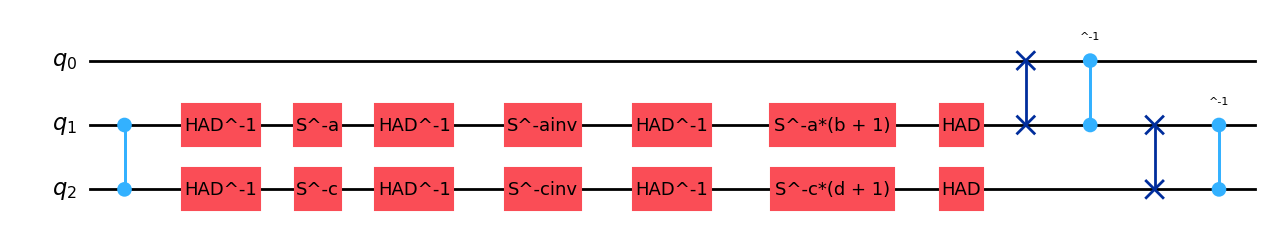

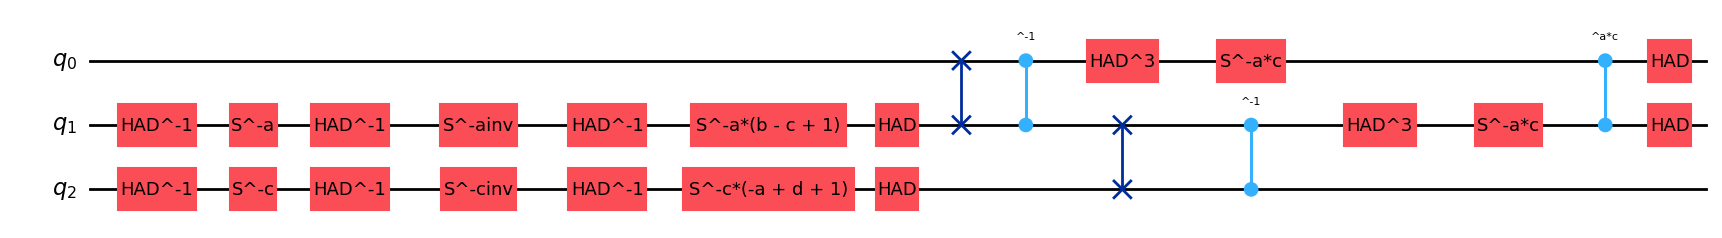

✔ BR63 holds for p = 19
✔ BR64 holds for p = 19
✔ BR65 holds for p = 19
✔ BR66 holds for p = 19

=== Checking BR relations for p = 23 ===
BR63


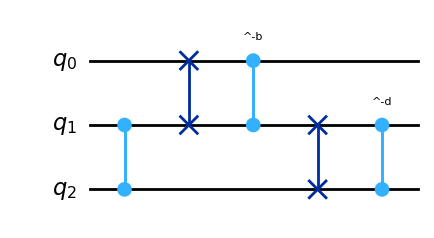

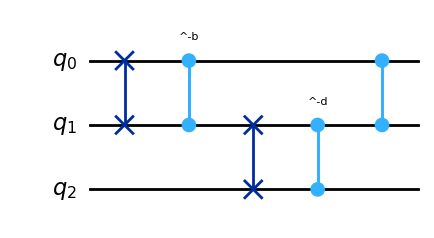

BR64


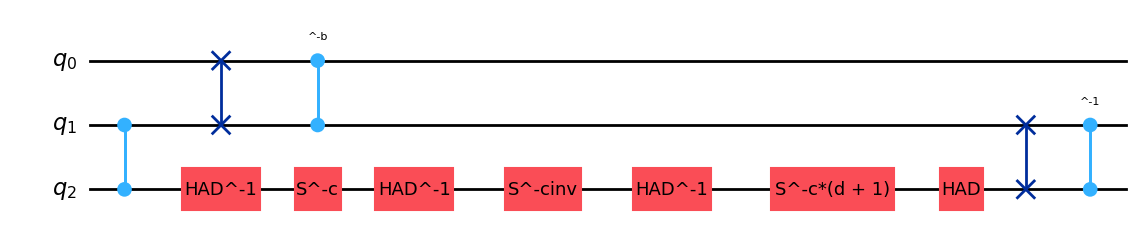

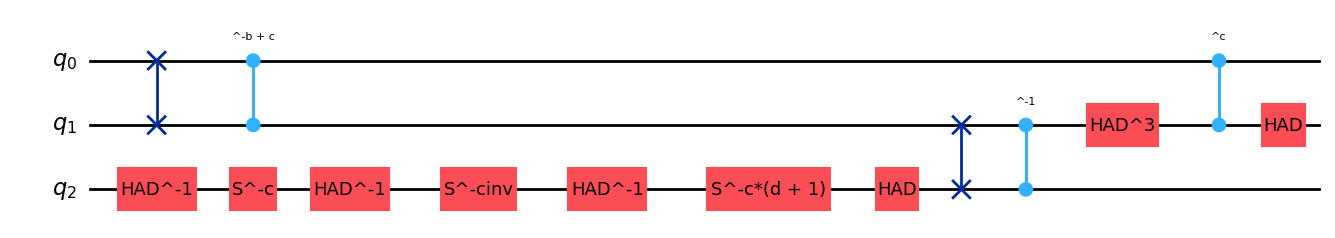

BR65


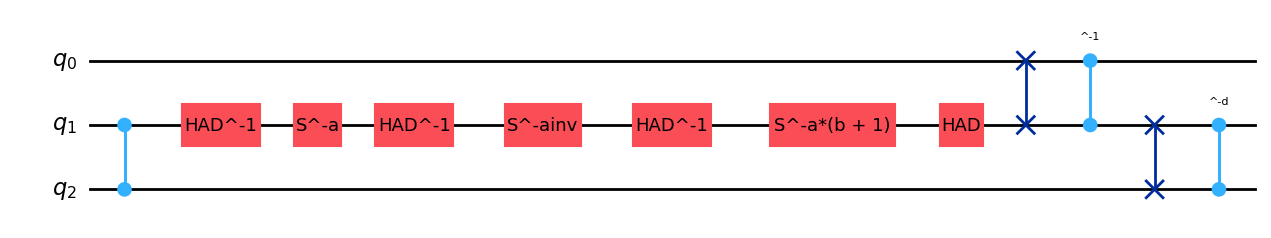

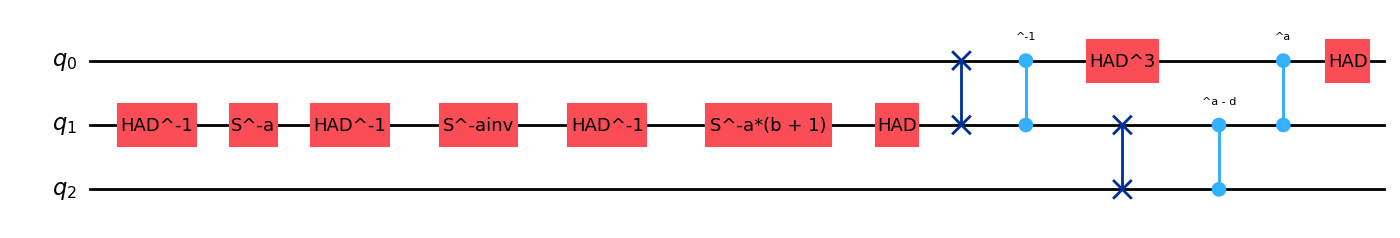

BR66


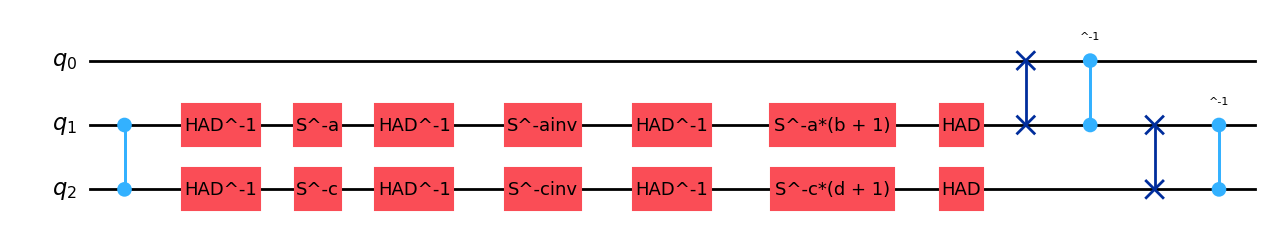

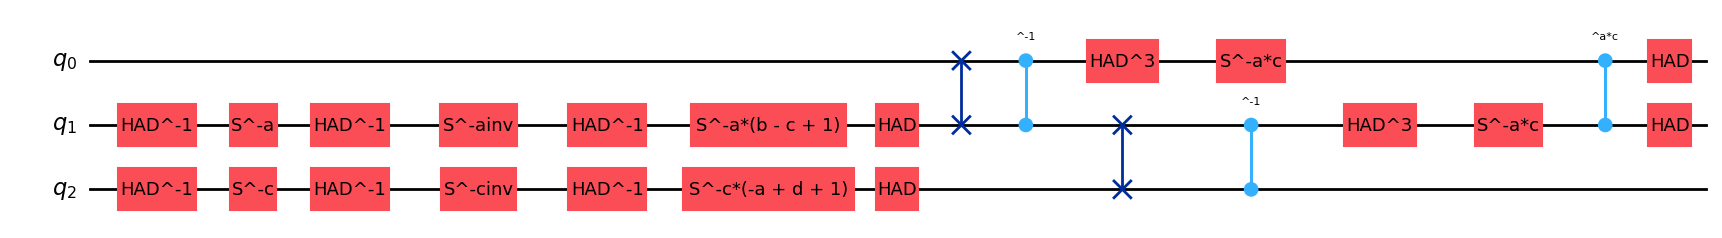

✔ BR63 holds for p = 23
✔ BR64 holds for p = 23
✔ BR65 holds for p = 23
✔ BR66 holds for p = 23

=== All primes processed ===

Saving QASM files to: ./circuits
QASM files generated.


In [16]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

# run_all_BR_relations(primes, save_to_path, params, generate_1q_HS_AE_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_S_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_H_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_SCZ_D_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_A0b_B_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B00_B01_box_relations)
# run_all_BR_relations(primes, save_to_path, params, generate_2q_CZ_Aab_B0d_Bcd_box_relations)
run_all_BR_relations(primes, save_to_path, params, generate_3q_CZ_DD_box_relations)


# The confirmed codes stopped here

In [135]:
S = dizx.gates.S(0)
H = dizx.gates.HAD(0)

# Verify the symplectic version of single-qupit relations in Figure 1

In what follows, We use AB to denote two gates A and B composed in diagrammatic order.

- $C_2$: $H^4 \;\underset{}{\widehat{=}}\; I$.
- $C_3$: $S^p \;\underset{}{\widehat{=}}\; I$.
- $C_4$: $SHSHSH \;\underset{}{\widehat{=}}\; I$.
- $C_5$: $H^2SH^2S^{p-1} \;\underset{}{\widehat{=}}\; I$.

In [136]:
# from sympy import symbols
primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    C2lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C2rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C2lhs += H ** 4
    if dizx.symplectic.compare_matrices(C2lhs.to_symplectic_matrix(), C2rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C2 fails")

    C3lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C3rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C3lhs += S ** p
    if dizx.symplectic.compare_matrices(C3lhs.to_symplectic_matrix(), C3rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C3 fails")

    C4lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C4rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C4lhs += S + H + S + H + S + H
    if dizx.symplectic.compare_matrices(C4lhs.to_symplectic_matrix(), C4rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C4 fails")

    C5lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C5rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C5lhs += H ** 2 + S + H ** 2 + S ** (p-1)
    if dizx.symplectic.compare_matrices(C5lhs.to_symplectic_matrix(), C5rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C5 fails")

# Output the symplectic matrices
# print("p=", p)
# display(C2lhs.draw())
# print(C2lhs.to_symplectic_matrix())
# display(C3lhs.draw())
# print(C3lhs.to_symplectic_matrix())
# display(C4lhs.draw()) 
# print(C4lhs.to_symplectic_matrix())   
# display(C5lhs.draw()) 
# print(C5lhs.to_symplectic_matrix())
# print(C2lhs.to_qasm())


# Output the qasm file
save_to_path = '/Users/sarahli/Desktop/PhD-Projects/2025/QupitClifford-Verification/circuits'
name_of_file = 'C2-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC2:
    fC2.write(C2lhs.to_qasm())

name_of_file = 'C3-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC3:
    fC3.write(C3lhs.to_qasm())

name_of_file = 'C4-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC4:
    fC4.write(C4lhs.to_qasm())

name_of_file = 'C5-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC5:
    fC5.write(C5lhs.to_qasm())

# Verify the action of A boxes on the Pauli generators
- $A_{0b}$, $b \in \mathbb{Z}_p^*$
- $A_{ab}$, $a \in \mathbb{Z}_p^*$, $b \in \mathbb{Z}_p$

# Verify the action of B boxes on the Pauli generators
- $B_{00}$,
- $B_{01}$,
- $B_{ab}$, $(a,b) \in \mathbb{Z}_p \times \mathbb{Z}_p \setminus\{(0,0),(0,1)\}$

In [202]:
from dizx.circuit.gates import SWAP, CZ, HAD, S
import dizx

def instantiate_B_box(a, b, j, k, n, p):
    """
    Instantiate a B(a,b) box acting on qudits j and k inside an n-qudit circuit.

    Updated specification:
        B00 = SWAP(j,k)
        B01 = SWAP(j,k) + CZ(k,j)
        Bab = Aab(on qudit j) + B01(j,k), valid only for (a,b) != (0,0) and (a,b) != (0,1)
    """

    # ---- Index validation ----
    for idx, name in [(j, "j"), (k, "k")]:
        if not isinstance(idx, int):
            raise TypeError(f"Target index {name} must be an integer, not {type(idx)}.")

        if idx < 0 or idx >= n:
            raise ValueError(
                f"Target qudit index {name}={idx} is out of range for n={n}. "
                f"Valid indices are 0 to {n-1}."
            )

    # ---- Create empty circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ----------------------------------------------------------------------
    # Case 1: B00 = SWAP
    # ----------------------------------------------------------------------
    if a == 0 and b == 0:
        circ += SWAP(j, k)
        return circ

    # ----------------------------------------------------------------------
    # Case 2: B01 = SWAP + XC
    # ----------------------------------------------------------------------
    if a == 0 and b == 1:
        circ += SWAP(j, k)
        circ += CX(k,j)
        return circ

    # ----------------------------------------------------------------------
    # Case 3: General Bab = Aab(on first qudit) + B01
    # Allowed *only when (a,b) != (0,0) and (a,b) != (0,1)
    # ----------------------------------------------------------------------

    # Instantiate Aab on the FIRST qudit j
    Aab_j = instantiate_A_box(a, b, j, n, p)
    circ += Aab_j

    # Add B01
    circ += SWAP(j, k)
    circ += CX(k,j)

    return circ


## Verify the three-qupit B box relations:
$BR_{61} \& BR_{62}: CZ. B_{ab}$, $a,b\in \mathbb{Z}_p$

In [228]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

def generate_3q_CZ_B_box_relations(p):
    """
    Generate all D-boxes and BR61–BR62 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR63", "BR64", "BR65", "BR66"]
    """

    # --- Define symbolic parameters ---
    a, b = symbols("a b")

    # --- Precompute B-boxes used in the BR relations ---
    B00_01 = instantiate_B_box(0, 0, j=0, k=1, n=3, p=p)
    B01_01 = instantiate_B_box(0, 1, j=0, k=1, n=3, p=p)
    Bab_01 = instantiate_B_box(a, b, j=0, k=1, n=3, p=p)

    # --- Build BR relations ---

    # BR61
    BR61lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR61rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR61lhs += CZ(1,2) + B00_01
    BR61rhs += B00_01 + (
        HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + CZ(0,1)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
    )
    # display(BR61lhs.draw())
    # display(BR61rhs.draw())

     # BR62
    BR62lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62lhs += CZ(1,2) + Bab_01
    BR62rhs += Bab_01 + (
        HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + CZ(0,1)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2)
    )
    # display(BR62lhs.draw())
    # display(BR62rhs.draw())

    # BR62-2
    BR62_2lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62_2rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR62_2lhs += CZ(1,2) + B01_01
    BR62_2rhs += B01_01 + (
        HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + CZ(0,1)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2) + CZ(1,2)
        + HAD(1) + HAD(2)
    )
    # display(BR62_2lhs.draw())
    # display(BR62_2rhs.draw())


    # Put all circuits in order
    lhs_list = [BR61lhs, BR62lhs, BR62_2lhs]
    rhs_list = [BR61rhs, BR62rhs, BR62_2rhs]

    relation_names = ["BR61", "BR62", "BR62-2"]

    return lhs_list, rhs_list, relation_names


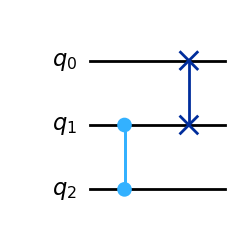

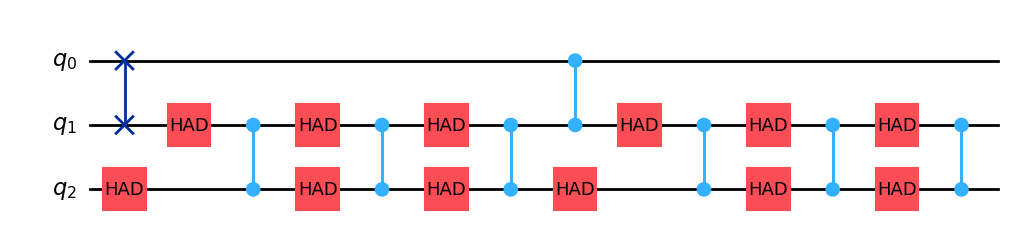

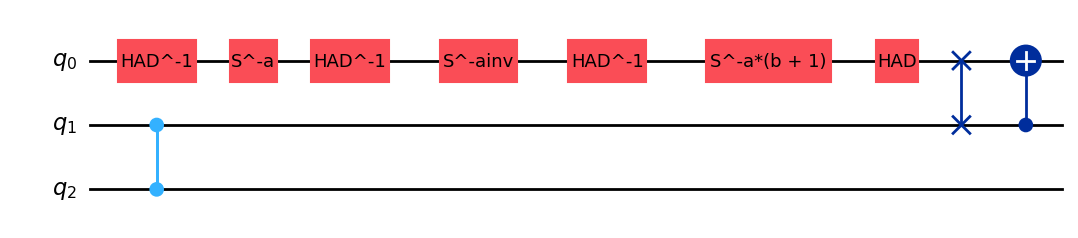

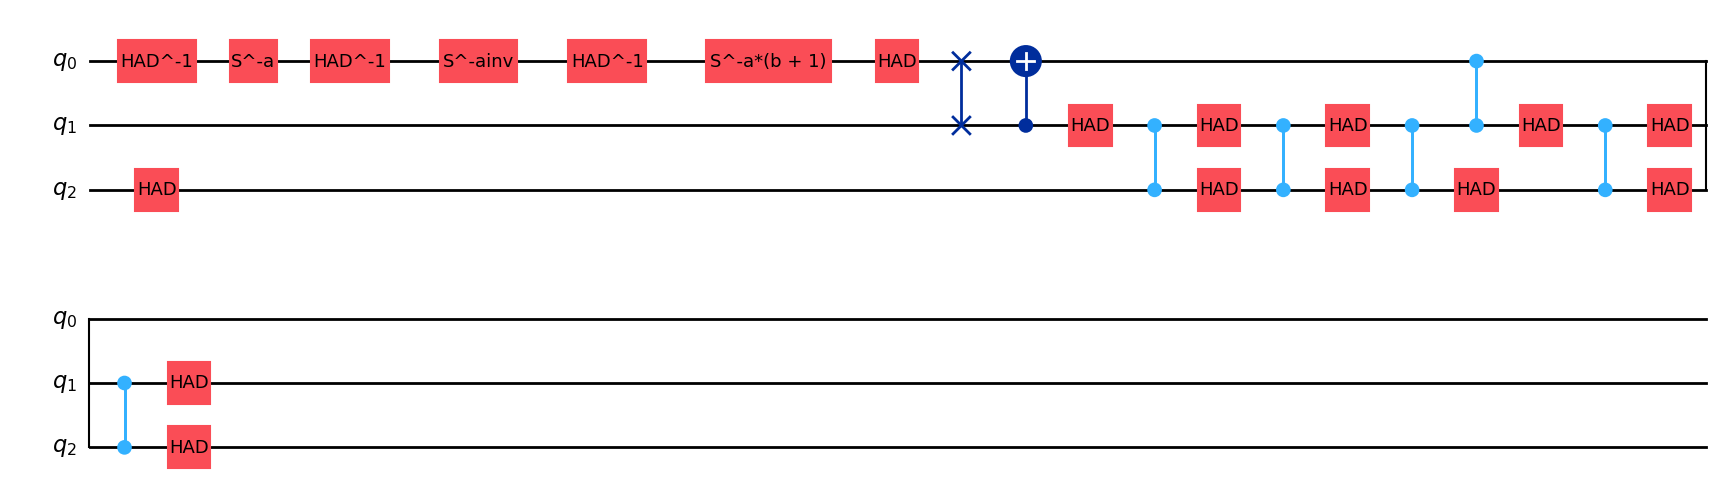

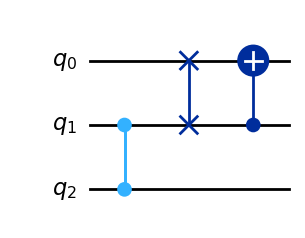

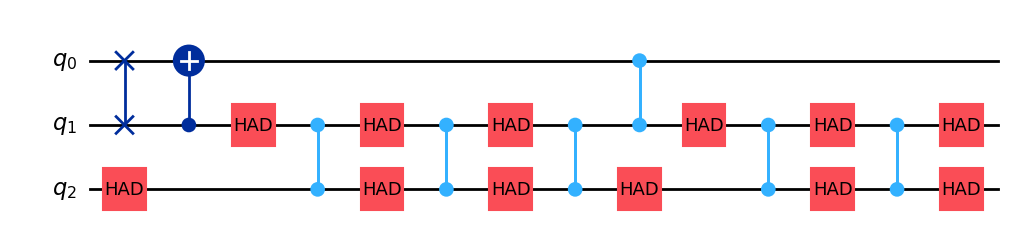

([Circuit[23](3 qudits, 0 dits, [CZ(1,2), SWAP(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0), SWAP(0,1), CX(1,0)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), SWAP(0,1), CX(1,0)] gates)],
 [Circuit[23](3 qudits, 0 dits, [SWAP(0,1), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), CZ(0,1), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2)] gates),
  Circuit[23](3 qudits, 0 dits, [HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0), SWAP(0,1), CX(1,0), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), CZ(0,1), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2)] gates),
  Circuit[23](3 qudits, 0 dits, [SWAP(0,1), CX(1,0), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), CZ(0,1), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2), CZ(1,2), HAD(1), HAD(2)] gates)],
 ['BR6

In [225]:
generate_3q_CZ_B_box_relations(23)

In [231]:
import os

def run_all_BR_relations(primes, save_to_path, relation_generator):
    """
    For each prime p:
        1. Generate BR63–BR66 relations
        2. Compare LHS/RHS using compare_matrices3
        3. Save QASM outputs for each relation

    Requirements:
        - generate_D_box_relations(p)
        - compare_matrices3(lhs_mat, rhs_mat, modulus=p)
        - directory save_to_path must exist
    """

    # Ensure output directory exists
    if not os.path.isdir(save_to_path):
        os.makedirs(save_to_path)

    for p in primes:
        print(f"\n=== Checking BR relations for p = {p} ===")

        # Generate the relations for this p
        lhs_list, rhs_list, relation_names = relation_generator(p)

        for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

            # Compute symplectic matrices
            lhs_mat = lhs.to_symplectic_matrix()
            rhs_mat = rhs.to_symplectic_matrix()

            # Compare using your function
            ok = compare_matrices3(lhs_mat, rhs_mat, modulus=p)

            # Print failures
            if not ok:
                print(f"❌ {name} fails for p = {p}")
            else:
                print(f"✔ {name} holds for p = {p}")
    print("\n=== All primes processed ===")

     # --- Save QASM files ONCE (from final p) ---
    print(f"\nSaving QASM files to: {save_to_path}")

    for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

        lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
        rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

        with open(lhs_filename, "w+") as f:
            f.write(lhs.to_qasm())

        with open(rhs_filename, "w+") as f:
            f.write(rhs.to_qasm())

    print("QASM files generated.")

In [232]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

run_all_BR_relations(primes, save_to_path, generate_3q_CZ_B_box_relations)


=== Checking BR relations for p = 3 ===
✔ BR61 holds for p = 3
✔ BR62 holds for p = 3
✔ BR62-2 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR61 holds for p = 5
✔ BR62 holds for p = 5
✔ BR62-2 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR61 holds for p = 7
✔ BR62 holds for p = 7
✔ BR62-2 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR61 holds for p = 11
✔ BR62 holds for p = 11
✔ BR62-2 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR61 holds for p = 13
✔ BR62 holds for p = 13
✔ BR62-2 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR61 holds for p = 19
✔ BR62 holds for p = 19
✔ BR62-2 holds for p = 19

=== Checking BR relations for p = 23 ===
✔ BR61 holds for p = 23
✔ BR62 holds for p = 23
✔ BR62-2 holds for p = 23

=== All primes processed ===

Saving QASM files to: ./circuits
QASM files generated.


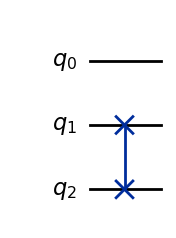

Matrix([
[1, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 1],
[0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0]])

In [207]:
a = symbols("a")
b = symbols("b")
# B00 on (0,1)
B00_12 = instantiate_B_box(0, 0, j=1, k=2, n=3, p=23)
display(B00_12.draw())
B00_12_reduce = dizx.symplectic.reduce_matrix(B00_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
B00_12_reduce

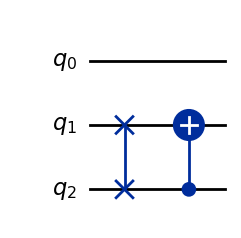

Matrix([
[1, 0, 0, 0, 0,  0],
[0, 1, 0, 0, 0,  0],
[0, 0, 1, 0, 1,  0],
[0, 0, 0, 0, 0,  1],
[0, 0, 1, 0, 0,  0],
[0, 0, 0, 1, 0, -1]])

In [208]:
# B01 on (0,1)
B01_12 = instantiate_B_box(0, 1, j=1, k=2, n=3, p=23)
display(B01_12.draw())
B01_12_reduce = dizx.symplectic.reduce_matrix(B01_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
B01_12_reduce

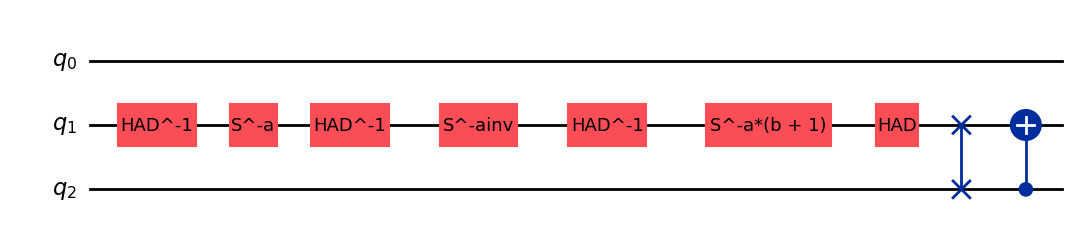

Matrix([
[1, 0,    0,  0, 0,  0],
[0, 1,    0,  0, 0,  0],
[0, 0,    b, -a, 1,  0],
[0, 0,    0,  0, 0,  1],
[0, 0,    b, -a, 0,  0],
[0, 0, ainv,  0, 0, -1]])

In [209]:
# Bab (general case) on (0,1)
Bab_12 = instantiate_B_box(a, b, j=1, k=2, n=3, p=23)
display(Bab_12.draw())
Bab_12_reduce = dizx.symplectic.reduce_matrix(Bab_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Bab_12_reduce

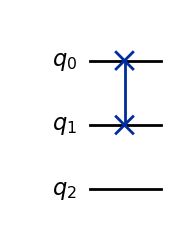

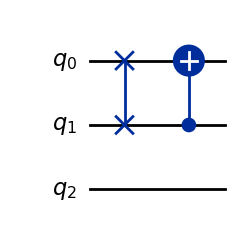

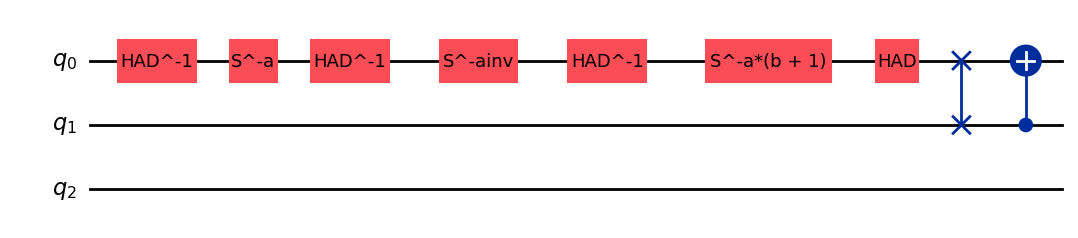

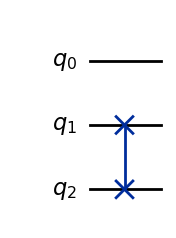

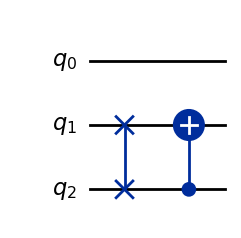

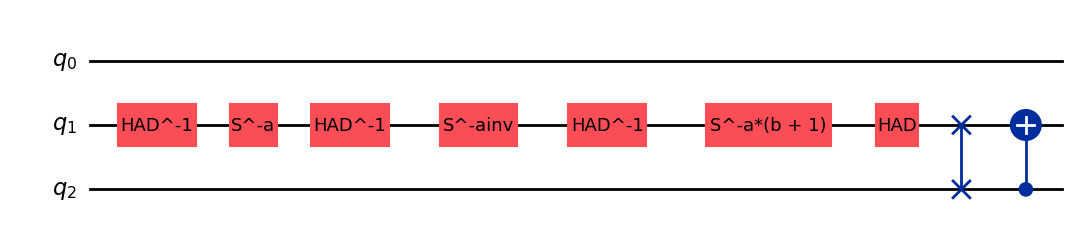

In [203]:





# B00 on (1,2)
B00_12 = instantiate_B_box(0, 0, j=1, k=2, n=3, p=23)
display(B00_12.draw())

# B01 on (1,2)
B01_12 = instantiate_B_box(0, 1, j=1, k=2, n=3, p=23)
display(B01_12.draw())

# Bab (general case) on (1,2)
Bab_12 = instantiate_B_box(a, b, j=1, k=2, n=3, p=23)
display(Bab_12.draw())




# lhs = dizx.Circuit(qudit_amount=3, dim=3)
# lhs += CZ(1,2) + D01_01 + D01_12
# display(lhs.draw())

# Verify the action of D boxes on the Pauli generators
- $D_{00}$,
- $D_{0b}$,
- $D_{ab}$.

In [148]:
from dizx.circuit.gates import SWAP, CZ, HAD, S
import dizx

def instantiate_D_box(a, b, j, k, n, p):
    """
    Instantiate a D(a,b) box acting on qudits j and k inside an n-qudit circuit.

    Updated specification:
        D00 = SWAP(j,k)
        D0b = SWAP(j,k) + CZ(j,k)**(-b)
        Dab = Aab(on qudit k) + D01(j,k), valid only for a != 0
    """

    # ---- Index validation ----
    for idx, name in [(j, "j"), (k, "k")]:
        if not isinstance(idx, int):
            raise TypeError(f"Target index {name} must be an integer, not {type(idx)}.")

        if idx < 0 or idx >= n:
            raise ValueError(
                f"Target qudit index {name}={idx} is out of range for n={n}. "
                f"Valid indices are 0 to {n-1}."
            )

    # ---- Create empty circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ----------------------------------------------------------------------
    # Case 1: D00 = SWAP
    # ----------------------------------------------------------------------
    if a == 0 and b == 0:
        circ += SWAP(j, k)
        return circ

    # ----------------------------------------------------------------------
    # Case 2: D0b = SWAP + CZ**(-b)  (for ANY b)
    # ----------------------------------------------------------------------
    if a == 0:
        circ += SWAP(j, k)
        circ += CZ(j, k)**(-b)
        return circ

    # ----------------------------------------------------------------------
    # Case 3: General Dab = Aab(on second qudit) + D01
    # Allowed *only when a != 0*
    # ----------------------------------------------------------------------

    # Instantiate Aab on the SECOND qudit k
    Aab_k = instantiate_A_box(a, b, k, n, p)
    circ += Aab_k

    # Add D01
    circ += SWAP(j, k)
    circ += CZ(j, k)**(-1)   # this is b = 1 in D01

    return circ


In [199]:
import os

def run_all_BR_relations(primes, save_to_path):
    """
    For each prime p:
        1. Generate BR63–BR66 relations
        2. Compare LHS/RHS using compare_matrices3
        3. Save QASM outputs for each relation

    Requirements:
        - generate_D_box_relations(p)
        - compare_matrices3(lhs_mat, rhs_mat, modulus=p)
        - directory save_to_path must exist
    """

    # Ensure output directory exists
    if not os.path.isdir(save_to_path):
        os.makedirs(save_to_path)

    for p in primes:
        print(f"\n=== Checking BR relations for p = {p} ===")

        # Generate the relations for this p
        lhs_list, rhs_list, relation_names = generate_3q_D_box_relations(p)

        for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

            # Compute symplectic matrices
            lhs_mat = lhs.to_symplectic_matrix()
            rhs_mat = rhs.to_symplectic_matrix()

            # Compare using your function
            ok = compare_matrices3(lhs_mat, rhs_mat, modulus=p)

            # Print failures
            if not ok:
                print(f"❌ {name} fails for p = {p}")
            else:
                print(f"✔ {name} holds for p = {p}")
    print("\n=== All primes processed ===")

     # --- Save QASM files ONCE (from final p) ---
    print(f"\nSaving QASM files to: {save_to_path}")

    for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

        lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
        rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

        with open(lhs_filename, "w+") as f:
            f.write(lhs.to_qasm())

        with open(rhs_filename, "w+") as f:
            f.write(rhs.to_qasm())

    print("QASM files generated.")

## Verify the three-qupit D box relations:
$BR_{63} \sim BR_{66}: CZ. B_{ab}. B_{cd}$, $a,b,c,d\in \mathbb{Z}_p$

In [ ]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S

def generate_3q_D_box_relations(p):
    """
    Generate all D-boxes and BR63–BR66 relations for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["BR63", "BR64", "BR65", "BR66"]
    """

    # --- Define symbolic parameters ---
    a, b, c, d = symbols("a b c d")

    # --- Precompute D-boxes used in the BR relations ---
    D0b_01 = instantiate_D_box(0, b, j=0, k=1, n=3, p=23)
    D0d_12 = instantiate_D_box(0, d, j=1, k=2, n=3, p=23)

    Dcd_12 = instantiate_D_box(c, d, j=1, k=2, n=3, p=23)
    D0bminusc_01 = instantiate_D_box(0, b-c, j=0, k=1, n=3, p=23)

    Dab_01 = instantiate_D_box(a, b, j=0, k=1, n=3, p=23)
    D0dminusa_12 = instantiate_D_box(0, d-a, j=1, k=2, n=3, p=23)

    Dcd_12 = instantiate_D_box(c, d, j=1, k=2, n=3, p=23)
    Dabminusc_01 = instantiate_D_box(a, b-c, j=0, k=1, n=3, p=23)
    Dcdminusa_12 = instantiate_D_box(c, d-a, j=1, k=2, n=3, p=23)   

    # --- Build BR relations ---

    # BR63
    BR63lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR63rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR63lhs += CZ(1,2) + D0b_01 + D0d_12
    BR63rhs += D0b_01 + D0d_12 + CZ(0,1)
    # print("BR63")
    # display(BR63lhs.draw())
    # display(BR63rhs.draw())

    # BR64
    BR64lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR64rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR64lhs += CZ(1,2) + D0b_01 + Dcd_12
    BR64rhs += D0bminusc_01 + Dcd_12 + HAD(1)**3 + CZ(0,1) ** c + HAD(1)
    # print("BR64")
    # display(BR64lhs.draw())
    # display(BR64rhs.draw())

    # BR65
    BR65lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR65rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR65lhs += CZ(1,2) + Dab_01 + D0d_12
    BR65rhs += Dab_01 + D0dminusa_12 + HAD(0)**3 + CZ(0,1) ** a + HAD(0)
    # print("BR65")
    # display(BR65lhs.draw())
    # display(BR65rhs.draw())

    # BR66
    BR66lhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR66rhs = dizx.Circuit(qudit_amount=3, dim=p)
    BR66lhs += CZ(1,2) + Dab_01 + Dcd_12
    BR66rhs += (Dabminusc_01 + Dcdminusa_12 
            + HAD(0)**3 
            + HAD(1)**3 
            + S(0)**(-a * c) 
            + S(1)**(-a * c) 
            + CZ(0,1) ** (a*c) 
            + HAD(0) 
            + HAD(1))
    # print("BR66")
    # display(BR66lhs.draw())
    # display(BR66rhs.draw())


    # Put all circuits in order
    lhs_list = [BR63lhs, BR64lhs, BR65lhs, BR66lhs]
    rhs_list = [BR63rhs, BR64rhs, BR65rhs, BR66rhs]

    relation_names = ["BR63", "BR64", "BR65", "BR66"]

    return lhs_list, rhs_list, relation_names


BR63


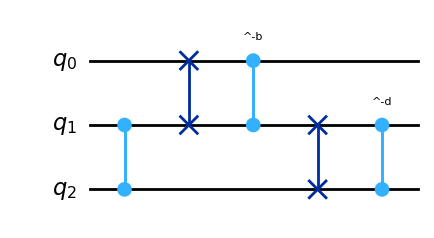

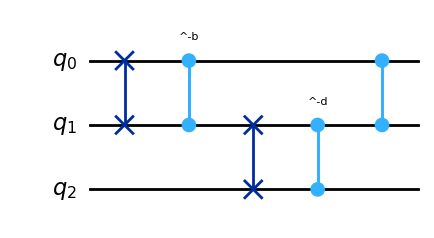

BR64


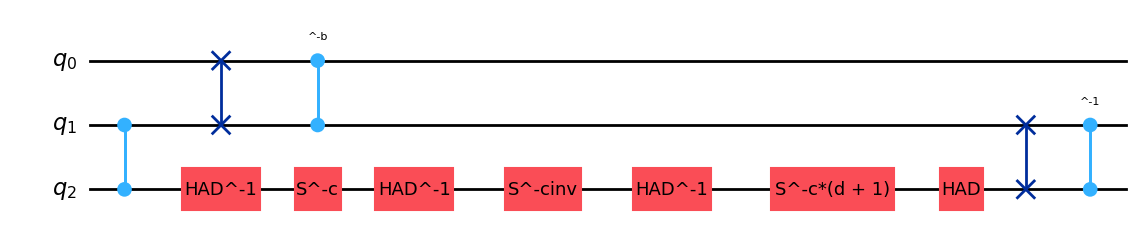

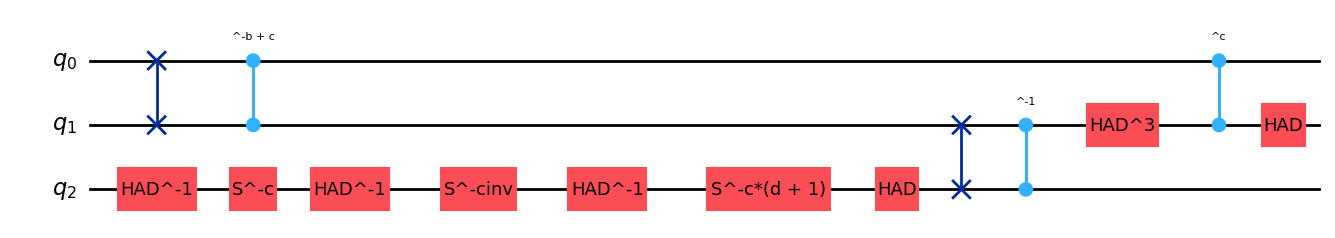

BR65


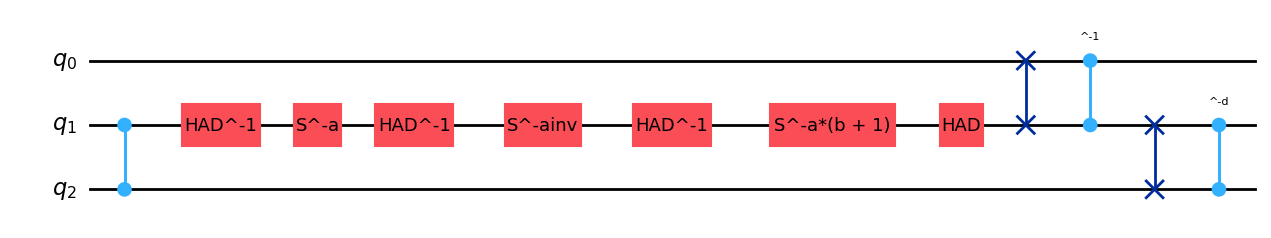

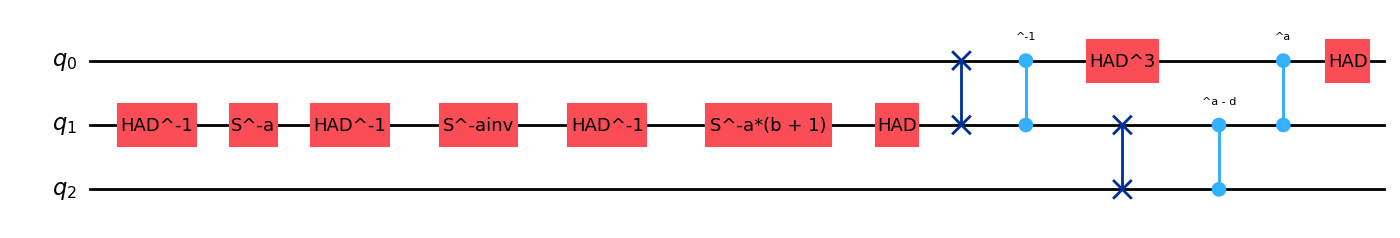

BR66


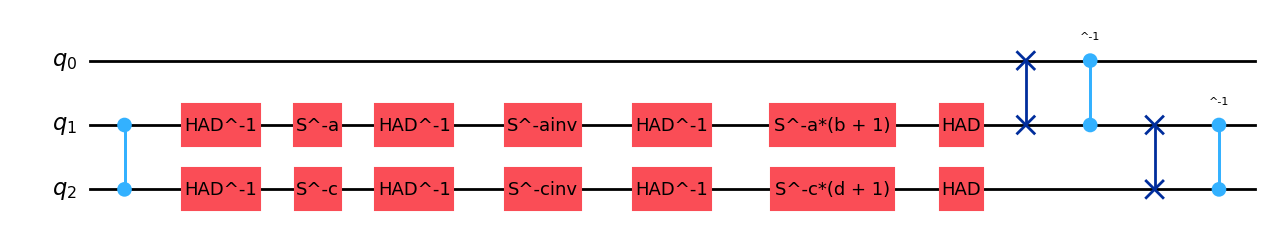

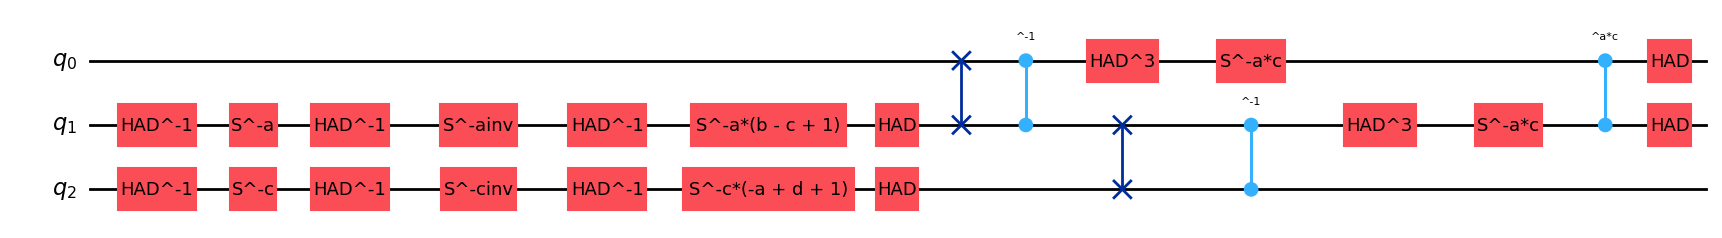

([Circuit[23](3 qudits, 0 dits, [CZ(1,2), SWAP(0,1), CZ^-b(0,1), SWAP(1,2), CZ^-d(1,2)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), SWAP(0,1), CZ^-b(0,1), HAD^-1(2), S^-c(2), HAD^-1(2), S^-cinv(2), HAD^-1(2), S^-c*(d + 1)(2), HAD(2), SWAP(1,2), CZ^-1(1,2)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(0,1), CZ^-1(0,1), SWAP(1,2), CZ^-d(1,2)] gates),
  Circuit[23](3 qudits, 0 dits, [CZ(1,2), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), SWAP(0,1), CZ^-1(0,1), HAD^-1(2), S^-c(2), HAD^-1(2), S^-cinv(2), HAD^-1(2), S^-c*(d + 1)(2), HAD(2), SWAP(1,2), CZ^-1(1,2)] gates)],
 [Circuit[23](3 qudits, 0 dits, [SWAP(0,1), CZ^-b(0,1), SWAP(1,2), CZ^-d(1,2), CZ(0,1)] gates),
  Circuit[23](3 qudits, 0 dits, [SWAP(0,1), CZ^-b + c(0,1), HAD^-1(2), S^-c(2), HAD^-1(2), S^-cinv(2), HAD^-1(2), S^-c*(d + 1)(2), HAD(2), SWAP(1,2), CZ^-1(1,2), HAD^3(1), CZ^c(0,1), HAD(1)] gates),
  Ci

In [191]:
generate_3q_D_box_relations(23)

In [200]:
primes = [3, 5, 7, 11, 13, 19, 23]
save_to_path = "./circuits"

run_all_BR_relations(primes, save_to_path)


=== Checking BR relations for p = 3 ===
✔ BR63 holds for p = 3
✔ BR64 holds for p = 3
✔ BR65 holds for p = 3
✔ BR66 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ BR63 holds for p = 5
✔ BR64 holds for p = 5
✔ BR65 holds for p = 5
✔ BR66 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ BR63 holds for p = 7
✔ BR64 holds for p = 7
✔ BR65 holds for p = 7
✔ BR66 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ BR63 holds for p = 11
✔ BR64 holds for p = 11
✔ BR65 holds for p = 11
✔ BR66 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ BR63 holds for p = 13
✔ BR64 holds for p = 13
✔ BR65 holds for p = 13
✔ BR66 holds for p = 13

=== Checking BR relations for p = 19 ===
✔ BR63 holds for p = 19
✔ BR64 holds for p = 19
✔ BR65 holds for p = 19
✔ BR66 holds for p = 19

=== Checking BR relations for p = 23 ===
✔ BR63 holds for p = 23
✔ BR64 holds for p = 23
✔ BR65 holds for p = 23
✔ BR66 holds for p = 23

=== All primes processed ===

Saving QASM files 

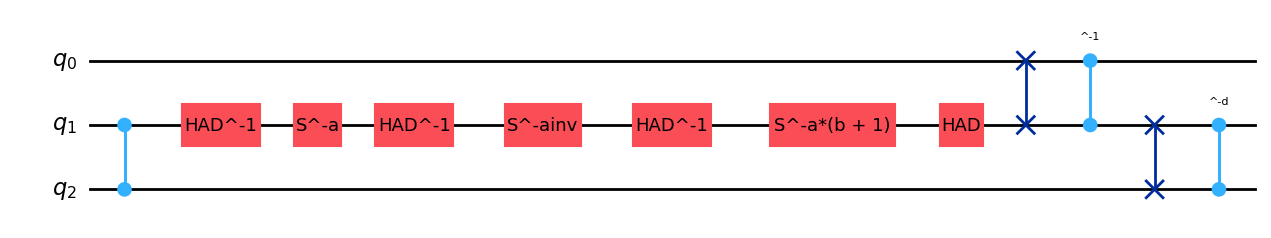

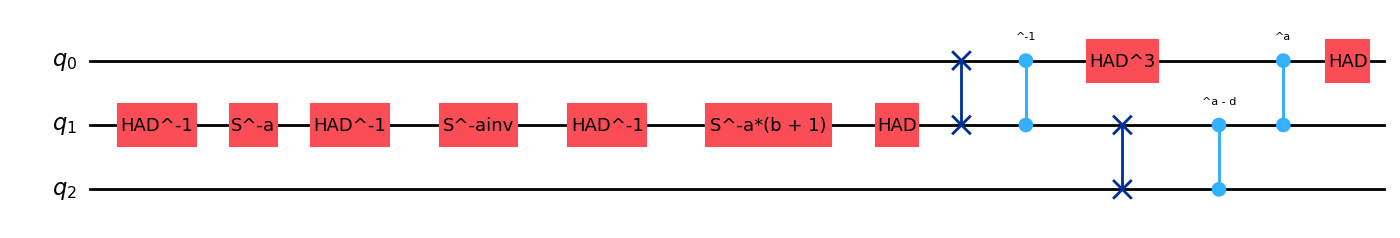

In [181]:
from dizx.circuit.gates import CZ, CX, HAD, S#, Z, X


a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")

D0b_01 = instantiate_D_box(0, b, j=0, k=1, n=3, p=23)
D0d_12 = instantiate_D_box(0, d, j=1, k=2, n=3, p=23)

Dcd_12 = instantiate_D_box(c, d, j=1, k=2, n=3, p=23)
D0bminusc_01 = instantiate_D_box(0, b-c, j=0, k=1, n=3, p=23)

Dab_01 = instantiate_D_box(a, b, j=0, k=1, n=3, p=23)
D0dminusa_12 = instantiate_D_box(0, d-a, j=1, k=2, n=3, p=23)

Dcd_12 = instantiate_D_box(c, d, j=1, k=2, n=3, p=23)
Dabminusc_01 = instantiate_D_box(a, b-c, j=0, k=1, n=3, p=23)
Dcdminusa_12 = instantiate_D_box(c, d-a, j=1, k=2, n=3, p=23)

BR63lhs = dizx.Circuit(qudit_amount=3, dim=p)
BR63rhs = dizx.Circuit(qudit_amount=3, dim=p)
BR63lhs += CZ(1,2) + D0b_01 + D0d_12
BR63rhs += D0b_01 + D0d_12 + CZ(0,1)

BR64lhs = dizx.Circuit(qudit_amount=3, dim=p)
BR64rhs = dizx.Circuit(qudit_amount=3, dim=p)
BR64lhs += CZ(1,2) + D0b_01 + Dcd_12
BR64rhs += D0bminusc_01 + Dcd_12 + HAD(1)**3 + CZ(0,1) ** c + HAD(1)

BR65lhs = dizx.Circuit(qudit_amount=3, dim=p)
BR65rhs = dizx.Circuit(qudit_amount=3, dim=p)
BR65lhs += CZ(1,2) + Dab_01 + D0d_12
BR65rhs += Dab_01 + D0dminusa_12 + HAD(0)**3 + CZ(0,1) ** a + HAD(0)
display(BR65lhs.draw())
display(BR65rhs.draw())

BR66lhs = dizx.Circuit(qudit_amount=3, dim=p)
BR66rhs = dizx.Circuit(qudit_amount=3, dim=p)
BR66lhs += CZ(1,2) + Dab_01 + Dcd_12
BR66rhs += Dabminusc_01 + Dcdminusa_12 + HAD(0)**3 + HAD(1)**3 + S(0)**(-a * c) + S(1)**(-a * c) + CZ(0,1) ** (a*c) + HAD(0) + HAD(1)

# Put all circuits into lists in order ---
lhs_list = [BR63lhs, BR64lhs, BR65lhs, BR66lhs]
rhs_list = [BR63rhs, BR64rhs, BR65rhs, BR66rhs]

# Give each pair a readable name (same order!)
relation_names = ["BR63", "BR64", "BR65", "BR66"]

In [164]:
import os
primes = [3, 5, 7, 11, 13, 19, 23]

for p in primes:
    # Loop through all relations
    for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):
        # Compute symplectic matrices
        lhs_mat = lhs.to_symplectic_matrix()
        rhs_mat = rhs.to_symplectic_matrix()

        # Compare using your function
        ok = compare_matrices3(lhs_mat, rhs_mat, modulus=p)
        # dizx.symplectic.compare_matrices3(lhs_mat, rhs_mat, modulus=p)

        if not ok:
            print(f"{name} fails.")

        # --- 3. Save LHS and RHS QASM files ---
        lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
        rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

        with open(lhs_filename, "w+") as f:
            f.write(lhs.to_qasm())

        with open(rhs_filename, "w+") as f:
            f.write(rhs.to_qasm())

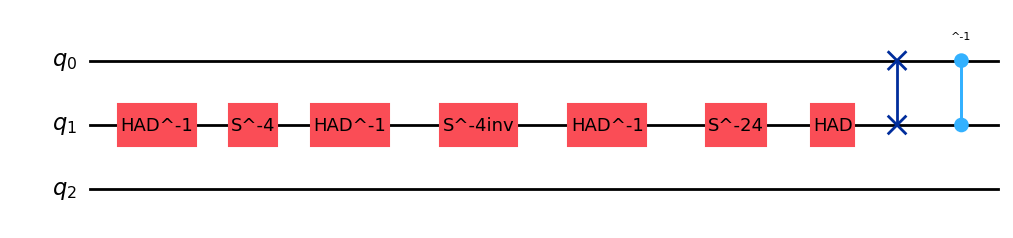

Matrix([
[ 0, 0, 24*4inv - 1, 96*4inv - 28, 0, 0],
[-1, 0,        4inv,   4*4inv - 1, 0, 0],
[ 1, 0,           0,            0, 0, 0],
[ 0, 1, 1 - 24*4inv, 28 - 96*4inv, 0, 0],
[ 0, 0,           0,            0, 1, 0],
[ 0, 0,           0,            0, 0, 1]])

In [81]:
a = symbols("a")
b = symbols("b")
D45_01 = instantiate_D_box(4, 5, j=0, k=1, n=3, p=23)
display(D45_01.draw())
D45_01.to_symplectic_matrix()

# D45_01_reduce = dizx.symplectic.reduce_matrix(D45_01.to_symplectic_matrix(),[(Integer(4), Symbol("4inv")), (Integer(5), Symbol("5inv"))])


# D45_12 = instantiate_D_box(4, 5, j=1, k=2, n=3, p=23)
# display(D45_12.draw())

# D45_12_reduce = dizx.symplectic.reduce_matrix(D45_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])

# D45_01_reduce
# D45_12_reduce

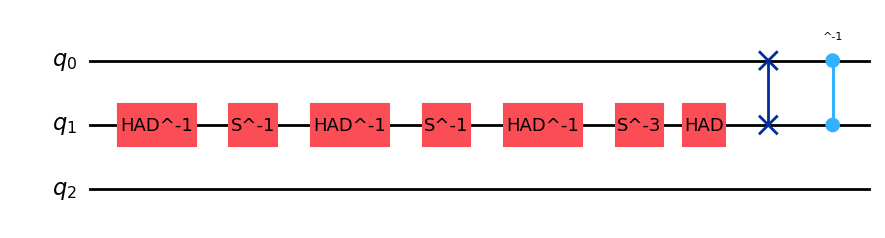

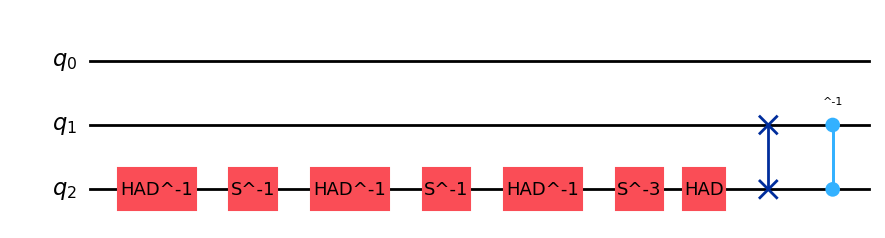

Matrix([
[1, 0,  0, 0,  0,  0],
[0, 1,  0, 0,  0,  0],
[0, 0,  0, 0,  2, -1],
[0, 0, -1, 0,  1,  0],
[0, 0,  1, 0,  0,  0],
[0, 0,  0, 1, -2,  1]])

In [77]:
a = symbols("a")
b = symbols("b")
D12_01 = instantiate_D_box(1, 2, j=0, k=1, n=3, p=23)
display(D12_01.draw())

D12_01_reduce = dizx.symplectic.reduce_matrix(D12_01.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])


D12_12 = instantiate_D_box(1, 2, j=1, k=2, n=3, p=23)
display(D12_12.draw())

D12_12_reduce = dizx.symplectic.reduce_matrix(D12_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])

D12_01_reduce
D12_12_reduce

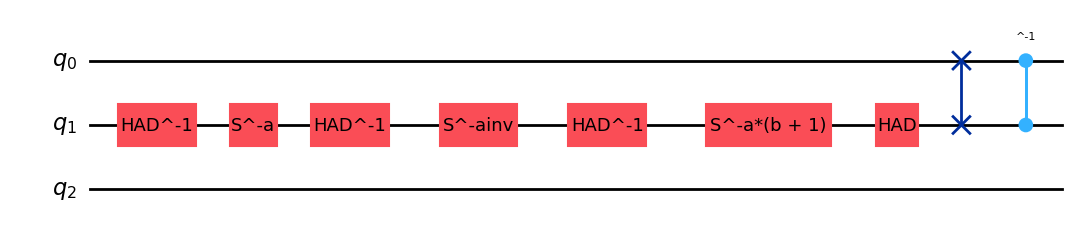

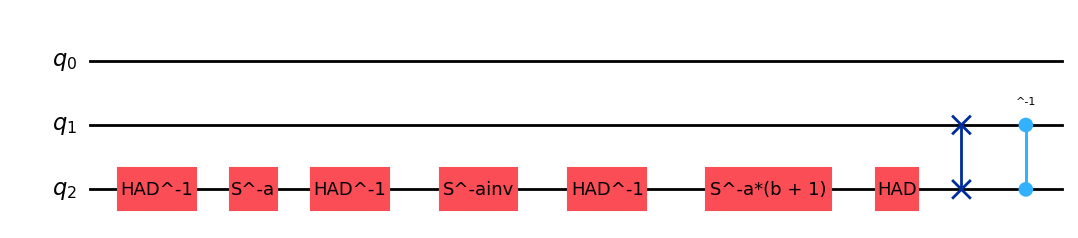

Matrix([
[1, 0,  0, 0,    0,  0],
[0, 1,  0, 0,    0,  0],
[0, 0,  0, 0,    b, -a],
[0, 0, -1, 0, ainv,  0],
[0, 0,  1, 0,    0,  0],
[0, 0,  0, 1,   -b,  a]])

In [36]:
a = symbols("a")
b = symbols("b")
Dab_01 = instantiate_D_box(a, b, j=0, k=1, n=3, p=23)
display(Dab_01.draw())

Dab_01_reduce = dizx.symplectic.reduce_matrix(Dab_01.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])


Dab_12 = instantiate_D_box(a, b, j=1, k=2, n=3, p=23)
display(Dab_12.draw())

Dab_12_reduce = dizx.symplectic.reduce_matrix(Dab_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])

Dab_01_reduce
Dab_12_reduce

# modulo_matrix(D023_01_reduce, 23)

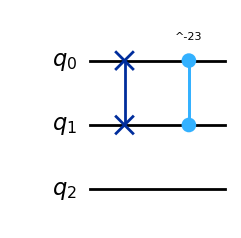

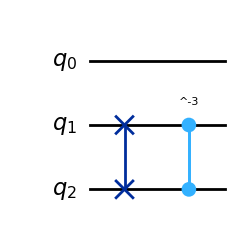

Matrix([
[0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0],
[1, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 1]])

In [34]:
a = symbols("a")
b = symbols("b")
D023_01 = instantiate_D_box(0, 23, j=0, k=1, n=3, p=23)
display(D023_01.draw())

D023_01_reduce = dizx.symplectic.reduce_matrix(D023_01.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])


D03_12 = instantiate_D_box(0, 3, j=1, k=2, n=3, p=23)
display(D03_12.draw())

D03_12_reduce = dizx.symplectic.reduce_matrix(D03_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])


D03_12_reduce
D023_01_reduce
modulo_matrix(D023_01_reduce, 23)

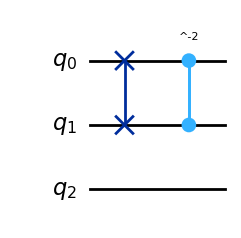

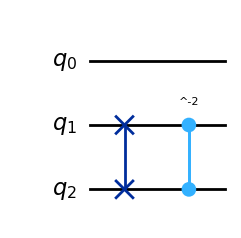

Matrix([
[ 0, 0,  1, 0, 0, 0],
[-2, 0,  0, 1, 0, 0],
[ 1, 0,  0, 0, 0, 0],
[ 0, 1, -2, 0, 0, 0],
[ 0, 0,  0, 0, 1, 0],
[ 0, 0,  0, 0, 0, 1]])

In [29]:
a = symbols("a")
b = symbols("b")
D02_01 = instantiate_D_box(0, 2, j=0, k=1, n=3, p=23)
display(D02_01.draw())

D02_01_reduce = dizx.symplectic.reduce_matrix(D02_01.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
D02_01_reduce

D02_12 = instantiate_D_box(0, 2, j=1, k=2, n=3, p=23)
display(D02_12.draw())

D02_12_reduce = dizx.symplectic.reduce_matrix(D02_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])


D02_12_reduce
D02_01_reduce

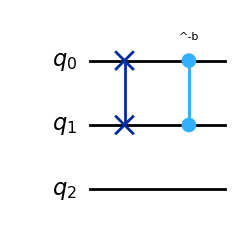

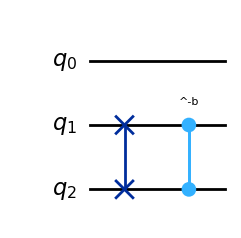

Matrix([
[1, 0,  0, 0,  0, 0],
[0, 1,  0, 0,  0, 0],
[0, 0,  0, 0,  1, 0],
[0, 0, -b, 0,  0, 1],
[0, 0,  1, 0,  0, 0],
[0, 0,  0, 1, -b, 0]])

In [27]:
a = symbols("a")
b = symbols("b")
D0b_01 = instantiate_D_box(0, b, j=0, k=1, n=3, p=23)
display(D0b_01.draw())

D0b_01_reduce = dizx.symplectic.reduce_matrix(D0b_01.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
D0b_01_reduce

D0b_12 = instantiate_D_box(0, b, j=1, k=2, n=3, p=23)
display(D0b_12.draw())

D0b_12_reduce = dizx.symplectic.reduce_matrix(D0b_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])

D0b_01_reduce
D0b_12_reduce

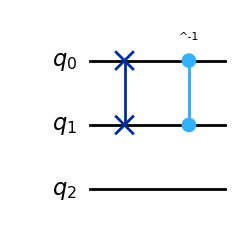

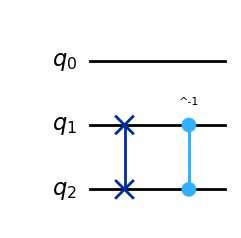

Matrix([
[ 0, 0,  1, 0, 0, 0],
[-1, 0,  0, 1, 0, 0],
[ 1, 0,  0, 0, 0, 0],
[ 0, 1, -1, 0, 0, 0],
[ 0, 0,  0, 0, 1, 0],
[ 0, 0,  0, 0, 0, 1]])

In [25]:
a = symbols("a")
b = symbols("b")
D01_01 = instantiate_D_box(0, 1, j=0, k=1, n=3, p=23)
display(D01_01.draw())

D01_01_reduce = dizx.symplectic.reduce_matrix(D01_01.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
D01_01_reduce

D01_12 = instantiate_D_box(0, 1, j=1, k=2, n=3, p=23)
display(D01_12.draw())

D01_12_reduce = dizx.symplectic.reduce_matrix(D01_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
D01_12_reduce
D01_01_reduce


# for i in range(10):
#     D01_jk = instantiate_D_box(0, 1, j=i, k=i+1, n=11, p=23)
#     D01_jk_reduce = dizx.symplectic.reduce_matrix(D01_jk.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     D01_jk_reduce
#     display(D01_jk.draw())
# D01_jk_reduce

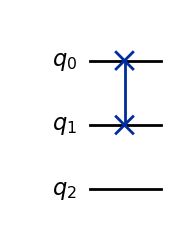

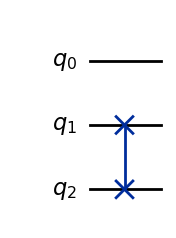

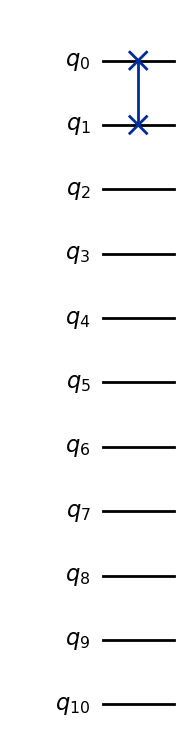

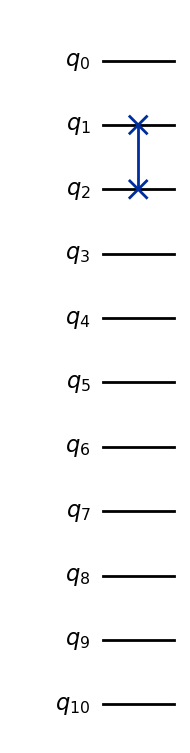

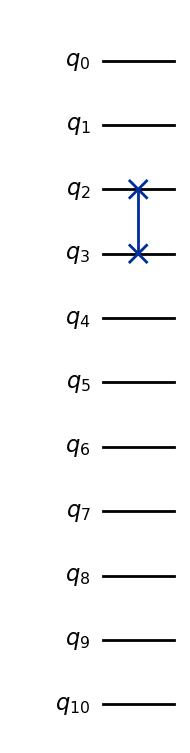

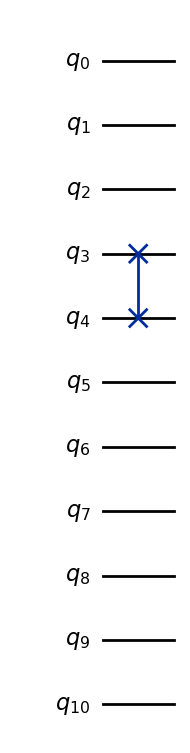

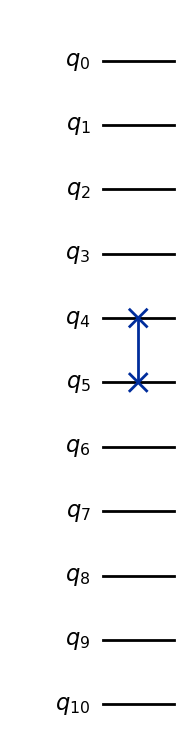

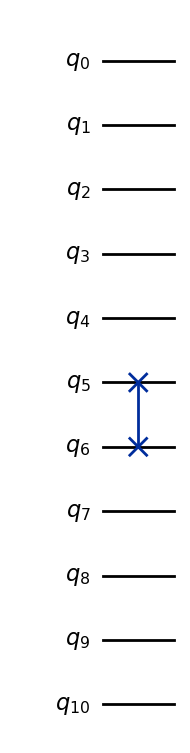

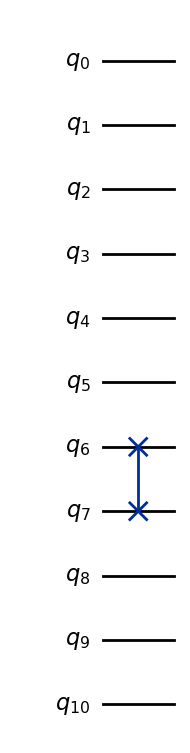

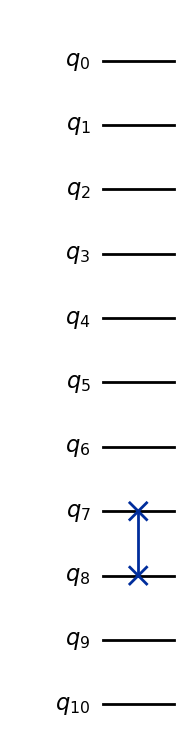

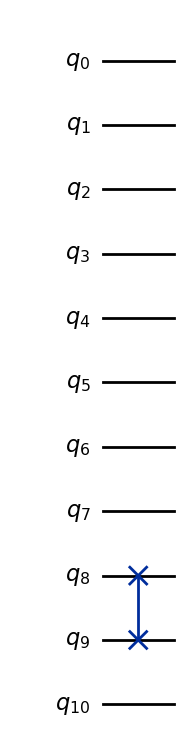

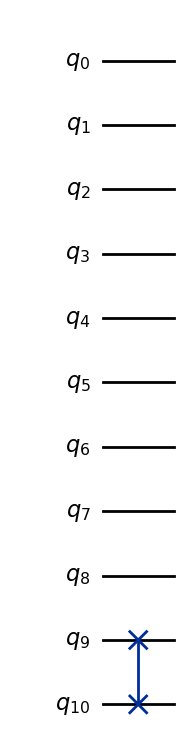

Matrix([
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [20]:
a = symbols("a")
b = symbols("b")
D00_01 = instantiate_D_box(0, 0, j=0, k=1, n=3, p=23)
display(D00_01.draw())

D00_01_reduce = dizx.symplectic.reduce_matrix(D00_01.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
D00_01_reduce

D00_12 = instantiate_D_box(0, 0, j=1, k=2, n=3, p=23)
display(D00_12.draw())

D00_12_reduce = dizx.symplectic.reduce_matrix(D00_12.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
D00_12_reduce


for i in range(10):
    D00_jk = instantiate_D_box(0, 0, j=i, k=i+1, n=11, p=23)
    D00_jk_reduce = dizx.symplectic.reduce_matrix(D00_jk.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
    D00_jk_reduce
    display(D00_jk.draw())
D00_jk_reduce

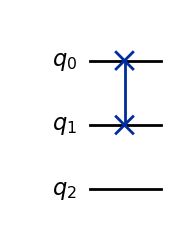

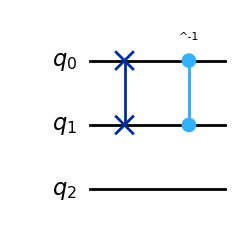

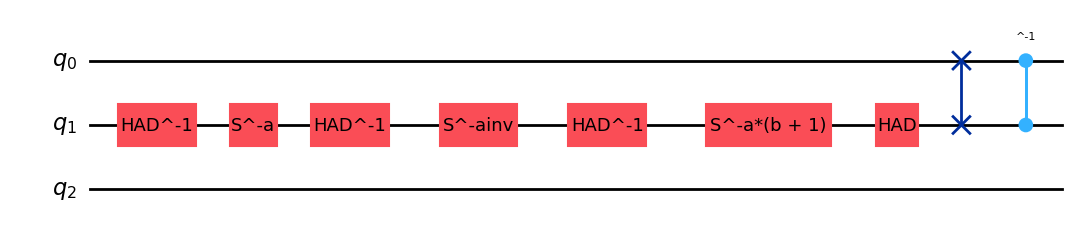

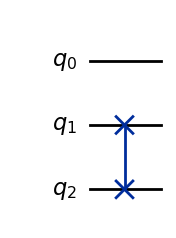

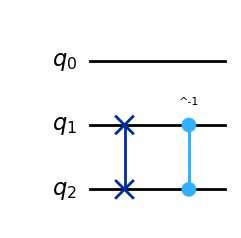

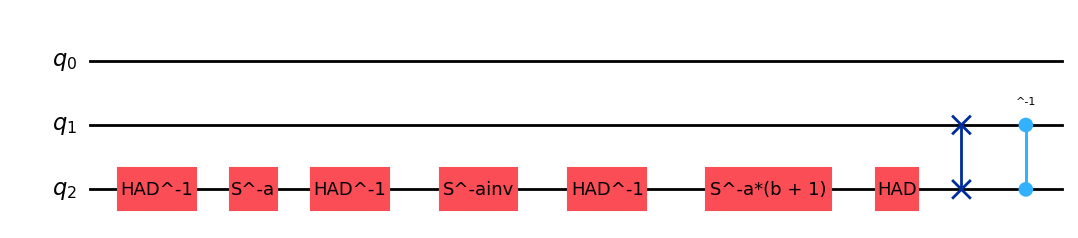

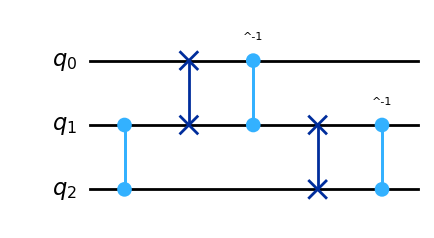

In [46]:
# D00 on (0,1)
D00_01 = instantiate_D_box(0, 0, j=0, k=1, n=3, p=23)
display(D00_01.draw())

# D01 on (0,1)
D01_01 = instantiate_D_box(0, 1, j=0, k=1, n=3, p=23)
display(D01_01.draw())

# Dab (general case) on (0,1)
Dab_01 = instantiate_D_box(a, b, j=0, k=1, n=3, p=23)
display(Dab_01.draw())

# D00 on (1,2)
D00_12 = instantiate_D_box(0, 0, j=1, k=2, n=3, p=23)
display(D00_12.draw())

# D01 on (1,2)
D01_12 = instantiate_D_box(0, 1, j=1, k=2, n=3, p=23)
display(D01_12.draw())

# Dab (general case) on (1,2)
Dab_12 = instantiate_D_box(a, b, j=1, k=2, n=3, p=23)
display(Dab_12.draw())




lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CZ(1,2) + D01_01 + D01_12
display(lhs.draw())

In [29]:
a = symbols("a")
b = symbols("b")
A0b_0 = instantiate_A_box(0, b, 0, 3, 23)
A0b_0_reduce = dizx.symplectic.reduce_matrix(A0b_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0b_0_reduce

# for i in range(10):
#     A0b_1 = instantiate_A_box(0, b, i, 10, 23)
#     A0b_1_reduce = dizx.symplectic.reduce_matrix(A0b_1.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     A0b_1_reduce
#     display(A0b_1.draw())


Matrix([
[ b,    0, 0, 0, 0, 0],
[-1, binv, 0, 0, 0, 0],
[ 0,    0, 1, 0, 0, 0],
[ 0,    0, 0, 1, 0, 0],
[ 0,    0, 0, 0, 1, 0],
[ 0,    0, 0, 0, 0, 1]])

In [30]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
A0d_0 = instantiate_A_box(0, d, 0, 3, 23)
A0d_0_reduce = dizx.symplectic.reduce_matrix(A0d_0.to_symplectic_matrix(),[(d,symbolic_inverse(d))])
A0d_0_reduce

# for i in range(10):
#     A0d_i = instantiate_A_box(0, d, i, 10, 23)
#     A0d_i_reduce = dizx.symplectic.reduce_matrix(A0d_i.to_symplectic_matrix(),[(d,symbolic_inverse(d))])
#     A0d_i_reduce
#     display(A0d_i.draw())
# A0d_i_reduce

Matrix([
[ d,    0, 0, 0, 0, 0],
[-1, dinv, 0, 0, 0, 0],
[ 0,    0, 1, 0, 0, 0],
[ 0,    0, 0, 1, 0, 0],
[ 0,    0, 0, 0, 1, 0],
[ 0,    0, 0, 0, 0, 1]])

In [31]:
a = symbols("a")
b = symbols("b")
Ab0_0 = instantiate_A_box(b, 0, 0, 3, 23)
Ab0_0_reduce = dizx.symplectic.reduce_matrix(Ab0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab0_0_reduce

# for i in range(10):
#     Ab0_0 = instantiate_A_box(b, 0, i, 10, 23)
#     Ab0_0_reduce = dizx.symplectic.reduce_matrix(Ab0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     Ab0_0_reduce
#     display(Ab0_0.draw())
# Ab0_0_reduce

Matrix([
[   0, -b, 0, 0, 0, 0],
[binv,  0, 0, 0, 0, 0],
[   0,  0, 1, 0, 0, 0],
[   0,  0, 0, 1, 0, 0],
[   0,  0, 0, 0, 1, 0],
[   0,  0, 0, 0, 0, 1]])

In [33]:
a = symbols("a")
b = symbols("b")
Aa0_0 = instantiate_A_box(a, 0, 0, 1, 23)
Aa0_0_reduce = dizx.symplectic.reduce_matrix(Aa0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa0_0_reduce

# for i in range(10):
#     Aa0_0 = instantiate_A_box(a, 0, i, 10, 23)
#     Aa0_0_reduce = dizx.symplectic.reduce_matrix(Aa0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     Aa0_0_reduce
#     display(Aa0_0.draw())

# Aa0_0_reduce

Matrix([
[   0, -a],
[ainv,  0]])

In [34]:
a = symbols("a")
b = symbols("b")
A0_neg_a = instantiate_A_box(0, -a, 0, 1, 23)
A0_neg_a_reduce = dizx.symplectic.reduce_matrix(A0_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0_neg_a_reduce

# for i in range(10):
#     A0_neg_a = instantiate_A_box(0, -a, i, 10, 23)
#     A0_neg_a_reduce = dizx.symplectic.reduce_matrix(A0_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(A0_neg_a.draw())

# A0_neg_a_reduce

Matrix([
[-a,     0],
[-1, -ainv]])

In [35]:
a = symbols("a")
b = symbols("b")
Ab_neg_a = instantiate_A_box(b, -a, 0, 1, 23)
Ab_neg_a_reduce = dizx.symplectic.reduce_matrix(Ab_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab_neg_a_reduce

# for i in range(10):
#     Ab_neg_a = instantiate_A_box(b, -a, i, 10, 23)
#     Ab_neg_a_reduce = dizx.symplectic.reduce_matrix(Ab_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Ab_neg_a.draw())

# Ab_neg_a_reduce

Matrix([
[  -a, -b],
[binv,  0]])

In [51]:
a = symbols("a")
b = symbols("b")
Aa_bminusa = instantiate_A_box(a, b-a, 0, 1, 23)
Aa_bminusa_reduce = dizx.symplectic.reduce_matrix(Aa_bminusa.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa_bminusa_reduce

# for i in range(10):
#     Aa_bminusa = instantiate_A_box(a, b-a, i, 10, 23)
#     Aa_bminusa_reduce = dizx.symplectic.reduce_matrix(Aa_bminusa.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Aa_bminusa.draw())

# Aa_bminusa_reduce

Matrix([
[-a + b, -a],
[  ainv,  0]])

In [52]:
a = symbols("a")
b = symbols("b")
Aab = instantiate_A_box(a, b, 0, 1, 23)
Aab_reduce = dizx.symplectic.reduce_matrix(Aab.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aab_reduce

# for i in range(10):
#     Aab = instantiate_A_box(a, b, i, 10, 23)
#     Aab_reduce = dizx.symplectic.reduce_matrix(Aab.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Aab.draw())

# Aab_reduce

Matrix([
[   b, -a],
[ainv,  0]])

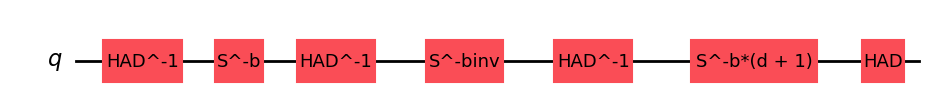

Matrix([
[   d, -b],
[binv,  0]])

In [53]:
b = symbols("b")
d = symbols("d")
Abd = instantiate_A_box(b, d, 0, 1, 23)
Abd_reduce = dizx.symplectic.reduce_matrix(Abd.to_symplectic_matrix(),[(b,symbolic_inverse(b)),(d,symbolic_inverse(d))])
display(Abd.draw())
Abd_reduce

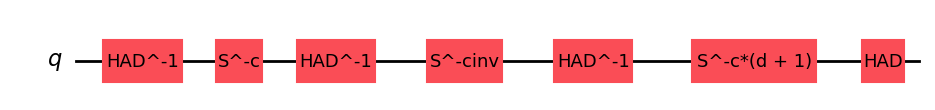

Matrix([
[   d, -c],
[cinv,  0]])

In [54]:
c = symbols("c")
d = symbols("d")
Acd = instantiate_A_box(c, d, 0, 1, 23)
Acd_reduce = dizx.symplectic.reduce_matrix(Acd.to_symplectic_matrix(),[(c,symbolic_inverse(c)),(d,symbolic_inverse(d))])
display(Acd.draw())
Acd_reduce

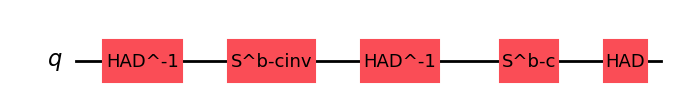

In [55]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
bminusc = symbols("b-c")
A0_bminusc = instantiate_A_box(0, bminusc, 0, 1, 23)
A0_bminusc_reduce = dizx.symplectic.reduce_matrix(A0_bminusc.to_symplectic_matrix(),[(bminusc,symbolic_inverse(bminusc))])
A0_bminusc_reduce
display(A0_bminusc.draw())

In [56]:
b = symbols("b")
c = symbols("c")
bminusc = symbols("b-c")
m = dizx.Circuit(qudit_amount=1, dim=23)
m += HAD(0)**-1 + S(0)**(symbolic_inverse(bminusc)) + HAD(0)**-1 + S(0)**(bminusc) + HAD(0)
m.to_symplectic_matrix()
m_reduce = dizx.symplectic.reduce_matrix(m.to_symplectic_matrix(),[(bminusc,symbolic_inverse(bminusc))])
m_reduce
# m.to_symplectic_matrix()

Matrix([
[b-c,      0],
[ -1, b-cinv]])

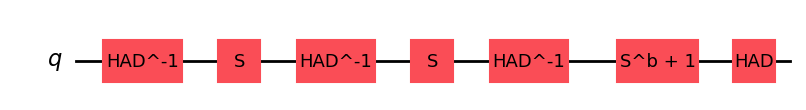

Matrix([
[ b, 1],
[-1, 0]])

In [57]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
t = symbols("t")
Aminus1_b = instantiate_A_box(-1, b, 0, 1, 23)
Aminus1_b_reduce = dizx.symplectic.reduce_matrix(Aminus1_b.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
display(Aminus1_b.draw())
Aminus1_b_reduce

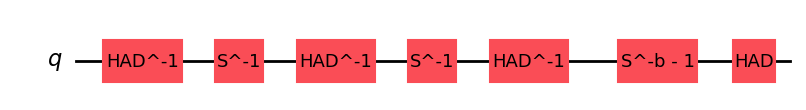

Matrix([
[b, -1],
[1,  0]])

In [58]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
t = symbols("t")
A1b = instantiate_A_box(1, b, 0, 1, 23)
A1b_reduce = dizx.symplectic.reduce_matrix(A1b.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
display(A1b.draw())
A1b_reduce

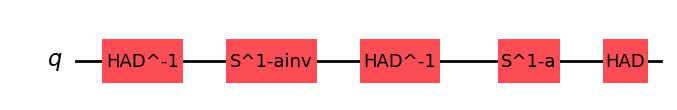

Matrix([
[1-a,      0],
[ -1, 1-ainv]])

In [59]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
oneminusa = symbols("1-a")
A0_1minusa = instantiate_A_box(0, oneminusa, 0, 1, 23)
A0_1minusa_reduce = dizx.symplectic.reduce_matrix(A0_1minusa.to_symplectic_matrix(),[(oneminusa,symbolic_inverse(oneminusa))])
display(A0_1minusa.draw())
A0_1minusa_reduce

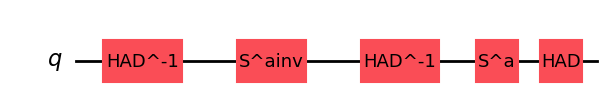

Matrix([
[ a,    0],
[-1, ainv]])

In [60]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
A0a = instantiate_A_box(0, a, 0, 1, 23)
A0a_reduce = dizx.symplectic.reduce_matrix(A0a.to_symplectic_matrix(),[(a,symbolic_inverse(a))])
display(A0a.draw())
A0a_reduce

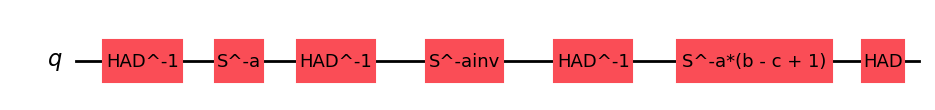

Matrix([
[b - c, -a],
[ ainv,  0]])

In [61]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
Aa_bminusc = instantiate_A_box(a, b-c, 0, 1, 23)
Aa_bminusc_reduce = dizx.symplectic.reduce_matrix(Aa_bminusc.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b)),(c,symbolic_inverse(c))])
display(Aa_bminusc.draw())
Aa_bminusc_reduce

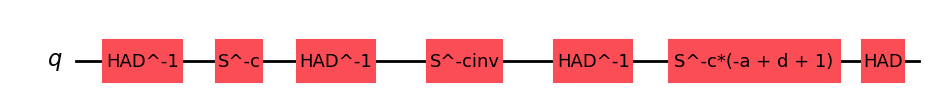

Matrix([
[-a + d, -c],
[  cinv,  0]])

In [62]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
Ac_dminusa = instantiate_A_box(c, d-a, 0, 1, 23)
Ac_dminusa_reduce = dizx.symplectic.reduce_matrix(Ac_dminusa.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(d,symbolic_inverse(d)),(c,symbolic_inverse(c))])
display(Ac_dminusa.draw())
Ac_dminusa_reduce

In [63]:
# Define A and E boxes that appear in the single-qupit box relations
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")

A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H

Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

Ab0 = dizx.Circuit(qudit_amount=1, dim=p)
Ab0 += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b) + H

Aa0 = dizx.Circuit(qudit_amount=1, dim=p)
Aa0 += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a) + H

A0_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
A0_neg_a += H**-1 + S**-ainv + H**-1 + S**-a + H

Ab_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
Ab_neg_a += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b*(-a+1)) + H

Aa_bminusa = dizx.Circuit(qudit_amount=1, dim=p)
Aa_bminusa += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b-a+1)) + H

Eb = dizx.Circuit(qudit_amount=1, dim=p)
Eb += S**(-b)

E_bminus1 = dizx.Circuit(qudit_amount=1, dim=p)
E_bminus1 += S**-(b-1)

NameError: name 'p' is not defined

In [ ]:
A0b_m = A0b.to_symplectic_matrix()
A0b_m_reduce = dizx.symplectic.reduce_matrix(A0b_m,[(a,ainv),(b,binv)])
Aab_m = Aab.to_symplectic_matrix()
Aab_m_reduce = dizx.symplectic.reduce_matrix(Aab_m,[(a,ainv),(b,binv)])

print(A0b_m_reduce)
print(Aab_m_reduce)

name_of_file = 'A0b'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fA0b:
    fA0b.write(A0b.to_qasm())

name_of_file = 'Aab'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fAab:
    fAab.write(Aab.to_qasm())
# print(p)

Matrix([[b, 0], [-1, binv]])
Matrix([[b, -a], [ainv, 0]])


# Verify the action of E boxes on the Pauli generators
- $E_{b}$, $b \in \mathbb{Z}_p$

In [ ]:
def instantiate_E_box(b, j, n, p):
    """
    Returns the E(b) box acting on qudit j inside an n-qudit circuit. Indexing starts from 0.
    """

    # ---- Index validation ----
    if not isinstance(j, int):
        raise TypeError(f"Target index j must be an integer, not {type(j)}.")

    if j < 0 or j >= n:
        raise ValueError(
            f"Target qudit index j={j} is out of range for n={n}. "
            f"Valid indices are 0 to {n-1}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)
    circ += S(j)**(-b)
    return circ


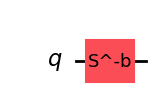

Matrix([
[ 1, 0],
[-b, 1]])

In [ ]:
Eb = instantiate_E_box(b, 0, 1, 23)
Eb_reduce = dizx.symplectic.reduce_matrix(Eb.to_symplectic_matrix(),[(b,symbolic_inverse(b))])
display(Eb.draw())
Eb_reduce

# for i in range(10):
#     Eb = instantiate_E_box(b, i, 10, 23)
#     Eb_reduce = dizx.symplectic.reduce_matrix(Eb.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Eb.draw())

# Eb_reduce

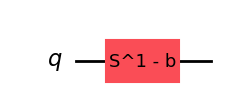

Matrix([
[    1, 0],
[1 - b, 1]])

In [ ]:
E_bminus1 = instantiate_E_box(b-1, 0, 1, 23)
E_bminus1_reduce = dizx.symplectic.reduce_matrix(E_bminus1.to_symplectic_matrix(),[(b,symbolic_inverse(b))])
display(E_bminus1.draw())
E_bminus1_reduce

# for i in range(10):
#     E_bminus1 = instantiate_E_box(b-1, i, 10, 23)
#     E_bminus1_reduce = dizx.symplectic.reduce_matrix(E_bminus1.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(E_bminus1.draw())

# E_bminus1_reduce

# Verify the action of B boxes on the Pauli generators
- $B_{00}$,
- $B_{01}$,
- $B_{ab}$.

In [ ]:
from dizx.circuit.gates import SWAP, CX, HAD, S
import dizx

def instantiate_B_box(a, b, j, k, n, p):
    """
    Instantiate a B(a,b) box acting on qudits j and k inside an n-qudit circuit.
    B-boxes act only on adjacent qudits, i.e., |j - k| = 1.
    """

    # ---- Index validation ----
    for idx, name in [(j, "j"), (k, "k")]:
        if not isinstance(idx, int):
            raise TypeError(f"Target index {name} must be an integer, not {type(idx)}.")

        if idx < 0 or idx >= n:
            raise ValueError(
                f"Target qudit index {name}={idx} is out of range for n={n}. "
                f"Valid indices are 0 to {n-1}."
            )

    # ---- Adjacency validation ----
    if abs(j - k) != 1:
        raise ValueError(
            f"B-box Bab can only act on adjacent qudits, but got j={j}, k={k}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ---- Case B00: just SWAP ----
    if a == 0 and b == 0:
        circ += SWAP(j, k)
        return circ

    # ---- Case B01: SWAP + CX(1,0) ----
    if a == 0 and b == 1:
        circ += SWAP(j, k)
        circ += CX(k, j)
        return circ

    # ---- General case Bab = Aab(j) + B01(j,k) ----

    # Instantiate Aab on qudit j
    Aab_j = instantiate_A_box(a, b, j, n, p)
    circ += Aab_j

    # Add B01(j,k)
    circ += SWAP(j, k)
    circ += CX(k, j)

    return circ


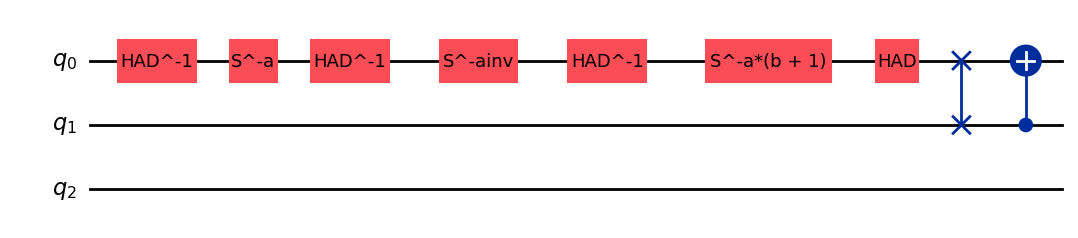

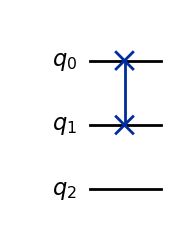

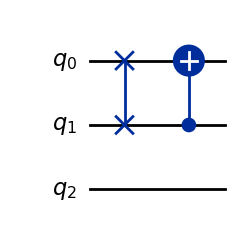

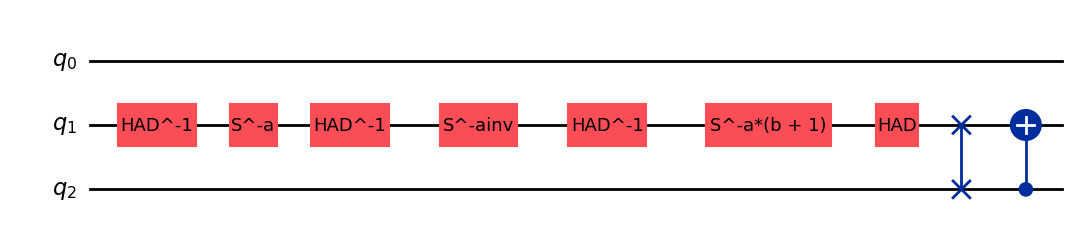

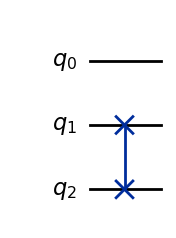

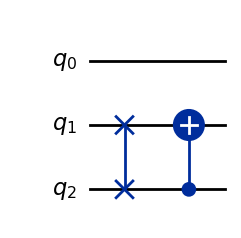

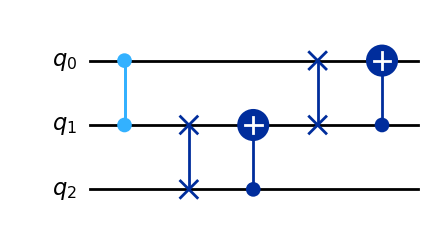

In [ ]:
# Works (adjacent qudits)
Bab_01 = instantiate_B_box(a, b, j=0, k=1, n=3, p=23)
display(Bab_01.draw())

B00_01 = instantiate_B_box(0, 0, j=0, k=1, n=3, p=23)
display(B00_01.draw())

B01_01 = instantiate_B_box(0, 1, j=0, k=1, n=3, p=23)
display(B01_01.draw())

Bab_12 = instantiate_B_box(a, b, j=1, k=2, n=3, p=23)
display(Bab_12.draw())

B00_12 = instantiate_B_box(0, 0, j=1, k=2, n=3, p=23)
display(B00_12.draw())

B01_12 = instantiate_B_box(0, 1, j=1, k=2, n=3, p=23)
display(B01_12.draw())
# Error: not adjacent
# Bab = instantiate_B_box(a, b, j=1, k=4, n=7, p=23)
# ValueError: B-box Bab can only act on adjacent qudits

lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CZ(0,1) + B01_12 + B01_01
display(lhs.draw())


In [ ]:
Eb_m = Eb.to_symplectic_matrix()
Eb_m_reduce = dizx.symplectic.reduce_matrix(Eb_m,[(b,binv)])

print(Eb_m_reduce)

name_of_file = 'Eb'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fEb:
    fEb.write(Eb.to_qasm())

NameError: name 'Eb' is not defined

# Single-qupit box relations

In [ ]:
BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1lhs += H + A0b
BR1rhs += Ab0 + S**(-binv)

BR2lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR2rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR2lhs += H + Aa0
BR2rhs += A0_neg_a + S**(-ainv)

BR3lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR3rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR3lhs += H + Aab
BR3rhs += Ab_neg_a + S**(ainv * binv)

BR4lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR4rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR4lhs += S + A0b
BR4rhs += A0b + (S**binv)**binv

BR5lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR5rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR5lhs += S + Aab
BR5rhs += Aa_bminusa

BR6lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR6rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR6lhs += S + Eb
BR6rhs += E_bminus1

# Put all circuits into lists in order ---
lhs_list = [BR1lhs, BR2lhs, BR3lhs, BR4lhs, BR5lhs, BR6lhs]
rhs_list = [BR1rhs, BR2rhs, BR3rhs, BR4rhs, BR5rhs, BR6rhs]

# Give each pair a readable name (same order!)
relation_names = ["BR1", "BR2", "BR3", "BR4", "BR5", "BR6"]

## Verify the symplectic soundness of six single-qupit box relations
Also print LHS and RHS to qsam files

In [ ]:
import os
primes = [3, 5, 7, 11, 13, 19, 23]

for p in primes:
    # Loop through all relations
    for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):
        # Compute symplectic matrices
        lhs_mat = lhs.to_symplectic_matrix()
        rhs_mat = rhs.to_symplectic_matrix()

        # Compare using your function
        ok = dizx.symplectic.compare_matrices2(lhs_mat, rhs_mat, modulus=p)

        if not ok:
            print(f"{name} fails.")

            # --- 3. Save LHS and RHS QASM files ---
            lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
            rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

            with open(lhs_filename, "w+") as f:
                f.write(lhs.to_qasm())

            with open(rhs_filename, "w+") as f:
                f.write(rhs.to_qasm())

NameError: name 'relation_names' is not defined

## Print all single-qupit box relations as circuits

BR1-LHS:


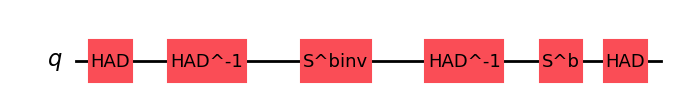

BR1-RHS:


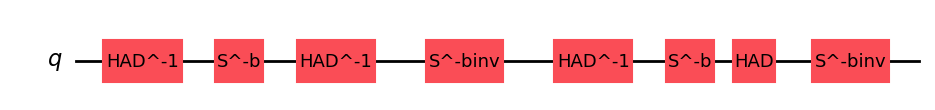

BR2-LHS:


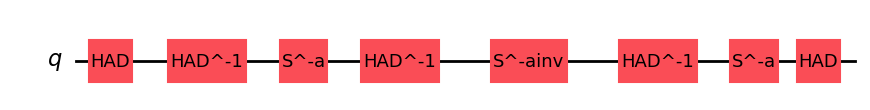

BR2-RHS:


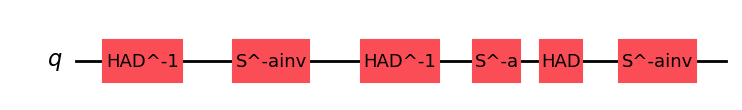

BR3-LHS:


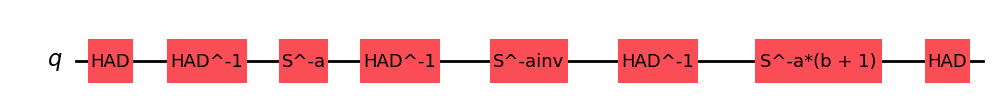

BR3-RHS:


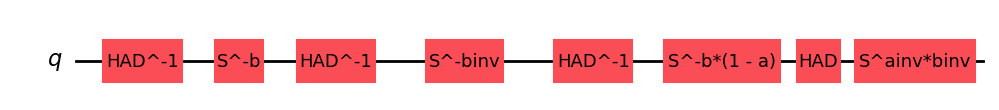

BR4-LHS:


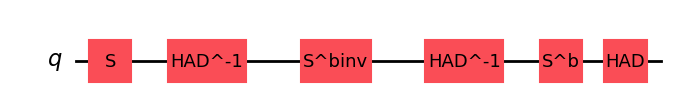

BR4-RHS:


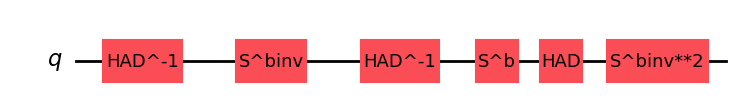

BR5-LHS:


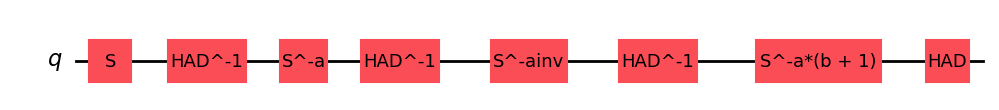

BR5-RHS:


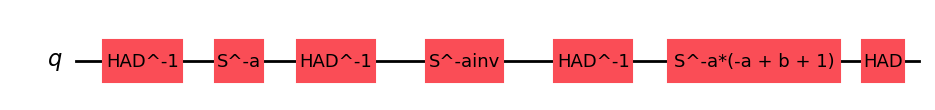

BR6-LHS:


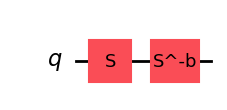

BR6-RHS:


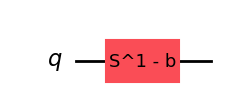

In [ ]:
from IPython.display import display

# Loop and display drawings
for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):
    print(f"{name}-LHS:")
    display(lhs.draw())

    print(f"{name}-RHS:")
    display(rhs.draw())

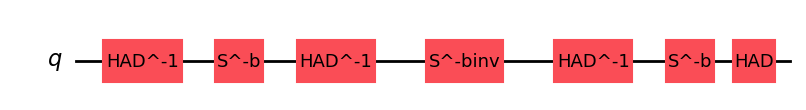

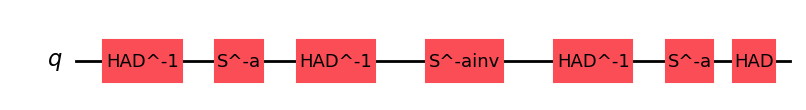

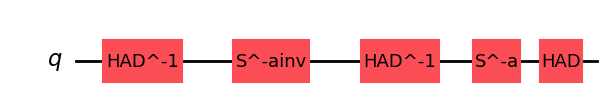

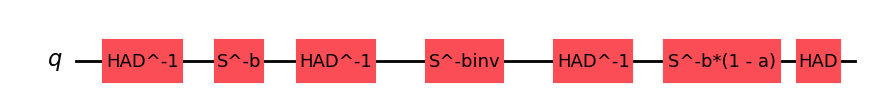

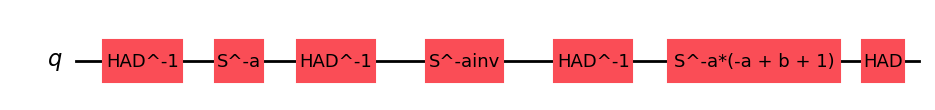

In [ ]:
a = symbols("a")
b = symbols("b")
# ainv = symbols("ainv")

# binv = symbols("binv")

A0b_0 = instantiate_A_box(0, b, 0, 1, 23)
Aab_0 = instantiate_A_box(a, b, 0, 1, 23)
Ab0_0 = instantiate_A_box(b, 0, 0, 1, 23)
Aa0_0 = instantiate_A_box(a, 0, 0, 1, 23)
A0_neg_a = instantiate_A_box(0, -a, 0, 1, 23)
Ab_neg_a = instantiate_A_box(b, -a, 0, 1, 23)
Aa_bminusa = instantiate_A_box(a, b-a, 0, 1, 23)

A0b_0_reduce = dizx.symplectic.reduce_matrix(A0b_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0b_0_reduce
Aab_0_reduce = dizx.symplectic.reduce_matrix(Aab_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aab_0_reduce
Ab0_0_reduce = dizx.symplectic.reduce_matrix(Ab0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab0_0_reduce
display(Ab0_0.draw())
Aa0_0_reduce = dizx.symplectic.reduce_matrix(Aa0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa0_0_reduce
display(Aa0_0.draw())
A0_neg_a_reduce = dizx.symplectic.reduce_matrix(A0_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0_neg_a_reduce
display(A0_neg_a.draw())
Ab_neg_a_reduce = dizx.symplectic.reduce_matrix(Ab_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab_neg_a_reduce
display(Ab_neg_a.draw())
Aa_bminusa_reduce = dizx.symplectic.reduce_matrix(Aa_bminusa.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa_bminusa_reduce
display(Aa_bminusa.draw())
# Aab_m = Aab.to_symplectic_matrix()
# Aab_m_reduce = dizx.symplectic.reduce_matrix(Aab_m,[(a,ainv),(b,binv)])


In [ ]:
# Define A and E boxes that appear in the single-qupit box relations
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")

A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H

Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

Ab0 = dizx.Circuit(qudit_amount=1, dim=p)
Ab0 += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b) + H

Aa0 = dizx.Circuit(qudit_amount=1, dim=p)
Aa0 += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a) + H

A0_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
A0_neg_a += H**-1 + S**-ainv + H**-1 + S**-a + H

Ab_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
Ab_neg_a += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b*(-a+1)) + H

Aa_bminusa = dizx.Circuit(qudit_amount=1, dim=p)
Aa_bminusa += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b-a+1)) + H

Eb = dizx.Circuit(qudit_amount=1, dim=p)
Eb += S**(-b)

E_bminus1 = dizx.Circuit(qudit_amount=1, dim=p)
E_bminus1 += S**-(b-1)

# Verify the action of B boxes on the Pauli generators
- $B_{00}$, 
- $B_{01}$, 
- $B_{ab}$, $(a,b) \in \mathbb{Z}_p\times \mathbb{Z}_p\setminus\{(0,0),(0,1)\}$.

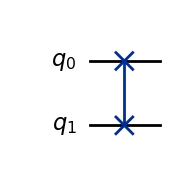

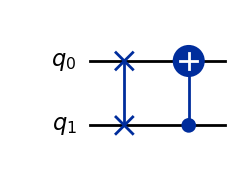

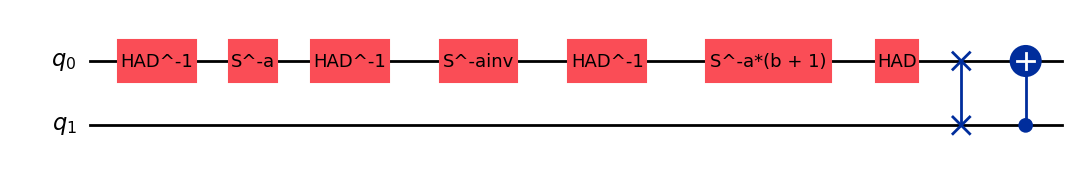

In [ ]:
from dizx.circuit.gates import SWAP, CZ, CX, HAD, S
def makeBbox(qudit_amount, dim, targets):
    
B00 = dizx.Circuit(qudit_amount=2, dim=23)
B00 += SWAP(0,1)
display(B00.draw())

B01 = dizx.Circuit(qudit_amount=2, dim=23)
B01 += SWAP(0,1)
B01 += CX(1,0)
display(B01.draw())

Bab = dizx.Circuit(qudit_amount=2, dim=23)
Bab += Aab + B01
display(Bab.draw())

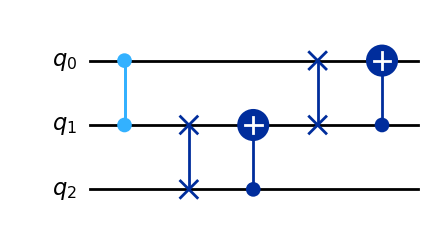

In [ ]:
B01_12 = dizx.Circuit(qudit_amount=3, dim=3)
B01_12 += SWAP(1,2)
B01_12 += CX(2,1)

B01_01 = dizx.Circuit(qudit_amount=3, dim=3)
B01_01 += SWAP(0,1)
B01_01 += CX(1,0)

lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CZ(0,1) + B01_12 + B01_01
display(lhs.draw())

## Print the symplectic matrix of two-qupit gates and verify that their definition is consistent with the paper

In [ ]:
SWAPmat
CXmat(1)
CX(1,0,2,p)
# modulo_matrix(CXmat(23), 23)
# SWAP(0,2,4)
# CX(0,2,4,1)
# CX(2,0,4,1)
CZ(0,1,3,23)
modulo_matrix(CZ(0,1,3,23), 23)
CZ(0,2,3,23)
modulo_matrix(CZ(0,2,3,23), 23)
CZ(1,0,3,23)
CZ(2,0,3,23)

Matrix([
[ 1, 0, 0, 0,  0, 0],
[ 0, 1, 0, 0, 23, 0],
[ 0, 0, 1, 0,  0, 0],
[ 0, 0, 0, 1,  0, 0],
[ 0, 0, 0, 0,  1, 0],
[23, 0, 0, 0,  0, 1]])

In [ ]:
from dizx.circuit.gates import SWAP, CZ, CX, HAD, S
lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CX(0,2) ** 3
lhs.to_symplectic_matrix()
dizx.symplectic.modulo_matrix(lhs.to_symplectic_matrix(),3)
# display(lhs.draw())

rhs = dizx.Circuit(qudit_amount=2, dim=3)
rhs += SWAP(0,1)
rhs.to_symplectic_matrix()
# dizx.symplectic.modulo_matrix(rhs.to_symplectic_matrix(),3)
# display(rhs.draw())

Matrix([
[0, 0, 1, 0],
[0, 0, 0, 1],
[1, 0, 0, 0],
[0, 1, 0, 0]])

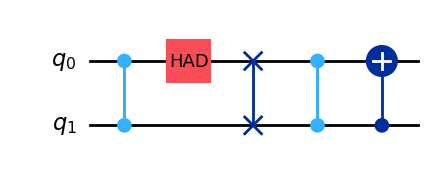

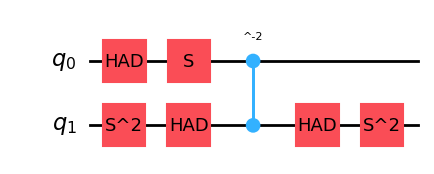

In [ ]:


lhs = dizx.Circuit(qudit_amount=2, dim=3)
lhs += CZ(0,1)
lhs += HAD(0)
lhs += SWAP(0,1)
lhs += CZ(0,1)
lhs += CX(1,0)
rhs = dizx.Circuit(qudit_amount=2, dim=3)
rhs += S(1)**2 + HAD(0)
rhs += S(0) + HAD(1)
rhs += CZ(0,1,2)**2
rhs += HAD(1) + S(1)**2

display(lhs.draw())
display(rhs.draw())

## Print each single-qupit box relation to two qasm files

In [ ]:
name_of_file = 'BR1-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR1_lhs:
    fBR1_lhs.write(BR1lhs.to_qasm())
name_of_file = 'BR1-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR1_rhs:
    fBR1_rhs.write(BR1rhs.to_qasm())

name_of_file = 'BR2-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR2_lhs:
    fBR2_lhs.write(BR2lhs.to_qasm())
name_of_file = 'BR2-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR2_rhs:
    fBR2_rhs.write(BR2rhs.to_qasm())

name_of_file = 'BR3-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR3_lhs:
    fBR3_lhs.write(BR3lhs.to_qasm())
name_of_file = 'BR3-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR3_rhs:
    fBR3_rhs.write(BR3rhs.to_qasm())

name_of_file = 'BR4-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR4_lhs:
    fBR4_lhs.write(BR4lhs.to_qasm())
name_of_file = 'BR4-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR4_rhs:
    fBR4_rhs.write(BR4rhs.to_qasm())

name_of_file = 'BR5-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR5_lhs:
    fBR5_lhs.write(BR5lhs.to_qasm())
name_of_file = 'BR5-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR5_rhs:
    fBR5_rhs.write(BR5rhs.to_qasm())

name_of_file = 'BR6-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR6_lhs:
    fBR6_lhs.write(BR6lhs.to_qasm())
name_of_file = 'BR6-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR6_rhs:
    fBR6_rhs.write(BR6rhs.to_qasm())

In [ ]:
# print("BR1-LHS:")
# display(BR1lhs.draw())
# print("BR1-RHS:")
# display(BR1rhs.draw())

# print("BR2-LHS:")
# display(BR2lhs.draw())
# print("BR2-RHS:")
# display(BR2rhs.draw())

# print("BR3-LHS:")
# display(BR3lhs.draw())
# print("BR3-RHS:")
# display(BR3rhs.draw())

# print("BR4-LHS:")
# display(BR4lhs.draw())
# print("BR4-RHS:")
# display(BR4rhs.draw())

# print("BR5-LHS:")
# display(BR5lhs.draw())
# print("BR5-RHS:")
# display(BR5rhs.draw())

# print("BR6-LHS:")
# display(BR6lhs.draw())
# print("BR6-RHS:")
# display(BR6rhs.draw())

In [ ]:
primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    if dizx.symplectic.compare_matrices2(BR1lhs.to_symplectic_matrix(), BR1rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 1 fails.")
    if dizx.symplectic.compare_matrices2(BR2lhs.to_symplectic_matrix(), BR2rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 2 fails.")
    if dizx.symplectic.compare_matrices2(BR3lhs.to_symplectic_matrix(), BR3rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 3 fails.")
    if dizx.symplectic.compare_matrices2(BR4lhs.to_symplectic_matrix(), BR4rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 4 fails.")
    if dizx.symplectic.compare_matrices2(BR5lhs.to_symplectic_matrix(), BR5rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 5 fails.")
    if dizx.symplectic.compare_matrices2(BR6lhs.to_symplectic_matrix(), BR6rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 6 fails.")

3
5
7
11
13
19
23
23


In [ ]:
import os



# --- 2. Loop through all relations ---
for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

    # Compute symplectic matrices
    lhs_mat = lhs.to_symplectic_matrix()
    rhs_mat = rhs.to_symplectic_matrix()

    # Compare using your function
    ok = dizx.symplectic.compare_matrices2(lhs_mat, rhs_mat, modulus=p)

    if not ok:
        print(f"{name} fails.")

        # --- 3. Save LHS and RHS QASM files ---
        lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
        rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

        with open(lhs_filename, "w+") as f:
            f.write(lhs.to_qasm())

        with open(rhs_filename, "w+") as f:
            f.write(rhs.to_qasm())

        # Optional: stop after the first failure
        # break

    else:
        print(f"{name} OK.")

BR1 OK.
BR2 OK.
BR3 OK.
BR4 OK.
BR5 OK.
BR6 OK.


In [ ]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H
A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H
m = A0b.to_symplectic_matrix()
print(m)
print(dizx.symplectic.reduce_matrix(m,[(a,ainv),(b,binv)]))
BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1lhs += S + A0b
BR1rhs += A0b + (S**binv)**binv
mlhs = BR1lhs.to_symplectic_matrix()
print("S.A0b")
print(mlhs)
print(dizx.symplectic.reduce_matrix(mlhs,[(a,ainv),(b,binv)]))
BR1rhs += A0b + (S**binv)**binv
mrhs = BR1rhs.to_symplectic_matrix()
print("A0b.dir")
print(mrhs)
print(dizx.symplectic.reduce_matrix(mrhs,[(a,ainv),(b,binv)]))
# primes = [3, 5, 7, 11, 13, 19, 23]
# for p in primes:
#     BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
#     BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
#     BR1lhs += S + A0b
#     BR1rhs += A0b + (S**binv)**binv
#     print(dizx.symplectic.compare_matrices(BR1lhs.to_symplectic_matrix(), BR1rhs.to_symplectic_matrix(), modulus=p))

Matrix([[b, -b*binv + 1], [-1, binv]])
Matrix([[b, 0], [-1, binv]])
S.A0b
Matrix([[-b*(binv - 1) + 1, -b*binv + 1], [binv - 1, binv]])
Matrix([[b, 0], [binv - 1, binv]])
A0b.dir
Matrix([[b*binv**2 - b*(-b + binv*(b*binv**2 - 1)) - 1, -b*(b*binv + binv*(binv**2*(-b*binv + 1) + binv) - 1) + binv**2*(-b*binv + 1) + binv], [-b + binv**2*(b*binv**2 - b*(-b + binv*(b*binv**2 - 1)) - 1) + binv*(b*binv**2 - 1), b*binv + binv**2*(-b*(b*binv + binv*(binv**2*(-b*binv + 1) + binv) - 1) + binv**2*(-b*binv + 1) + binv) + binv*(binv**2*(-b*binv + 1) + binv) - 1]])
Matrix([[b**2, 0], [-b + binv**2 - binv + 1, binv**2]])


In [ ]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Hadj = dizx.gates.HAD(0,adjoint=True)
H = dizx.gates.HAD(0)
S = dizx.gates.S(0)

lhs = dizx.Circuit(qudit_amount=1, dim=3)
lhs += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

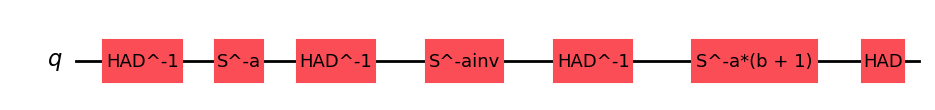

In [ ]:
lhs.draw()

Matrix([[1, 0], [a, 1]])


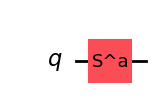

In [ ]:
# C1
lhs = dizx.Circuit(qudit_amount=1, dim=5)
# S1 = S(1, 2, a)
# lhs += S1
# S0 = S(0,1)
lhs += S ** a
print(lhs.to_symplectic_matrix())
display(lhs.draw())

In [ ]:
c = dizx.Circuit(qudit_amount=2,dim=3)
c.add_gates("H H S",0)
# c.add_gate("CZ",0,1)
# c.add_gates("S S H",1)
# c.add_gates("H S", 0)

In [ ]:
print(c)

Circuit[3](2 qudits, 0 dits, [HAD(0), HAD(0), S(0)] gates)


In [ ]:
# Experimenting with sympy's finite fields over polynomials
# Attempt 1 using Polynomial rings

from sympy import symbols, groebner, Matrix
from sympy.polys.domains import GF, PolynomialRing
from sympy.polys.matrices import DomainMatrix

p = 7
F = GF(p)
beta = symbols("beta")
b = symbols("b")
a = symbols("a")
ainv = symbols("a^{-1}")

# Polynomial ring GF(p)[a]
R = PolynomialRing(F, [a,ainv,b])

# testing
# R = PolynomialRing(F, [a,ainv,b,beta])

Ra = R.convert(a)
Rainv = R.convert(ainv)
# Rbeta = R.convert(beta)
Rb = R.convert(b)

G = groebner([a*ainv - 1], a, ainv, modulus=p)

H = DomainMatrix([[R.convert(0), R.convert(-1)],
                  [R.convert(1), R.convert(0)]],
                 (2, 2), R)

Hinv = DomainMatrix([[R.convert(0), R.convert(1)],
                  [R.convert(-1), R.convert(0)]],
                 (2, 2), R)


def S_repetitions(rep):
    return DomainMatrix([[R.convert(1), R.convert(0)],
                  [rep, R.convert(1)]],
                 (2, 2), R)

# Sbeta = S_repetitions(Rbeta)
Sb = S_repetitions(Rb)
# Build a matrix with entries in GF(p)[a]
A = DomainMatrix([[R.convert(1), R.convert(0)],
                  [R.convert(b), R.convert(1)]],
                 (2, 2), R)

print("Matrix over GF(p)[a]:")
print(A.to_Matrix())

aval = F(3)  # element of GF(7)

# Substitute 'a=3' in each entry
# evaluated_entries = [[entry.evaluate(0,aval) for entry in row]
#                      for row in A.to_list()]

# # Build a new matrix over GF(p)
# A_eval = DomainMatrix(evaluated_entries, A.shape, F)

# print("Matrix evaluated at a=3 (in GF(7)):")
# print(A_eval.to_Matrix())

Matrix over GF(p)[a]:
Matrix([[1, 0], [b, 1]])


In [ ]:
# Attempt 2 using groebner bases to automate the reductions of the variables and say a*ainv = 1.
G = groebner([a*ainv - 1], a, ainv, b, modulus=p)
expr = a**2*ainv + 3
G.reduce(expr)

H = Matrix([[0,-1],[1,0]])
Hinv = Matrix([[0,1],[-1,0]])
H2 = Matrix([[-1,0],[0,-1]])


def Sr(rep):
    return Matrix([[1,0],[rep,1]])

M = H*Sr(-a*(b+1))*Hinv*Sr(-ainv)*Hinv*Sr(-a)*Hinv

def reduce_matrix(M):
    evaluated_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = G.reduce(entry)[1]
            newrow.append(entry)
        evaluated_entries.append(newrow)
    return Matrix(evaluated_entries)

reduce_matrix(M)

Matrix([
[   b, -a],
[ainv,  0]])

# The Qupit Equality Checking

In [ ]:
from sympy import Matrix, symbols, expand
from sympy.polys import groebner

# symbols and field
a, ainv, b = symbols('a ainv b')
# p = 101  # your modulus

# ideal: a*ainv = 1 over GF(p)
G = groebner([a*ainv - 1], a, ainv, b, order='lex', modulus=p)

def nf(expr):
    # reduced (normal-form) representative modulo <a*ainv-1> over GF(p)
    return G.reduce(expand(expr))[1]

def normalize_matrix(M):
    # apply reduction entrywise
    return M.applyfunc(nf)

def matrices_equal(A, B):
    # equal iff their difference reduces to 0
    R = normalize_matrix(A - B)
    return R == Matrix.zeros(*A.shape)

# example usage:
# M = ... (your matrix)
# N = ... (another matrix built the same way)
# are_equal = matrices_equal(M, N)
# print(are_equal)


# The Qutrit Equality Checking

In [ ]:
def equalUpToScalar(U, V, tol=1e-10):
    """
    Check if two unitary matrices U and V are equal up to (-w)^t, 
    where w is the third root of unity and t is in Z6.

    Parameters:
    U : np.ndarray
        The first symplectic matrix
    V : np.ndarray
        The second symplectic matrix
    tol : float
        The numerical tolerance for equality checks (default: 1e-10).

    Returns:
    bool : True if U and V are equal up to a scalar, False otherwise.
    """
    # Compute the third root of unity w
    # w = np.exp(2j * np.pi / 3)

    # Define the all-zero matrix based on the dimension and data type of the input matrix
    # zero_matrix = np.zeros_like(U)
    zero_matrix = Matrix([[0,0],[0,0]])
    
    # When V = U
    if np.allclose(V - U, zero_matrix, rtol=0, atol=tol):
        print("Exactly equal")
        return True
    else:
        print("Not equal")
        return False
    

In [ ]:
from sympy import Matrix

M = Matrix([[1,0],[a,1]])
M.inv()

Matrix([
[ 1, 0],
[-a, 1]])

# Confirm the Single-Qupit Symplectic Completeness

In [ ]:
# Test 1
H2 = H * H
print(H2)

H3 = H * H * H
print(H3)

H4 = H * H * H * H
print(H4)

DomainMatrix([[6 mod 7, 0 mod 7], [0 mod 7, 6 mod 7]], (2, 2), GF(7)[a,a^{-1},b])
DomainMatrix([[0 mod 7, 1 mod 7], [6 mod 7, 0 mod 7]], (2, 2), GF(7)[a,a^{-1},b])
DomainMatrix([[1 mod 7, 0 mod 7], [0 mod 7, 1 mod 7]], (2, 2), GF(7)[a,a^{-1},b])


In [ ]:
# Test 2
S = Sr(1)
print("S: ", S)

S2 = Sr(2)
reduce_S2 = reduce_matrix(S2)
print("S2: ", reduce_S2)

S3 = Sr(3)
reduce_S3 = reduce_matrix(S3)
print("S3: ", reduce_S3)

S4 = Sr(4)
reduce_S4 = reduce_matrix(S4)
print("S4: ", reduce_S4)

S5 = Sr(5)
reduce_S5 = reduce_matrix(S5)
print("S5: ", reduce_S5)

S6 = Sr(6)
reduce_S6 = reduce_matrix(S6)
print("S6: ", reduce_S6)

Sp = Sr(p)
reduce_Sp = reduce_matrix(Sp)
print("Sp: ", reduce_Sp)

Sp1 = Sr(p+1)
reduce_Sp1 = reduce_matrix(Sp1)
print("Sp+1: ", reduce_Sp1)

print(p)

S:  Matrix([[1, 0], [1, 1]])
S2:  Matrix([[1, 0], [2, 1]])
S3:  Matrix([[1, 0], [3, 1]])
S4:  Matrix([[1, 0], [-3, 1]])
S5:  Matrix([[1, 0], [-2, 1]])
S6:  Matrix([[1, 0], [-1, 1]])
Sp:  Matrix([[1, 0], [0, 1]])
Sp+1:  Matrix([[1, 0], [1, 1]])
7


In [ ]:
# Test 3: Figure 1, single qupit
LHS = H * S * H * S * H * S
RHS = Matrix([[1,0],[0,1]])
print(LHS)
print(RHS)
print(matrices_equal(LHS, RHS))


LHS = H2 * S
RHS = S * H2
print(LHS)
print(RHS)
print(matrices_equal(LHS, RHS))

TypeError: cannot unpack non-iterable int object

In [ ]:
# Test 4
input = Matrix([[a],[0]])
print(H * input)

input = Matrix([[0],[a]])
print(H * input)

input = Matrix([[0],[-a]])
print(H * input)

Matrix([[0], [a]])
Matrix([[-a], [0]])
Matrix([[a], [0]])


In [ ]:
# Test 5
input = Matrix([[a],[0]])
print(S * input)

input = Matrix([[0],[a]])
print(S * input)

input = Matrix([[a],[-a]])
print(S * input)

Matrix([[a], [a]])
Matrix([[0], [a]])
Matrix([[a], [0]])


In [ ]:
# Test 6
Sa = Sr(a)

input = Matrix([[1],[0]])
print(Sa * input)

input = Matrix([[0],[1]])
print(Sa * input)

input = Matrix([[1],[-a]])
print(Sa * input)

Matrix([[1], [a]])
Matrix([[0], [1]])
Matrix([[1], [0]])


In [ ]:
# Test 7
Sb = Sr(b)

input = Matrix([[a],[0]])
print(Sb * input)

input = Matrix([[0],[a]])
print(Sb * input)

input = Matrix([[a],[-a * b]])
print(Sb * input)

Matrix([[a], [a*b]])
Matrix([[0], [a]])
Matrix([[a], [0]])


# Test multi-qudit gates

In [ ]:
# SWAP
SWAPmat
SWAP(0,2,4)

Matrix([
[0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 1]])

In [ ]:
# Hadamard
# H0 = H(0, 2, reps=1)
# print(H0)
H(1, 3, reps=1)
# H(1, 3, reps=2)
# H(1, 3, reps=3)
# H(1, 3, reps=5)
# H1 = H(1, 2, reps=1)

Matrix([
[1, 0, 0,  0, 0, 0],
[0, 1, 0,  0, 0, 0],
[0, 0, 0, -1, 0, 0],
[0, 0, 1,  0, 0, 0],
[0, 0, 0,  0, 1, 0],
[0, 0, 0,  0, 0, 1]])

Matrix([[1, 0], [a, 1]])


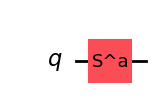

In [ ]:
# def S(target, num_qudits, reps=1):
#     mat = Smat(reps)
#     return embed_block(mat, num_qudits, [target])
lhs = dizx.Circuit(qudit_amount=1, dim=5)
# S1 = S(1, 2, a)
# lhs += S1
S0 = S(0)
lhs += S0 ** a
print(lhs.to_symplectic_matrix())
display(lhs.draw())

In [ ]:
H0 = H(0, 2, reps=1)
H1 = H(1, 2, reps=1)
S1 = S(0, 2, reps=2)
# C14l = CZ * H0 * CZ * H0 * CZ * S1
# C14r = H0 * CZ * H0
print(H0 == H1)

False


In [ ]:
from dizx.circuit.gates import CZ, CX, HAD, S#, Z, X

lhs = dizx.Circuit(qudit_amount=2, dim=5)
lhs += CZ(0,1)
lhs += HAD(0)**2 + HAD(1)
lhs += CZ(0,1)
lhs += CX(1,0)
rhs = dizx.Circuit(qudit_amount=2, dim=5)
rhs += HAD(1)
rhs += CZ(0,1) + CX(1,0)
rhs += S(1)**2 + HAD(1)**2 + S(1)**2
rhs += CX(0,1)**2
rhs += S(1)**2 #+ Z(1)

In [ ]:
dizx.symplectic.compare_matrices(lhs.to_symplectic_matrix(), rhs.to_symplectic_matrix(), modulus=3)

True

LHS of BR1


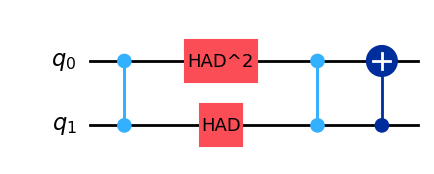

LHS of BR1


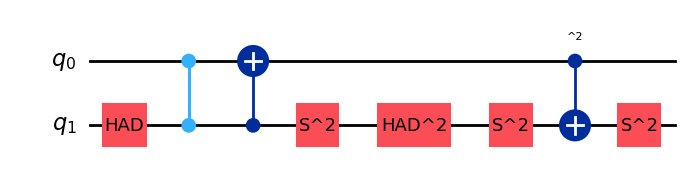

In [ ]:
print("LHS of BR1")
display(lhs.draw())
print("LHS of BR1")
display(rhs.draw())

In [ ]:
r1-lhs = CZ * H0 * CZ * H0 * CZ * S1r(2)

primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    r1-lhs 

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import dizx
from dizx import Edge
from dizx import clifford_simplifier as simp
Phase = dizx.CliffordPhase
d = 3
Z = dizx.VertexType.Z
X = dizx.VertexType.X

In [ ]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Hadj = dizx.gates.HAD(0,adjoint=True)
H = dizx.gates.HAD(0)
S = dizx.gates.S(0)

lhs = dizx.Circuit(qudit_amount=1, dim=3)
lhs += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

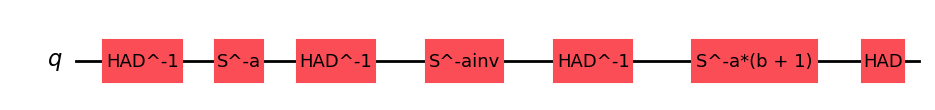

In [ ]:
lhs.draw()